In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
import os

PROJECT_PATH = "/content/drive/MyDrive/final_year_project"

print(os.listdir(PROJECT_PATH))

['Wheat_Master']


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/final_year_project/Wheat_Master"

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

print("DATASET AUDIT")
print("=" * 50)

total_images = 0

for class_name in sorted(os.listdir(DATASET_PATH)):
    class_path = os.path.join(DATASET_PATH, class_name)

    if os.path.isdir(class_path):
        images = [
            file for file in os.listdir(class_path)
            if file.lower().endswith(image_extensions)
        ]

        print(f"{class_name:<25} : {len(images)} images")
        total_images += len(images)

print("=" * 50)
print("Total images:", total_images)

DATASET AUDIT
BlackPoint                : 187 images
Brown_Rust                : 321 images
HealthyLeaf               : 316 images
Mildew                    : 265 images
Septoria                  : 342 images
YellowRust                : 302 images
Total images: 1733


In [ ]:
from PIL import Image
import os

DATASET_PATH = "/content/drive/MyDrive/final_year_project/Wheat_Master"

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

corrupted_images = []
checked = 0

print("Checking image integrity...")
print("=" * 60)

for class_name in sorted(os.listdir(DATASET_PATH)):

    class_path = os.path.join(DATASET_PATH, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):

        if not file_name.lower().endswith(image_extensions):
            continue

        image_path = os.path.join(class_path, file_name)

        try:
            with Image.open(image_path) as img:
                img.verify()

            checked += 1

        except Exception as e:
            corrupted_images.append({
                "class": class_name,
                "file": file_name,
                "error": str(e)
            })


print("\nCHECK COMPLETE")
print("=" * 60)
print("Images checked :", checked + len(corrupted_images))
print("Valid images   :", checked)
print("Corrupted      :", len(corrupted_images))

if corrupted_images:
    print("\nCORRUPTED IMAGES:")
    for item in corrupted_images:
        print(
            f"{item['class']} / {item['file']} "
            f"--> {item['error']}"
        )
else:
    print("\n✓ No corrupted images found.")

Checking image integrity...

CHECK COMPLETE
Images checked : 1733
Valid images   : 1733
Corrupted      : 0

✓ No corrupted images found.


In [ ]:
import os
import hashlib
from collections import defaultdict

DATASET_PATH = "/content/drive/MyDrive/final_year_project/Wheat_Master"

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

hash_groups = defaultdict(list)

print("Checking exact duplicates...")
print("=" * 60)

for class_name in sorted(os.listdir(DATASET_PATH)):

    class_path = os.path.join(DATASET_PATH, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):

        if not file_name.lower().endswith(image_extensions):
            continue

        image_path = os.path.join(class_path, file_name)

        # Calculate SHA-256 hash
        sha256 = hashlib.sha256()

        with open(image_path, "rb") as f:
            while True:
                chunk = f.read(1024 * 1024)

                if not chunk:
                    break

                sha256.update(chunk)

        file_hash = sha256.hexdigest()

        hash_groups[file_hash].append({
            "class": class_name,
            "file": file_name,
            "path": image_path
        })


# Keep only hashes belonging to multiple files
duplicate_groups = {
    file_hash: files
    for file_hash, files in hash_groups.items()
    if len(files) > 1
}


duplicate_extra_files = sum(
    len(files) - 1
    for files in duplicate_groups.values()
)


print("\nEXACT DUPLICATE REPORT")
print("=" * 60)

print("Unique image contents :", len(hash_groups))
print("Duplicate groups      :", len(duplicate_groups))
print("Extra duplicate files :", duplicate_extra_files)


if duplicate_groups:

    print("\nDUPLICATE GROUPS:")

    for group_number, files in enumerate(
        duplicate_groups.values(),
        start=1
    ):

        print(f"\nGroup {group_number}")

        for item in files:
            print(
                f"  {item['class']} / {item['file']}"
            )

else:
    print("\n✓ No exact duplicates found.")

Checking exact duplicates...

EXACT DUPLICATE REPORT
Unique image contents : 1707
Duplicate groups      : 26
Extra duplicate files : 26

DUPLICATE GROUPS:

Group 1
  Brown_Rust / brown_rust_1234.png
  Brown_Rust / brown_rust_22.png

Group 2
  Brown_Rust / brown_rust_30.png
  Brown_Rust / BrownRust1018.png

Group 3
  Brown_Rust / brown_rust_31.png
  Brown_Rust / BrownRust1055.png

Group 4
  Brown_Rust / brown_rust_34.png
  Brown_Rust / BrownRust1119.png

Group 5
  Brown_Rust / brown_rust_33.png
  Brown_Rust / BrownRust1080.png

Group 6
  Mildew / mildew_203.png
  Mildew / Mildew1022.png

Group 7
  Mildew / mildew_210.png
  Mildew / Mildew1111.png

Group 8
  Mildew / mildew_217.png
  Mildew / Mildew1133.png

Group 9
  Mildew / mildew_223.png
  Mildew / Mildew1158.png

Group 10
  Mildew / mildew_225.png
  Mildew / Mildew1201.png

Group 11
  Mildew / mildew_218.png
  Mildew / Mildew1135.png

Group 12
  Mildew / mildew_215.png
  Mildew / Mildew1122.png

Group 13
  Mildew / mildew_219.png
  

In [ ]:
import os
import shutil

BACKUP_PATH = "/content/drive/MyDrive/final_year_project/Exact_Duplicates_Backup"

os.makedirs(BACKUP_PATH, exist_ok=True)

moved = 0

for group_number, files in enumerate(duplicate_groups.values(), start=1):

    # Keep the first file
    keep = files[0]

    # Move every additional exact copy
    for duplicate in files[1:]:

        source = duplicate["path"]

        class_backup = os.path.join(
            BACKUP_PATH,
            duplicate["class"]
        )

        os.makedirs(class_backup, exist_ok=True)

        destination = os.path.join(
            class_backup,
            duplicate["file"]
        )

        # Safety check
        if os.path.exists(destination):
            base, ext = os.path.splitext(duplicate["file"])
            destination = os.path.join(
                class_backup,
                f"{base}_duplicate_{group_number}{ext}"
            )

        shutil.move(source, destination)

        moved += 1

        print(
            f"Moved: {duplicate['class']} / "
            f"{duplicate['file']}"
        )


print("\n" + "=" * 60)
print("Exact duplicate cleanup complete")
print("Duplicates moved :", moved)
print("Expected images remaining :", 1733 - moved)
print("Backup location :", BACKUP_PATH)

Moved: Brown_Rust / brown_rust_22.png
Moved: Brown_Rust / BrownRust1018.png
Moved: Brown_Rust / BrownRust1055.png
Moved: Brown_Rust / BrownRust1119.png
Moved: Brown_Rust / BrownRust1080.png
Moved: Mildew / Mildew1022.png
Moved: Mildew / Mildew1111.png
Moved: Mildew / Mildew1133.png
Moved: Mildew / Mildew1158.png
Moved: Mildew / Mildew1201.png
Moved: Mildew / Mildew1135.png
Moved: Mildew / Mildew1122.png
Moved: Mildew / Mildew1139.png
Moved: Mildew / Mildew1148.png
Moved: Mildew / Mildew1210.png
Moved: Mildew / Mildew1082.png
Moved: Mildew / Mildew1099.png
Moved: Mildew / Mildew1116.png
Moved: Mildew / Mildew1051.png
Moved: Mildew / Mildew1066.png
Moved: Mildew / Mildew1041.png
Moved: Mildew / Mildew1249.png
Moved: Mildew / Mildew984.png
Moved: Mildew / Mildew778.png
Moved: Mildew / Mildew988.png
Moved: Mildew / Mildew733.png

Exact duplicate cleanup complete
Duplicates moved : 26
Expected images remaining : 1707
Backup location : /content/drive/MyDrive/final_year_project/Exact_Duplicat

In [ ]:
!pip -q install imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 9.1 MB/s eta 0:00:00


In [ ]:
from PIL import Image
import imagehash
import os
from collections import defaultdict

DATASET_PATH = "/content/drive/MyDrive/final_year_project/Wheat_Master"

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

print("Libraries ready.")

Libraries ready.


In [ ]:
image_records = []

print("Calculating perceptual hashes...")
print("=" * 60)

for class_name in sorted(os.listdir(DATASET_PATH)):

    class_path = os.path.join(DATASET_PATH, class_name)

    if not os.path.isdir(class_path):
        continue

    for file_name in os.listdir(class_path):

        if not file_name.lower().endswith(image_extensions):
            continue

        image_path = os.path.join(class_path, file_name)

        try:
            with Image.open(image_path) as img:
                img = img.convert("RGB")

                phash = imagehash.phash(img, hash_size=16)

                image_records.append({
                    "class": class_name,
                    "file": file_name,
                    "path": image_path,
                    "phash": phash
                })

        except Exception as e:
            print("Error:", image_path, e)


print("\nPerceptual hashes calculated:", len(image_records))

Calculating perceptual hashes...

Perceptual hashes calculated: 1707


In [ ]:
similar_pairs = []

PHASH_THRESHOLD = 28

print("Searching for visually similar images...")
print("=" * 60)

classes = sorted(set(item["class"] for item in image_records))

for class_name in classes:

    class_images = [
        item for item in image_records
        if item["class"] == class_name
    ]

    print(f"Checking {class_name}: {len(class_images)} images")

    for i in range(len(class_images)):
        for j in range(i + 1, len(class_images)):

            distance = (
                class_images[i]["phash"]
                - class_images[j]["phash"]
            )

            if distance <= PHASH_THRESHOLD:
                similar_pairs.append({
                    "class": class_name,
                    "image1": class_images[i],
                    "image2": class_images[j],
                    "distance": distance
                })


# Most visually similar first
similar_pairs.sort(key=lambda x: x["distance"])

print("\n" + "=" * 60)
print("Candidate similar pairs:", len(similar_pairs))

print("\nFirst 30 strongest candidates:\n")

for pair in similar_pairs[:30]:
    print(
        f"{pair['class']:<15} | "
        f"distance={pair['distance']:<3} | "
        f"{pair['image1']['file']}  <->  "
        f"{pair['image2']['file']}"
    )

Searching for visually similar images...
Checking BlackPoint: 187 images
Checking Brown_Rust: 316 images
Checking HealthyLeaf: 316 images
Checking Mildew: 244 images
Checking Septoria: 342 images
Checking YellowRust: 302 images

Candidate similar pairs: 142

First 30 strongest candidates:

Brown_Rust      | distance=0   | brown_rust_test_15.png  <->  BrownRust1599.png
Brown_Rust      | distance=0   | brown_rust_test_33.png  <->  BrownRust777.png
Brown_Rust      | distance=0   | brown_rust_test_19.png  <->  BrownRust1663.png
Brown_Rust      | distance=0   | brown_rust_test_36.png  <->  brown_rust_34.png
Mildew          | distance=0   | mildew_1017.png  <->  Mildew1717.png
Mildew          | distance=0   | mildew_1023.png  <->  Mildew1763.png
Mildew          | distance=0   | mildew_1029.png  <->  Mildew1798.png
Mildew          | distance=0   | mildew_2.png  <->  Mildew90.png
Brown_Rust      | distance=2   | brown_rust_test_21.png  <->  BrownRust1696.png
Brown_Rust      | distance=2   | br

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

# Show first 20 strongest candidates
NUM_TO_SHOW = 20

for index, pair in enumerate(similar_pairs[:NUM_TO_SHOW], start=1):

    img1 = Image.open(pair["image1"]["path"]).convert("RGB")
    img2 = Image.open(pair["image2"]["path"]).convert("RGB")

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].imshow(img1)
    axes[0].axis("off")
    axes[0].set_title(pair["image1"]["file"])

    axes[1].imshow(img2)
    axes[1].axis("off")
    axes[1].set_title(pair["image2"]["file"])

    plt.suptitle(
        f"Pair {index} | "
        f"Class: {pair['class']} | "
        f"pHash distance: {pair['distance']}"
    )

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from collections import Counter

distance_counts = Counter(pair["distance"] for pair in similar_pairs)

print("pHash DISTANCE DISTRIBUTION")
print("=" * 40)

for distance in sorted(distance_counts):
    print(
        f"Distance {distance:>2}: "
        f"{distance_counts[distance]} pairs"
    )

pHash DISTANCE DISTRIBUTION
Distance  0: 8 pairs
Distance  2: 44 pairs
Distance  4: 45 pairs
Distance  6: 32 pairs
Distance  8: 8 pairs
Distance 12: 1 pairs
Distance 16: 1 pairs
Distance 24: 3 pairs


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image

DISTANCES_TO_CHECK = [0, 2, 4, 6, 8, 12, 16, 24]
PAIRS_PER_DISTANCE = 3

for target_distance in DISTANCES_TO_CHECK:

    matches = [
        pair for pair in similar_pairs
        if pair["distance"] == target_distance
    ]

    if not matches:
        continue

    print("\n" + "=" * 70)
    print(
        f"pHash DISTANCE = {target_distance} "
        f"| Total pairs = {len(matches)}"
    )
    print("=" * 70)

    for pair in matches[:PAIRS_PER_DISTANCE]:

        img1 = Image.open(
            pair["image1"]["path"]
        ).convert("RGB")

        img2 = Image.open(
            pair["image2"]["path"]
        ).convert("RGB")

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))

        axes[0].imshow(img1)
        axes[0].axis("off")
        axes[0].set_title(pair["image1"]["file"])

        axes[1].imshow(img2)
        axes[1].axis("off")
        axes[1].set_title(pair["image2"]["file"])

        plt.suptitle(
            f"{pair['class']} | "
            f"pHash distance = {target_distance}"
        )

        plt.tight_layout()
        plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from collections import defaultdict

# Union-Find for grouping related images
parent = {}

def find(x):
    if x not in parent:
        parent[x] = x
    if parent[x] != x:
        parent[x] = find(parent[x])
    return parent[x]

def union(a, b):
    root_a = find(a)
    root_b = find(b)

    if root_a != root_b:
        parent[root_b] = root_a


# Build groups from our visually confirmed candidate set
for pair in similar_pairs:
    path1 = pair["image1"]["path"]
    path2 = pair["image2"]["path"]

    union(path1, path2)


groups = defaultdict(list)

for path in parent:
    groups[find(path)].append(path)


similar_groups = [
    files for files in groups.values()
    if len(files) > 1
]

print("=" * 60)
print("SIMILAR IMAGE GROUPS")
print("=" * 60)

print("Number of groups:", len(similar_groups))

total_grouped = sum(len(group) for group in similar_groups)

print("Images involved:", total_grouped)
print(
    "Extra similar images:",
    total_grouped - len(similar_groups)
)

for i, group in enumerate(similar_groups[:20], start=1):

    print(f"\nGroup {i} ({len(group)} images)")

    for path in group:
        print(" ", os.path.basename(path))

SIMILAR IMAGE GROUPS
Number of groups: 138
Images involved: 278
Extra similar images: 140

Group 1 (2 images)
  brown_rust_test_15.png
  BrownRust1599.png

Group 2 (2 images)
  brown_rust_test_33.png
  BrownRust777.png

Group 3 (2 images)
  brown_rust_test_19.png
  BrownRust1663.png

Group 4 (2 images)
  brown_rust_test_36.png
  brown_rust_34.png

Group 5 (2 images)
  mildew_1017.png
  Mildew1717.png

Group 6 (2 images)
  mildew_1023.png
  Mildew1763.png

Group 7 (2 images)
  mildew_1029.png
  Mildew1798.png

Group 8 (2 images)
  mildew_2.png
  Mildew90.png

Group 9 (2 images)
  brown_rust_test_21.png
  BrownRust1696.png

Group 10 (2 images)
  brown_rust_test_29.png
  BrownRust1795.png

Group 11 (2 images)
  brown_rust_test_27.png
  BrownRust174.png

Group 12 (2 images)
  brown_rust_test_14.png
  BrownRust1572.png

Group 13 (2 images)
  brown_rust_test_18.png
  BrownRust1655.png

Group 14 (2 images)
  brown_rust_test_24.png
  brown_rust_33.png

Group 15 (2 images)
  brown_rust_test_48.

In [ ]:
import os
import shutil

SIMILAR_BACKUP = (
    "/content/drive/MyDrive/final_year_project/"
    "Near_Duplicates_Backup"
)

os.makedirs(SIMILAR_BACKUP, exist_ok=True)

moved = 0

for group_number, group in enumerate(similar_groups, start=1):

    # Keep one representative
    keep_path = group[0]

    # Move remaining similar images
    for duplicate_path in group[1:]:

        class_name = os.path.basename(
            os.path.dirname(duplicate_path)
        )

        file_name = os.path.basename(duplicate_path)

        class_backup = os.path.join(
            SIMILAR_BACKUP,
            class_name
        )

        os.makedirs(class_backup, exist_ok=True)

        destination = os.path.join(
            class_backup,
            file_name
        )

        # Prevent accidental overwrite
        if os.path.exists(destination):
            base, ext = os.path.splitext(file_name)

            destination = os.path.join(
                class_backup,
                f"{base}_group_{group_number}{ext}"
            )

        shutil.move(
            duplicate_path,
            destination
        )

        moved += 1


print("=" * 60)
print("NEAR-DUPLICATE CLEANUP COMPLETE")
print("=" * 60)

print("Similarity groups :", len(similar_groups))
print("Images moved      :", moved)
print("Expected remaining:", 1707 - moved)
print("Backup location   :", SIMILAR_BACKUP)

NEAR-DUPLICATE CLEANUP COMPLETE
Similarity groups : 138
Images moved      : 140
Expected remaining: 1567
Backup location   : /content/drive/MyDrive/final_year_project/Near_Duplicates_Backup


In [ ]:
import os

DATASET_PATH = "/content/drive/MyDrive/final_year_project/Wheat_Master"

image_extensions = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp"
)

print("CLEAN DATASET AUDIT")
print("=" * 55)

class_counts = {}
total = 0

for class_name in sorted(os.listdir(DATASET_PATH)):

    class_path = os.path.join(
        DATASET_PATH,
        class_name
    )

    if not os.path.isdir(class_path):
        continue

    count = sum(
        1
        for file_name in os.listdir(class_path)
        if file_name.lower().endswith(image_extensions)
    )

    class_counts[class_name] = count
    total += count

    print(f"{class_name:<25}: {count} images")

print("=" * 55)
print(f"Total images: {total}")

if total == 1567:
    print("\n✓ Dataset count matches expected total.")
else:
    print(
        f"\n⚠ Expected 1567 images, "
        f"but found {total}."
    )

CLEAN DATASET AUDIT
BlackPoint               : 184 images
Brown_Rust               : 270 images
HealthyLeaf              : 314 images
Mildew                   : 207 images
Septoria                 : 342 images
YellowRust               : 250 images
Total images: 1567

✓ Dataset count matches expected total.


In [ ]:
print("PROPOSED 70 / 15 / 15 SPLIT")
print("=" * 65)

grand_train = 0
grand_val = 0
grand_test = 0

for class_name, total in class_counts.items():

    train_count = int(total * 0.70)
    val_count = int(total * 0.15)

    # Remaining images go to test
    test_count = total - train_count - val_count

    grand_train += train_count
    grand_val += val_count
    grand_test += test_count

    print(
        f"{class_name:<20} "
        f"Total={total:<4} | "
        f"Train={train_count:<4} | "
        f"Val={val_count:<3} | "
        f"Test={test_count:<3}"
    )

print("=" * 65)

print(
    f"{'TOTAL':<20} "
    f"Total={sum(class_counts.values()):<4} | "
    f"Train={grand_train:<4} | "
    f"Val={grand_val:<3} | "
    f"Test={grand_test:<3}"
)

print("\nPercentages:")

total_images = sum(class_counts.values())

print(f"Train : {grand_train / total_images * 100:.2f}%")
print(f"Val   : {grand_val / total_images * 100:.2f}%")
print(f"Test  : {grand_test / total_images * 100:.2f}%")


PROPOSED 70 / 15 / 15 SPLIT
BlackPoint           Total=184  | Train=128  | Val=27  | Test=29 
Brown_Rust           Total=270  | Train=189  | Val=40  | Test=41 
HealthyLeaf          Total=314  | Train=219  | Val=47  | Test=48 
Mildew               Total=207  | Train=144  | Val=31  | Test=32 
Septoria             Total=342  | Train=239  | Val=51  | Test=52 
YellowRust           Total=250  | Train=175  | Val=37  | Test=38 
TOTAL                Total=1567 | Train=1094 | Val=233 | Test=240

Percentages:
Train : 69.81%
Val   : 14.87%
Test  : 15.32%


In [ ]:
import os
import random
import shutil

SOURCE_PATH = "/content/drive/MyDrive/final_year_project/Wheat_Master"
SPLIT_PATH = "/content/drive/MyDrive/final_year_project/Wheat_Split_Clean"

SEED = 42
random.seed(SEED)

image_extensions = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp"
)

# Exact split counts we already calculated
split_counts = {
    "BlackPoint":  (128, 27, 29),
    "Brown_Rust":  (189, 40, 41),
    "HealthyLeaf": (219, 47, 48),
    "Mildew":      (144, 31, 32),
    "Septoria":    (239, 51, 52),
    "YellowRust":  (175, 37, 38)
}

# Safety: don't accidentally mix with an old split
if os.path.exists(SPLIT_PATH):
    raise RuntimeError(
        f"{SPLIT_PATH} already exists.\n"
        "Stop here so we don't overwrite an existing split."
    )

# Create folders
for split in ["train", "val", "test"]:
    for class_name in split_counts:
        os.makedirs(
            os.path.join(SPLIT_PATH, split, class_name),
            exist_ok=True
        )


# Split each class independently
for class_name, (n_train, n_val, n_test) in split_counts.items():

    class_source = os.path.join(
        SOURCE_PATH,
        class_name
    )

    files = sorted([
        file_name
        for file_name in os.listdir(class_source)
        if file_name.lower().endswith(image_extensions)
    ])

    expected = n_train + n_val + n_test

    if len(files) != expected:
        raise RuntimeError(
            f"{class_name}: expected {expected} images "
            f"but found {len(files)}."
        )

    # Deterministic shuffle
    random.shuffle(files)

    train_files = files[:n_train]

    val_files = files[
        n_train:
        n_train + n_val
    ]

    test_files = files[
        n_train + n_val:
    ]

    assignments = {
        "train": train_files,
        "val": val_files,
        "test": test_files
    }

    for split_name, split_files in assignments.items():

        destination_folder = os.path.join(
            SPLIT_PATH,
            split_name,
            class_name
        )

        for file_name in split_files:

            source = os.path.join(
                class_source,
                file_name
            )

            destination = os.path.join(
                destination_folder,
                file_name
            )

            shutil.copy2(source, destination)

    print(
        f"{class_name:<15} | "
        f"Train {len(train_files):<3} | "
        f"Val {len(val_files):<3} | "
        f"Test {len(test_files):<3}"
    )


print("\n" + "=" * 60)
print("SPLIT CREATION COMPLETE")
print("=" * 60)
print("Location:", SPLIT_PATH)
print("Random seed:", SEED)


BlackPoint      | Train 128 | Val 27  | Test 29 
Brown_Rust      | Train 189 | Val 40  | Test 41 
HealthyLeaf     | Train 219 | Val 47  | Test 48 
Mildew          | Train 144 | Val 31  | Test 32 
Septoria        | Train 239 | Val 51  | Test 52 
YellowRust      | Train 175 | Val 37  | Test 38 

SPLIT CREATION COMPLETE
Location: /content/drive/MyDrive/final_year_project/Wheat_Split_Clean
Random seed: 42


In [ ]:
import os
import hashlib
from collections import defaultdict

SPLIT_PATH = "/content/drive/MyDrive/final_year_project/Wheat_Split_Clean"

image_extensions = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp"
)

splits = ["train", "val", "test"]

hash_records = defaultdict(list)

print("Calculating SHA-256 hashes...")
print("=" * 60)

total_images = 0

for split in splits:

    split_path = os.path.join(SPLIT_PATH, split)

    split_count = 0

    for class_name in sorted(os.listdir(split_path)):

        class_path = os.path.join(
            split_path,
            class_name
        )

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):

            if not file_name.lower().endswith(image_extensions):
                continue

            image_path = os.path.join(
                class_path,
                file_name
            )

            # SHA-256
            with open(image_path, "rb") as f:
                file_hash = hashlib.sha256(
                    f.read()
                ).hexdigest()

            hash_records[file_hash].append({
                "split": split,
                "class": class_name,
                "file": file_name,
                "path": image_path
            })

            split_count += 1
            total_images += 1

    print(f"{split:<10}: {split_count} images")


# ---------------------------------------------------------
# Detect hashes occurring in more than one split
# ---------------------------------------------------------

cross_split_duplicates = []

for file_hash, records in hash_records.items():

    record_splits = set(
        item["split"] for item in records
    )

    if len(record_splits) > 1:
        cross_split_duplicates.append(records)


print("\n" + "=" * 60)
print("FINAL EXACT LEAKAGE CHECK")
print("=" * 60)

print("Total images checked      :", total_images)
print("Unique image contents     :", len(hash_records))
print(
    "Cross-split duplicate groups:",
    len(cross_split_duplicates)
)


if len(cross_split_duplicates) == 0:

    print("\n✓ PASS")
    print("No exact duplicate exists across Train / Val / Test.")

else:

    print("\n⚠ LEAKAGE DETECTED")

    for i, group in enumerate(
        cross_split_duplicates[:20],
        start=1
    ):

        print(f"\nDuplicate Group {i}")

        for item in group:

            print(
                f"  {item['split']:<6} | "
                f"{item['class']:<15} | "
                f"{item['file']}"
            )

Calculating SHA-256 hashes...
train     : 1094 images
val       : 233 images
test      : 240 images

FINAL EXACT LEAKAGE CHECK
Total images checked      : 1567
Unique image contents     : 1567
Cross-split duplicate groups: 0

✓ PASS
No exact duplicate exists across Train / Val / Test.


In [ ]:
from PIL import Image
import imagehash
import os

SPLIT_PATH = "/content/drive/MyDrive/final_year_project/Wheat_Split_Clean"

image_extensions = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp"
)

split_records = []

print("Calculating perceptual hashes...")
print("=" * 60)

for split in ["train", "val", "test"]:

    split_path = os.path.join(SPLIT_PATH, split)

    count = 0

    for class_name in sorted(os.listdir(split_path)):

        class_path = os.path.join(
            split_path,
            class_name
        )

        if not os.path.isdir(class_path):
            continue

        for file_name in os.listdir(class_path):

            if not file_name.lower().endswith(image_extensions):
                continue

            image_path = os.path.join(
                class_path,
                file_name
            )

            try:
                with Image.open(image_path) as img:

                    img = img.convert("RGB")

                    phash = imagehash.phash(
                        img,
                        hash_size=16
                    )

                split_records.append({
                    "split": split,
                    "class": class_name,
                    "file": file_name,
                    "path": image_path,
                    "phash": phash
                })

                count += 1

            except Exception as e:
                print("ERROR:", image_path, e)

    print(f"{split:<10}: {count} images")


print("\n" + "=" * 60)
print("Total perceptual hashes:", len(split_records))

if len(split_records) == 1567:
    print("✓ All split images successfully processed.")
else:
    print(
        f"⚠ Expected 1567 images but processed "
        f"{len(split_records)}."
    )

Calculating perceptual hashes...
train     : 1094 images
val       : 233 images
test      : 240 images

Total perceptual hashes: 1567
✓ All split images successfully processed.


In [ ]:
cross_split_similar = []

PHASH_THRESHOLD = 8

print("Checking cross-split perceptual similarity...")
print("=" * 65)

# Compare only images from the SAME CLASS.
# Different disease classes are not duplicate leakage candidates here.
for i in range(len(split_records)):

    img1 = split_records[i]

    for j in range(i + 1, len(split_records)):

        img2 = split_records[j]

        # Same split -> irrelevant for leakage
        if img1["split"] == img2["split"]:
            continue

        # Only compare within same disease class
        if img1["class"] != img2["class"]:
            continue

        distance = img1["phash"] - img2["phash"]

        if distance <= PHASH_THRESHOLD:

            cross_split_similar.append({
                "image1": img1,
                "image2": img2,
                "distance": distance
            })


# Strongest matches first
cross_split_similar.sort(
    key=lambda x: x["distance"]
)


print("pHash threshold :", PHASH_THRESHOLD)
print(
    "Suspicious cross-split pairs:",
    len(cross_split_similar)
)


# Count split combinations
pair_counts = {
    "train-val": 0,
    "train-test": 0,
    "val-test": 0
}

for pair in cross_split_similar:

    combination = {
        pair["image1"]["split"],
        pair["image2"]["split"]
    }

    if combination == {"train", "val"}:
        pair_counts["train-val"] += 1

    elif combination == {"train", "test"}:
        pair_counts["train-test"] += 1

    elif combination == {"val", "test"}:
        pair_counts["val-test"] += 1


print("\nSplit comparison:")

print("Train ↔ Val  :", pair_counts["train-val"])
print("Train ↔ Test :", pair_counts["train-test"])
print("Val ↔ Test   :", pair_counts["val-test"])


print("\n" + "=" * 65)
print("First 30 suspicious pairs")
print("=" * 65)

for pair in cross_split_similar[:30]:

    a = pair["image1"]
    b = pair["image2"]

    print(
        f"d={pair['distance']:<2} | "
        f"{a['class']:<14} | "
        f"{a['split']}/{a['file']} "
        f"<-> "
        f"{b['split']}/{b['file']}"
    )


if len(cross_split_similar) == 0:

    print("\n✓ PASS")
    print(
        "No cross-split perceptually similar pairs "
        "found at the selected threshold."
    )

else:

    print("\n⚠ REVIEW REQUIRED")
    print(
        "Candidate pairs were found. "
        "Do NOT train yet."
    )

Checking cross-split perceptual similarity...
pHash threshold : 8
Suspicious cross-split pairs: 0

Split comparison:
Train ↔ Val  : 0
Train ↔ Test : 0
Val ↔ Test   : 0

First 30 suspicious pairs

✓ PASS
No cross-split perceptually similar pairs found at the selected threshold.


In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

DATASET_PATH = "/content/drive/MyDrive/final_year_project/Wheat_Split_Clean"

IMAGE_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 0


# --------------------------------------------------
# TRAIN TRANSFORMS
# Augmentation happens ONLY on training images
# --------------------------------------------------

train_transform = transforms.Compose([

    transforms.Resize(288),

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.80, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# --------------------------------------------------
# VALIDATION / TEST
# NO random augmentation
# --------------------------------------------------

eval_transform = transforms.Compose([

    transforms.Resize(288),

    transforms.CenterCrop(IMAGE_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# --------------------------------------------------
# DATASETS
# --------------------------------------------------

train_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "val"),
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "test"),
    transform=eval_transform
)


print("=" * 60)
print("DATASET LOADING CHECK")
print("=" * 60)

print("Classes:")
print(train_dataset.classes)

print("\nClass mapping:")
print(train_dataset.class_to_idx)

print("\nDataset sizes:")
print("Train      :", len(train_dataset))
print("Validation :", len(val_dataset))
print("Test       :", len(test_dataset))


# Important consistency check
assert train_dataset.classes == val_dataset.classes
assert train_dataset.classes == test_dataset.classes

assert len(train_dataset) == 1094
assert len(val_dataset) == 233
assert len(test_dataset) == 240

print("\n✓ Dataset loading successful.")
print("✓ Class mappings consistent.")
print("✓ Dataset sizes correct.")

DATASET LOADING CHECK
Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

Class mapping:
{'BlackPoint': 0, 'Brown_Rust': 1, 'HealthyLeaf': 2, 'Mildew': 3, 'Septoria': 4, 'YellowRust': 5}

Dataset sizes:
Train      : 1094
Validation : 233
Test       : 240

✓ Dataset loading successful.
✓ Class mappings consistent.
✓ Dataset sizes correct.


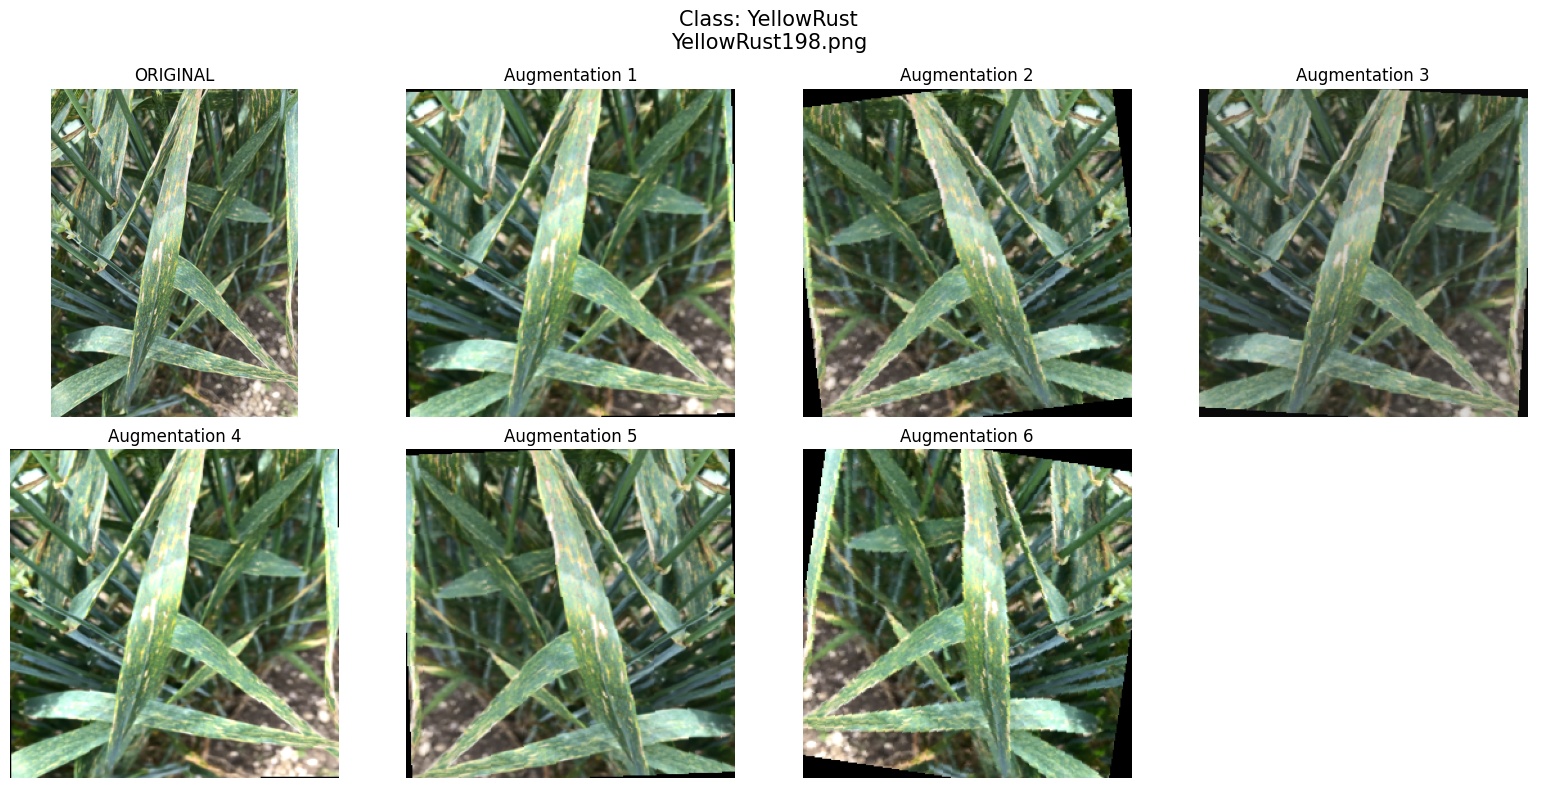

In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

# Pick one random training image
class_name = random.choice(train_dataset.classes)

class_folder = os.path.join(
    DATASET_PATH,
    "train",
    class_name
)

files = [
    f for f in os.listdir(class_folder)
    if f.lower().endswith(
        (".jpg", ".jpeg", ".png", ".bmp", ".webp")
    )
]

file_name = random.choice(files)

image_path = os.path.join(
    class_folder,
    file_name
)

original = Image.open(image_path).convert("RGB")


# --------------------------------------------------
# Visualization transform
# Same augmentation, but WITHOUT normalization
# --------------------------------------------------

visual_transform = transforms.Compose([

    transforms.Resize(288),

    transforms.RandomResizedCrop(
        256,
        scale=(0.80, 1.0)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.15,
        contrast=0.15,
        saturation=0.10
    )
])


# Generate different random versions
augmented_images = [
    visual_transform(original)
    for _ in range(6)
]


# --------------------------------------------------
# Display
# --------------------------------------------------

fig, axes = plt.subplots(2, 4, figsize=(16, 8))

axes = axes.flatten()

axes[0].imshow(original)
axes[0].set_title("ORIGINAL")
axes[0].axis("off")

for i, img in enumerate(augmented_images):

    axes[i + 1].imshow(img)

    axes[i + 1].set_title(
        f"Augmentation {i + 1}"
    )

    axes[i + 1].axis("off")


# Hide unused final plot
axes[-1].axis("off")

plt.suptitle(
    f"Class: {class_name}\n{file_name}",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [ ]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("GPU unavailable - using CPU")
    device = torch.device("cpu")

print("Device:", device)

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Device: cuda


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import torch

from PIL import Image
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Device:", device)

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Device: cuda


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/final_year_project/Wheat_Split_Clean"

IMAGE_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 0

SEED = 42

random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("Dataset:", DATASET_PATH)
print("Image size:", IMAGE_SIZE)
print("Batch size:", BATCH_SIZE)
print("Device:", device)

Dataset: /content/drive/MyDrive/final_year_project/Wheat_Split_Clean
Image size: 256
Batch size: 32
Device: cuda


In [ ]:
train_transform = transforms.Compose([

    transforms.Resize(300),

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.70, 1.0),
        ratio=(0.85, 1.15)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomVerticalFlip(p=0.15),

    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.15,
        hue=0.03
    ),

    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 1.0)
        )
    ], p=0.10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(288),

    transforms.CenterCrop(IMAGE_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("✓ Transforms ready")

✓ Transforms ready


In [ ]:
train_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "val"),
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "test"),
    transform=eval_transform
)

print("Classes:", train_dataset.classes)
print("Class mapping:", train_dataset.class_to_idx)

print("\nTrain :", len(train_dataset))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset))

assert len(train_dataset) == 1094
assert len(val_dataset) == 233
assert len(test_dataset) == 240

assert train_dataset.classes == val_dataset.classes
assert train_dataset.classes == test_dataset.classes

print("\n✓ Everything restored successfully.")

Classes: ['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']
Class mapping: {'BlackPoint': 0, 'Brown_Rust': 1, 'HealthyLeaf': 2, 'Mildew': 3, 'Septoria': 4, 'YellowRust': 5}

Train : 1094
Val   : 233
Test  : 240

✓ Everything restored successfully.


In [ ]:
import torch
from torch.utils.data import DataLoader
from collections import Counter

# --------------------------------------------------
# DATALOADERS
# --------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)


# --------------------------------------------------
# CLASS COUNTS - TRAINING SET ONLY
# --------------------------------------------------

targets = train_dataset.targets
class_counts_train = Counter(targets)

num_classes = len(train_dataset.classes)
total_train = len(train_dataset)

print("=" * 60)
print("TRAINING CLASS DISTRIBUTION")
print("=" * 60)

for class_name, class_index in train_dataset.class_to_idx.items():
    print(
        f"{class_name:<15}: "
        f"{class_counts_train[class_index]} images"
    )


# --------------------------------------------------
# BALANCED CLASS WEIGHTS
#
# weight_i = N / (C * n_i)
# --------------------------------------------------

class_weights = []

for class_index in range(num_classes):

    count = class_counts_train[class_index]

    weight = total_train / (
        num_classes * count
    )

    class_weights.append(weight)


class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)


print("\n" + "=" * 60)
print("CALCULATED CLASS WEIGHTS")
print("=" * 60)

for class_name, class_index in train_dataset.class_to_idx.items():

    print(
        f"{class_name:<15}: "
        f"{class_weights[class_index].item():.4f}"
    )


# --------------------------------------------------
# DATALOADER TEST
# --------------------------------------------------

images, labels = next(iter(train_loader))

print("\n" + "=" * 60)
print("DATALOADER CHECK")
print("=" * 60)

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)

print("Image dtype       :", images.dtype)
print("Label dtype       :", labels.dtype)

print("\nTrain batches :", len(train_loader))
print("Val batches   :", len(val_loader))
print("Test batches  :", len(test_loader))

print("\n✓ DataLoaders ready.")
print("✓ Class weights calculated.")

TRAINING CLASS DISTRIBUTION
BlackPoint     : 128 images
Brown_Rust     : 189 images
HealthyLeaf    : 219 images
Mildew         : 144 images
Septoria       : 239 images
YellowRust     : 175 images

CALCULATED CLASS WEIGHTS
BlackPoint     : 1.4245
Brown_Rust     : 0.9647
HealthyLeaf    : 0.8326
Mildew         : 1.2662
Septoria       : 0.7629
YellowRust     : 1.0419

DATALOADER CHECK
Image batch shape : torch.Size([32, 3, 256, 256])
Label batch shape : torch.Size([32])
Image dtype       : torch.float32
Label dtype       : torch.int64

Train batches : 35
Val batches   : 8
Test batches  : 8

✓ DataLoaders ready.
✓ Class weights calculated.


In [ ]:
import torch
import torch.nn as nn


# ============================================================
# CONVOLUTION BLOCK
# ============================================================

def conv_block(in_channels, out_channels, pool=False):

    layers = [
        nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        ),

        nn.BatchNorm2d(out_channels),

        nn.ReLU(inplace=True)
    ]

    if pool:
        layers.append(
            nn.MaxPool2d(2)
        )

    return nn.Sequential(*layers)


# ============================================================
# RESNET9 BACKBONE
# ============================================================

class ResNet9Backbone(nn.Module):

    def __init__(self):

        super().__init__()

        # 256 → 256
        self.conv1 = conv_block(
            3, 64
        )

        # 256 → 128
        self.conv2 = conv_block(
            64, 128,
            pool=True
        )

        # Residual block 1
        self.res1 = nn.Sequential(
            conv_block(128, 128),
            conv_block(128, 128)
        )

        # 128 → 64
        self.conv3 = conv_block(
            128, 256,
            pool=True
        )

        # 64 → 32
        self.conv4 = conv_block(
            256, 512,
            pool=True
        )

        # Residual block 2
        self.res2 = nn.Sequential(
            conv_block(512, 512),
            conv_block(512, 512)
        )


    def forward(self, x):

        x = self.conv1(x)

        x = self.conv2(x)

        x = self.res1(x) + x

        x = self.conv3(x)

        x = self.conv4(x)

        x = self.res2(x) + x

        return x


# ============================================================
# TRANSFORMER BLOCK
# ============================================================

class TransformerBlock(nn.Module):

    def __init__(
        self,
        embed_dim=64,
        num_heads=4,
        mlp_dim=128,
        dropout=0.1
    ):

        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)

        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(

            nn.Linear(
                embed_dim,
                mlp_dim
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                mlp_dim,
                embed_dim
            ),

            nn.Dropout(dropout)
        )


    def forward(self, x):

        # Pre-Norm Self Attention
        normalized = self.norm1(x)

        attention_output, _ = self.attention(
            normalized,
            normalized,
            normalized,
            need_weights=False
        )

        x = x + attention_output

        # Feed-forward network
        x = x + self.mlp(
            self.norm2(x)
        )

        return x


# ============================================================
# RESNET9 + SELF ATTENTION
# ============================================================

class WheatHybridModel(nn.Module):

    def __init__(
        self,
        num_classes=6,
        embed_dim=64,
        num_heads=4,
        mlp_dim=128,
        transformer_layers=2,
        dropout=0.30
    ):

        super().__init__()

        # CNN
        self.backbone = ResNet9Backbone()

        # Force feature map to 8 × 8
        self.feature_pool = nn.AdaptiveAvgPool2d(
            (8, 8)
        )

        # 512 CNN channels → 64 embedding dimensions
        self.projection = nn.Linear(
            512,
            embed_dim
        )

        # 8 × 8 = 64 spatial tokens
        self.pos_embedding = nn.Parameter(
            torch.zeros(
                1,
                64,
                embed_dim
            )
        )

        nn.init.trunc_normal_(
            self.pos_embedding,
            std=0.02
        )

        # Transformer blocks
        self.transformer = nn.Sequential(
            *[
                TransformerBlock(
                    embed_dim=embed_dim,
                    num_heads=num_heads,
                    mlp_dim=mlp_dim
                )
                for _ in range(transformer_layers)
            ]
        )

        self.final_norm = nn.LayerNorm(
            embed_dim
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.classifier = nn.Linear(
            embed_dim,
            num_classes
        )


    def forward(self, x):

        # --------------------------------
        # CNN
        # --------------------------------

        x = self.backbone(x)

        # Expected:
        # [B, 512, 32, 32]

        x = self.feature_pool(x)

        # [B, 512, 8, 8]


        # --------------------------------
        # Convert feature map → tokens
        # --------------------------------

        x = x.flatten(2)

        # [B, 512, 64]

        x = x.transpose(1, 2)

        # [B, 64, 512]

        x = self.projection(x)

        # [B, 64, 64]


        # --------------------------------
        # Positional information
        # --------------------------------

        x = x + self.pos_embedding


        # --------------------------------
        # Self Attention
        # --------------------------------

        x = self.transformer(x)

        x = self.final_norm(x)


        # --------------------------------
        # Global token pooling
        # --------------------------------

        x = x.mean(dim=1)

        # [B, 64]


        # --------------------------------
        # Classification
        # --------------------------------

        x = self.dropout(x)

        logits = self.classifier(x)

        return logits


print("✓ Model architecture defined.")

✓ Model architecture defined.


In [ ]:
model = WheatHybridModel(
    num_classes=len(train_dataset.classes)
).to(device)


# ------------------------------------------------------------
# PARAMETER COUNT
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("=" * 60)
print("WHEAT HYBRID MODEL")
print("=" * 60)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")

print("\nDevice:")
print(next(model.parameters()).device)


# ------------------------------------------------------------
# FORWARD-PASS TEST
# ------------------------------------------------------------

dummy = torch.randn(
    2,
    3,
    256,
    256
).to(device)

model.eval()

with torch.no_grad():
    output = model(dummy)


print("\nInput shape :", dummy.shape)
print("Output shape:", output.shape)

assert output.shape == (2, 6)

print("\n✓ Forward pass successful.")
print("✓ Model produces logits for 6 disease classes.")

WHEAT HYBRID MODEL
Total parameters     : 6,672,390
Trainable parameters : 6,672,390

Device:
cuda:0

Input shape : torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 6])

✓ Forward pass successful.
✓ Model produces logits for 6 disease classes.


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# LOSS
# ============================================================

# Baseline:
# We calculated class weights, but do NOT use them yet.
criterion = nn.CrossEntropyLoss()


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


# ============================================================
# LR SCHEDULER
# ============================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)


# ============================================================
# TRAINING SETTINGS
# ============================================================

MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8

BEST_MODEL_PATH = (
    "/content/drive/MyDrive/final_year_project/"
    "models/wheat_hybrid_clean_best.pth"
)

os.makedirs(
    os.path.dirname(BEST_MODEL_PATH),
    exist_ok=True
)


print("=" * 60)
print("EXPERIMENT 1 - TRAINING CONFIGURATION")
print("=" * 60)

print("Architecture       : ResNet9 + Self-Attention")
print("Parameters         : 6,672,390")
print("Input size         : 256 x 256")
print("Classes            : 6")

print("\nLoss               : CrossEntropyLoss")
print("Class weighting    : OFF")
print("Optimizer          : AdamW")
print("Initial LR         :", optimizer.param_groups[0]["lr"])
print("Weight decay       : 1e-4")

print("\nScheduler           : ReduceLROnPlateau")
print("Scheduler patience : 3")
print("Scheduler factor   : 0.5")

print("\nMax epochs          :", MAX_EPOCHS)
print("Early stop patience:", EARLY_STOPPING_PATIENCE)

print("\nDevice              :", device)
print("Checkpoint          :", BEST_MODEL_PATH)

print("\n✓ Training configuration ready.")

EXPERIMENT 1 - TRAINING CONFIGURATION
Architecture       : ResNet9 + Self-Attention
Parameters         : 6,672,390
Input size         : 256 x 256
Classes            : 6

Loss               : CrossEntropyLoss
Class weighting    : OFF
Optimizer          : AdamW
Initial LR         : 0.001
Weight decay       : 1e-4

Scheduler           : ReduceLROnPlateau
Scheduler patience : 3
Scheduler factor   : 0.5

Max epochs          : 50
Early stop patience: 8

Device              : cuda
Checkpoint          : /content/drive/MyDrive/final_year_project/models/wheat_hybrid_clean_best.pth

✓ Training configuration ready.


In [ ]:
from sklearn.metrics import f1_score
import numpy as np
import time

In [ ]:
# ============================================================
# MIXED PRECISION SETUP
# ============================================================

scaler = torch.amp.GradScaler("cuda")

best_val_f1 = -1.0
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "lr": []
}


# ============================================================
# TRAINING
# ============================================================

print("=" * 75)
print("STARTING EXPERIMENT 1")
print("=" * 75)

training_start = time.time()


for epoch in range(1, MAX_EPOCHS + 1):

    epoch_start = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # Mixed precision
        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()


        # Statistics
        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)


    train_loss = running_loss / total
    train_acc = correct / total


    # ========================================================
    # VALIDATION
    # ========================================================

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    all_val_labels = []
    all_val_predictions = []


    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )


            val_running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

            all_val_labels.extend(
                labels.cpu().numpy()
            )

            all_val_predictions.extend(
                predictions.cpu().numpy()
            )


    val_loss = (
        val_running_loss /
        val_total
    )

    val_acc = (
        val_correct /
        val_total
    )

    val_macro_f1 = f1_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )


    # ========================================================
    # LR SCHEDULER
    # ========================================================

    scheduler.step(val_loss)

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )


    # ========================================================
    # HISTORY
    # ========================================================

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    history["val_f1"].append(
        val_macro_f1
    )

    history["lr"].append(
        current_lr
    )


    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    improved = (
        val_macro_f1 >
        best_val_f1 + 1e-4
    )

    if improved:

        best_val_f1 = val_macro_f1

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_loss":
                    val_loss,

                "val_accuracy":
                    val_acc,

                "val_macro_f1":
                    val_macro_f1,

                "classes":
                    train_dataset.classes,

                "class_to_idx":
                    train_dataset.class_to_idx
            },

            BEST_MODEL_PATH
        )

        checkpoint_status = "✓ SAVED"

    else:

        epochs_without_improvement += 1

        checkpoint_status = ""


    # ========================================================
    # DISPLAY
    # ========================================================

    epoch_time = (
        time.time() -
        epoch_start
    )

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train Loss {train_loss:.4f} | "
        f"Train Acc {train_acc*100:6.2f}% | "
        f"Val Loss {val_loss:.4f} | "
        f"Val Acc {val_acc*100:6.2f}% | "
        f"Macro F1 {val_macro_f1:.4f} | "
        f"LR {current_lr:.2e} | "
        f"{epoch_time:.1f}s "
        f"{checkpoint_status}"
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if (
        epochs_without_improvement >=
        EARLY_STOPPING_PATIENCE
    ):

        print("\n" + "=" * 75)

        print(
            f"EARLY STOPPING at epoch {epoch}"
        )

        print(
            f"Best validation Macro F1: "
            f"{best_val_f1:.4f}"
        )

        print("=" * 75)

        break


# ============================================================
# COMPLETE
# ============================================================

total_training_time = (
    time.time() -
    training_start
)

print("\n" + "=" * 75)
print("TRAINING COMPLETE")
print("=" * 75)

print(
    f"Best Validation Macro F1 : "
    f"{best_val_f1:.4f}"
)

print(
    f"Total training time      : "
    f"{total_training_time / 60:.2f} minutes"
)

print(
    "Best checkpoint          :",
    BEST_MODEL_PATH
)

STARTING EXPERIMENT 1


KeyboardInterrupt: 

In [ ]:
import time
import torch

print("=" * 60)
print("SPEED DIAGNOSTIC")
print("=" * 60)

# ------------------------------------------------------------
# 1. DataLoader speed
# ------------------------------------------------------------

start = time.time()

images, labels = next(iter(train_loader))

load_time = time.time() - start

print(f"\nBatch loading time : {load_time:.2f} seconds")
print("Batch shape        :", images.shape)


# ------------------------------------------------------------
# 2. GPU transfer speed
# ------------------------------------------------------------

start = time.time()

images = images.to(device, non_blocking=True)
labels = labels.to(device, non_blocking=True)

torch.cuda.synchronize()

transfer_time = time.time() - start

print(f"GPU transfer time  : {transfer_time:.4f} seconds")


# ------------------------------------------------------------
# 3. Forward pass speed
# ------------------------------------------------------------

model.eval()

start = time.time()

with torch.no_grad():

    with torch.amp.autocast(
        device_type="cuda",
        dtype=torch.float16
    ):
        outputs = model(images)

torch.cuda.synchronize()

forward_time = time.time() - start

print(f"Forward pass time  : {forward_time:.4f} seconds")


# ------------------------------------------------------------
# 4. Result
# ------------------------------------------------------------

print("\n" + "=" * 60)
print("RESULT")
print("=" * 60)

print("Data loading :", load_time)
print("GPU transfer :", transfer_time)
print("Model forward:", forward_time)

SPEED DIAGNOSTIC

Batch loading time : 3.11 seconds
Batch shape        : torch.Size([32, 3, 256, 256])
GPU transfer time  : 0.0076 seconds
Forward pass time  : 0.1744 seconds

RESULT
Data loading : 3.1108858585357666
GPU transfer : 0.007630825042724609
Model forward: 0.17439818382263184


In [ ]:
import os
import shutil
import time

DRIVE_DATASET = (
    "/content/drive/MyDrive/"
    "final_year_project/Wheat_Split_Clean"
)

LOCAL_DATASET = "/content/Wheat_Split_Clean"


print("=" * 60)
print("COPYING DATASET TO COLAB LOCAL STORAGE")
print("=" * 60)

start = time.time()

# Remove an incomplete previous local copy if present
if os.path.exists(LOCAL_DATASET):
    shutil.rmtree(LOCAL_DATASET)

shutil.copytree(
    DRIVE_DATASET,
    LOCAL_DATASET
)

elapsed = time.time() - start

print("\n✓ Dataset copied successfully.")
print("Local path :", LOCAL_DATASET)
print(f"Copy time  : {elapsed:.2f} seconds")

COPYING DATASET TO COLAB LOCAL STORAGE

✓ Dataset copied successfully.
Local path : /content/Wheat_Split_Clean
Copy time  : 214.39 seconds


In [ ]:
for split in ["train", "val", "test"]:

    split_path = os.path.join(
        LOCAL_DATASET,
        split
    )

    count = 0

    for class_name in os.listdir(split_path):

        class_path = os.path.join(
            split_path,
            class_name
        )

        if os.path.isdir(class_path):
            count += len([
                f for f in os.listdir(class_path)
                if os.path.isfile(
                    os.path.join(class_path, f)
                )
            ])

    print(f"{split:<5}: {count}")

train: 1094
val  : 233
test : 240


In [ ]:
from torchvision import datasets
from torch.utils.data import DataLoader

# ============================================================
# USE LOCAL DATASET
# ============================================================

DATASET_PATH = "/content/Wheat_Split_Clean"

train_dataset = datasets.ImageFolder(
    root=f"{DATASET_PATH}/train",
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    root=f"{DATASET_PATH}/val",
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    root=f"{DATASET_PATH}/test",
    transform=eval_transform
)


# ============================================================
# DATALOADERS
# ============================================================

NUM_WORKERS = 2

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)


print("=" * 60)
print("LOCAL DATASET READY")
print("=" * 60)

print("Dataset path :", DATASET_PATH)
print("Train        :", len(train_dataset))
print("Validation   :", len(val_dataset))
print("Test         :", len(test_dataset))
print("Workers      :", NUM_WORKERS)

print("\nClasses:")
print(train_dataset.classes)

print("\n✓ Local DataLoaders ready.")

LOCAL DATASET READY
Dataset path : /content/Wheat_Split_Clean
Train        : 1094
Validation   : 233
Test         : 240
Workers      : 2

Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

✓ Local DataLoaders ready.


In [ ]:
import time
import torch

# Warm up workers first
print("Warming up DataLoader...")

images, labels = next(iter(train_loader))

print("Warm-up complete.\n")


# Actual measurement
start = time.time()

images, labels = next(iter(train_loader))

load_time = time.time() - start


images = images.to(
    device,
    non_blocking=True
)

labels = labels.to(
    device,
    non_blocking=True
)


model.eval()

torch.cuda.synchronize()

start = time.time()

with torch.no_grad():

    with torch.amp.autocast(
        device_type="cuda",
        dtype=torch.float16
    ):

        outputs = model(images)

torch.cuda.synchronize()

forward_time = time.time() - start


print("=" * 60)
print("LOCAL SPEED TEST")
print("=" * 60)

print(f"Batch loading time : {load_time:.3f} seconds")
print(f"Forward pass time  : {forward_time:.3f} seconds")
print("Batch shape        :", images.shape)

Warming up DataLoader...
Warm-up complete.

LOCAL SPEED TEST
Batch loading time : 5.307 seconds
Forward pass time  : 0.169 seconds
Batch shape        : torch.Size([32, 3, 256, 256])


In [ ]:
import time

print("=" * 60)
print("DATALOADER THROUGHPUT TEST")
print("=" * 60)

loader_iter = iter(train_loader)

# First batch = worker/process warm-up
start = time.time()
images, labels = next(loader_iter)
first_time = time.time() - start

print(f"First batch : {first_time:.3f} sec")


# Measure next 10 batches continuously
times = []

for i in range(10):

    start = time.time()

    images, labels = next(loader_iter)

    elapsed = time.time() - start
    times.append(elapsed)

    print(
        f"Batch {i+2:02d}: "
        f"{elapsed:.3f} sec"
    )


average = sum(times) / len(times)

print("\n" + "=" * 60)
print(f"Average after warm-up : {average:.3f} sec/batch")
print(f"Estimated 35 batches  : {average * 35:.1f} sec")
print("=" * 60)

DATALOADER THROUGHPUT TEST
First batch : 4.331 sec
Batch 02: 0.470 sec
Batch 03: 2.625 sec
Batch 04: 0.297 sec
Batch 05: 1.392 sec
Batch 06: 0.047 sec
Batch 07: 1.544 sec
Batch 08: 0.506 sec
Batch 09: 1.061 sec
Batch 10: 0.607 sec
Batch 11: 0.838 sec

Average after warm-up : 0.939 sec/batch
Estimated 35 batches  : 32.9 sec


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# ============================================================
# REPRODUCIBILITY
# ============================================================

SEED = 42

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ============================================================
# CREATE A COMPLETELY FRESH MODEL
# ============================================================

model = WheatHybridModel(
    num_classes=len(train_dataset.classes)
).to(device)


# ============================================================
# LOSS
# ============================================================

criterion = nn.CrossEntropyLoss()


# ============================================================
# OPTIMIZER
# ============================================================

optimizer = optim.AdamW(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)


# ============================================================
# SCHEDULER
# ============================================================

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)


# ============================================================
# AMP SCALER
# ============================================================

scaler = torch.amp.GradScaler("cuda")


# ============================================================
# TRAINING STATE
# ============================================================

best_val_f1 = -1.0
epochs_without_improvement = 0

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "lr": []
}


print("=" * 60)
print("EXPERIMENT 1 RESET")
print("=" * 60)

print("Model parameters :", f"{sum(p.numel() for p in model.parameters()):,}")
print("Device           :", next(model.parameters()).device)
print("Loss             : CrossEntropyLoss")
print("Class weights    : OFF")
print("Optimizer        : AdamW")
print("Learning rate    :", optimizer.param_groups[0]["lr"])

print("\n✓ Fresh model created.")
print("✓ Optimizer reset.")
print("✓ Scheduler reset.")
print("✓ AMP scaler reset.")
print("✓ Training history reset.")
print("\nReady for clean Experiment 1.")

EXPERIMENT 1 RESET
Model parameters : 6,672,390
Device           : cuda:0
Loss             : CrossEntropyLoss
Class weights    : OFF
Optimizer        : AdamW
Learning rate    : 0.001

✓ Fresh model created.
✓ Optimizer reset.
✓ Scheduler reset.
✓ AMP scaler reset.
✓ Training history reset.

Ready for clean Experiment 1.


In [ ]:
from sklearn.metrics import f1_score
import time

print("=" * 75)
print("STARTING CLEAN EXPERIMENT 1")
print("=" * 75)

training_start = time.time()

for epoch in range(1, MAX_EPOCHS + 1):

    epoch_start = time.time()

    print(f"\n{'=' * 75}")
    print(f"EPOCH {epoch:02d}/{MAX_EPOCHS}")
    print("=" * 75)

    # ========================================================
    # TRAINING
    # ========================================================

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    print("Training...")

    for batch_idx, (images, labels) in enumerate(
        train_loader,
        start=1
    ):

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # Mixed Precision
        with torch.amp.autocast(
            device_type="cuda",
            dtype=torch.float16
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        # Statistics
        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        # Progress
        if (
            batch_idx % 5 == 0
            or batch_idx == len(train_loader)
        ):

            print(
                f"  Batch "
                f"{batch_idx:02d}/{len(train_loader)}"
            )

    train_loss = running_loss / total
    train_acc = correct / total

    # ========================================================
    # VALIDATION
    # ========================================================

    print("Validation...")

    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    all_val_labels = []
    all_val_predictions = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            with torch.amp.autocast(
                device_type="cuda",
                dtype=torch.float16
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            val_running_loss += (
                loss.item() * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

            all_val_labels.extend(
                labels.cpu().numpy()
            )

            all_val_predictions.extend(
                predictions.cpu().numpy()
            )

    val_loss = (
        val_running_loss / val_total
    )

    val_acc = (
        val_correct / val_total
    )

    val_macro_f1 = f1_score(
        all_val_labels,
        all_val_predictions,
        average="macro",
        zero_division=0
    )

    # ========================================================
    # SCHEDULER
    # ========================================================

    scheduler.step(val_loss)

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    # ========================================================
    # HISTORY
    # ========================================================

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)

    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)

    history["val_f1"].append(
        val_macro_f1
    )

    history["lr"].append(
        current_lr
    )

    # ========================================================
    # BEST CHECKPOINT
    # ========================================================

    improved = (
        val_macro_f1 >
        best_val_f1 + 1e-4
    )

    if improved:

        best_val_f1 = val_macro_f1

        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "val_loss":
                    val_loss,

                "val_accuracy":
                    val_acc,

                "val_macro_f1":
                    val_macro_f1,

                "classes":
                    train_dataset.classes,

                "class_to_idx":
                    train_dataset.class_to_idx
            },

            BEST_MODEL_PATH
        )

        status = "✓ BEST MODEL SAVED"

    else:

        epochs_without_improvement += 1
        status = ""

    # ========================================================
    # EPOCH RESULTS
    # ========================================================

    epoch_time = (
        time.time() - epoch_start
    )

    print("\nResults:")

    print(
        f"Train Loss : {train_loss:.4f}"
    )

    print(
        f"Train Acc  : {train_acc * 100:.2f}%"
    )

    print(
        f"Val Loss   : {val_loss:.4f}"
    )

    print(
        f"Val Acc    : {val_acc * 100:.2f}%"
    )

    print(
        f"Macro F1   : {val_macro_f1:.4f}"
    )

    print(
        f"LR         : {current_lr:.2e}"
    )

    print(
        f"Epoch Time : {epoch_time:.1f} sec"
    )

    if status:
        print(status)

    print(
        f"Early Stop : "
        f"{epochs_without_improvement}/"
        f"{EARLY_STOPPING_PATIENCE}"
    )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if (
        epochs_without_improvement >=
        EARLY_STOPPING_PATIENCE
    ):

        print("\n" + "=" * 75)
        print(
            f"EARLY STOPPING TRIGGERED "
            f"AT EPOCH {epoch}"
        )
        print(
            f"Best Validation Macro F1: "
            f"{best_val_f1:.4f}"
        )
        print("=" * 75)

        break


# ============================================================
# FINISHED
# ============================================================

total_training_time = (
    time.time() - training_start
)

print("\n" + "=" * 75)
print("EXPERIMENT 1 COMPLETE")
print("=" * 75)

print(
    f"Best Validation Macro F1 : "
    f"{best_val_f1:.4f}"
)

print(
    f"Training time            : "
    f"{total_training_time / 60:.2f} minutes"
)

print(
    f"Best checkpoint          : "
    f"{BEST_MODEL_PATH}"
)

STARTING CLEAN EXPERIMENT 1

EPOCH 01/50
Training...
  Batch 05/35
  Batch 10/35
  Batch 15/35
  Batch 20/35
  Batch 25/35
  Batch 30/35
  Batch 35/35
Validation...

Results:
Train Loss : 1.5688
Train Acc  : 38.67%
Val Loss   : 1.2965
Val Acc    : 51.07%
Macro F1   : 0.4440
LR         : 1.00e-03
Epoch Time : 47.6 sec
✓ BEST MODEL SAVED
Early Stop : 0/8

EPOCH 02/50
Training...
  Batch 05/35
  Batch 10/35
  Batch 15/35
  Batch 20/35
  Batch 25/35
  Batch 30/35
  Batch 35/35
Validation...

Results:
Train Loss : 1.4242
Train Acc  : 44.97%
Val Loss   : 1.1979
Val Acc    : 55.79%
Macro F1   : 0.5000
LR         : 1.00e-03
Epoch Time : 46.2 sec
✓ BEST MODEL SAVED
Early Stop : 0/8

EPOCH 03/50
Training...
  Batch 05/35
  Batch 10/35
  Batch 15/35
  Batch 20/35
  Batch 25/35
  Batch 30/35
  Batch 35/35
Validation...

Results:
Train Loss : 1.3615
Train Acc  : 48.08%
Val Loss   : 1.2334
Val Acc    : 53.22%
Macro F1   : 0.4949
LR         : 1.00e-03
Epoch Time : 47.8 sec
Early Stop : 1/8

EPOCH 04/

In [ ]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    device = torch.device("cuda")
else:
    print("GPU not available")
    device = torch.device("cpu")

print("Device:", device)

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4
Device: cuda


In [ ]:
from google.colab import drive
import os

drive.mount('/content/drive')

BEST_MODEL_PATH = "/content/drive/MyDrive/final_year_project/models/wheat_hybrid_clean_best.pth"

print("\nChecking saved model...")

if os.path.exists(BEST_MODEL_PATH):
    size_mb = os.path.getsize(BEST_MODEL_PATH) / (1024 * 1024)

    print("✓ Best checkpoint found")
    print("Path:", BEST_MODEL_PATH)
    print(f"Size: {size_mb:.2f} MB")
else:
    print("✗ Checkpoint NOT found")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

Checking saved model...
✓ Best checkpoint found
Path: /content/drive/MyDrive/final_year_project/models/wheat_hybrid_clean_best.pth
Size: 76.45 MB


In [ ]:
import os
import shutil

DRIVE_DATASET = "/content/drive/MyDrive/final_year_project/Wheat_Split_Clean"
LOCAL_DATASET = "/content/Wheat_Split_Clean"

# Make sure Drive dataset exists
if not os.path.exists(DRIVE_DATASET):
    raise FileNotFoundError(f"Dataset not found: {DRIVE_DATASET}")

# Copy only if local copy does not already exist
if not os.path.exists(LOCAL_DATASET):
    print("Copying dataset from Google Drive to Colab SSD...")
    shutil.copytree(DRIVE_DATASET, LOCAL_DATASET)
    print("✓ Dataset copied")
else:
    print("✓ Local dataset already exists")

print("\nVerifying dataset:")

for split in ["train", "val", "test"]:
    split_path = os.path.join(LOCAL_DATASET, split)

    total = 0

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if os.path.isdir(class_path):
            total += len([
                f for f in os.listdir(class_path)
                if os.path.isfile(os.path.join(class_path, f))
            ])

    print(f"{split:5s}: {total} images")

✓ Local dataset already exists

Verifying dataset:
train: 1094 images
val  : 233 images
test : 240 images


In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import os

IMAGE_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 2

# --------------------------------------------------
# TRAIN TRANSFORM — same as Experiment 1
# --------------------------------------------------

train_transform = transforms.Compose([
    transforms.Resize(300),

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.70, 1.0),
        ratio=(0.85, 1.15)
    ),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.15),
    transforms.RandomRotation(20),

    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.15,
        hue=0.03
    ),

    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 1.0)
        )
    ], p=0.10),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# --------------------------------------------------
# VALIDATION / TEST TRANSFORM
# --------------------------------------------------

eval_transform = transforms.Compose([
    transforms.Resize(288),
    transforms.CenterCrop(IMAGE_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# --------------------------------------------------
# DATASETS
# --------------------------------------------------

train_dataset = datasets.ImageFolder(
    os.path.join(LOCAL_DATASET, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(LOCAL_DATASET, "val"),
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    os.path.join(LOCAL_DATASET, "test"),
    transform=eval_transform
)


# --------------------------------------------------
# DATALOADERS
# --------------------------------------------------

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)


# --------------------------------------------------
# VERIFY
# --------------------------------------------------

print("Dataset restored successfully\n")

print("Classes:")
for i, name in enumerate(train_dataset.classes):
    print(f"  {i}: {name}")

print("\nDataset sizes:")
print("Train:", len(train_dataset))
print("Val  :", len(val_dataset))
print("Test :", len(test_dataset))

print("\nClass mapping:")
print(train_dataset.class_to_idx)

assert train_dataset.classes == val_dataset.classes == test_dataset.classes

print("\n✓ Train/Val/Test class mappings match")

Dataset restored successfully

Classes:
  0: BlackPoint
  1: Brown_Rust
  2: HealthyLeaf
  3: Mildew
  4: Septoria
  5: YellowRust

Dataset sizes:
Train: 1094
Val  : 233
Test : 240

Class mapping:
{'BlackPoint': 0, 'Brown_Rust': 1, 'HealthyLeaf': 2, 'Mildew': 3, 'Septoria': 4, 'YellowRust': 5}

✓ Train/Val/Test class mappings match


In [ ]:
import torch
import torch.nn as nn


# ============================================================
# 1. RESNET9 BACKBONE
# ============================================================

def conv_block(in_channels, out_channels, pool=False):
    layers = [
        nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        ),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    ]

    if pool:
        layers.append(nn.MaxPool2d(2))

    return nn.Sequential(*layers)


class ResNet9Backbone(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = conv_block(3, 64)
        self.conv2 = conv_block(64, 128, pool=True)

        self.res1 = nn.Sequential(
            conv_block(128, 128),
            conv_block(128, 128)
        )

        self.conv3 = conv_block(128, 256, pool=True)
        self.conv4 = conv_block(256, 512, pool=True)

        self.res2 = nn.Sequential(
            conv_block(512, 512),
            conv_block(512, 512)
        )

    def forward(self, x):

        x = self.conv1(x)
        x = self.conv2(x)

        x = self.res1(x) + x

        x = self.conv3(x)
        x = self.conv4(x)

        x = self.res2(x) + x

        return x


# ============================================================
# 2. TRANSFORMER BLOCK
# ============================================================

class TransformerBlock(nn.Module):

    def __init__(
        self,
        embed_dim=64,
        num_heads=4,
        mlp_dim=128,
        dropout=0.1
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)

        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):

        normalized = self.norm1(x)

        attention_output, _ = self.attention(
            normalized,
            normalized,
            normalized,
            need_weights=False
        )

        x = x + attention_output

        x = x + self.mlp(self.norm2(x))

        return x


# ============================================================
# 3. COMPLETE HYBRID MODEL
# ============================================================

class WheatHybridModel(nn.Module):

    def __init__(
        self,
        num_classes=6,
        embed_dim=64,
        num_heads=4,
        mlp_dim=128,
        transformer_layers=2,
        dropout=0.30
    ):
        super().__init__()

        self.backbone = ResNet9Backbone()

        self.feature_pool = nn.AdaptiveAvgPool2d((8, 8))

        self.projection = nn.Linear(512, embed_dim)

        self.pos_embedding = nn.Parameter(
            torch.zeros(1, 64, embed_dim)
        )

        nn.init.trunc_normal_(
            self.pos_embedding,
            std=0.02
        )

        self.transformer = nn.Sequential(
            *[
                TransformerBlock(
                    embed_dim=embed_dim,
                    num_heads=num_heads,
                    mlp_dim=mlp_dim
                )
                for _ in range(transformer_layers)
            ]
        )

        self.final_norm = nn.LayerNorm(embed_dim)

        self.dropout = nn.Dropout(dropout)

        self.classifier = nn.Linear(
            embed_dim,
            num_classes
        )

    def forward(self, x):

        x = self.backbone(x)

        x = self.feature_pool(x)

        x = x.flatten(2).transpose(1, 2)

        x = self.projection(x)

        x = x + self.pos_embedding

        x = self.transformer(x)

        x = self.final_norm(x)

        x = x.mean(dim=1)

        x = self.dropout(x)

        x = self.classifier(x)

        return x


# ============================================================
# 4. CREATE MODEL
# ============================================================

model = WheatHybridModel(
    num_classes=6,
    embed_dim=64,
    num_heads=4,
    mlp_dim=128,
    transformer_layers=2,
    dropout=0.30
).to(device)


# ============================================================
# 5. LOAD BEST CHECKPOINT
# ============================================================

checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model.load_state_dict(checkpoint["model_state_dict"])

model.eval()


# ============================================================
# 6. VERIFY RESTORATION
# ============================================================

total_params = sum(p.numel() for p in model.parameters())

print("=" * 60)
print("BEST MODEL RESTORED")
print("=" * 60)

print("Checkpoint epoch :", checkpoint["epoch"])
print("Val Loss         :", checkpoint["val_loss"])
print("Val Accuracy     :", checkpoint["val_accuracy"])
print("Val Macro F1     :", checkpoint["val_macro_f1"])

print("\nClasses:")
print(checkpoint["classes"])

print("\nClass mapping:")
print(checkpoint["class_to_idx"])

print(f"\nTotal parameters : {total_params:,}")
print("Device           :", device)

print("\n✓ Model is in evaluation mode")
print("Training mode    :", model.training)

BEST MODEL RESTORED
Checkpoint epoch : 35
Val Loss         : 0.5322299034298745
Val Accuracy     : 0.8240343347639485
Val Macro F1     : 0.8121178589928589

Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

Class mapping:
{'BlackPoint': 0, 'Brown_Rust': 1, 'HealthyLeaf': 2, 'Mildew': 3, 'Septoria': 4, 'YellowRust': 5}

Total parameters : 6,672,390
Device           : cuda

✓ Model is in evaluation mode
Training mode    : False


In [ ]:
import torch
from sklearn.metrics import classification_report, accuracy_score, f1_score

# Store true labels and model predictions
val_true = []
val_pred = []

model.eval()

print("Running detailed validation evaluation...")

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Mixed precision inference
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):
            outputs = model(images)

        predictions = outputs.argmax(dim=1)

        val_true.extend(labels.cpu().numpy())
        val_pred.extend(predictions.cpu().numpy())


# --------------------------------------------------
# OVERALL RESULTS
# --------------------------------------------------

val_accuracy = accuracy_score(val_true, val_pred)

val_macro_f1 = f1_score(
    val_true,
    val_pred,
    average="macro"
)

print("\n" + "=" * 70)
print("VALIDATION RESULTS — BEST CHECKPOINT")
print("=" * 70)

print(f"Accuracy : {val_accuracy * 100:.2f}%")
print(f"Macro F1 : {val_macro_f1:.4f}")


# --------------------------------------------------
# PER-CLASS RESULTS
# --------------------------------------------------

print("\nPER-CLASS CLASSIFICATION REPORT\n")

print(
    classification_report(
        val_true,
        val_pred,
        target_names=val_dataset.classes,
        digits=4,
        zero_division=0
    )
)

Running detailed validation evaluation...

VALIDATION RESULTS — BEST CHECKPOINT
Accuracy : 82.40%
Macro F1 : 0.8121

PER-CLASS CLASSIFICATION REPORT

              precision    recall  f1-score   support

  BlackPoint     0.9600    0.8889    0.9231        27
  Brown_Rust     0.7500    0.9000    0.8182        40
 HealthyLeaf     0.8462    0.9362    0.8889        47
      Mildew     0.8500    0.5484    0.6667        31
    Septoria     0.7869    0.9412    0.8571        51
  YellowRust     0.8519    0.6216    0.7188        37

    accuracy                         0.8240       233
   macro avg     0.8408    0.8060    0.8121       233
weighted avg     0.8313    0.8240    0.8172       233



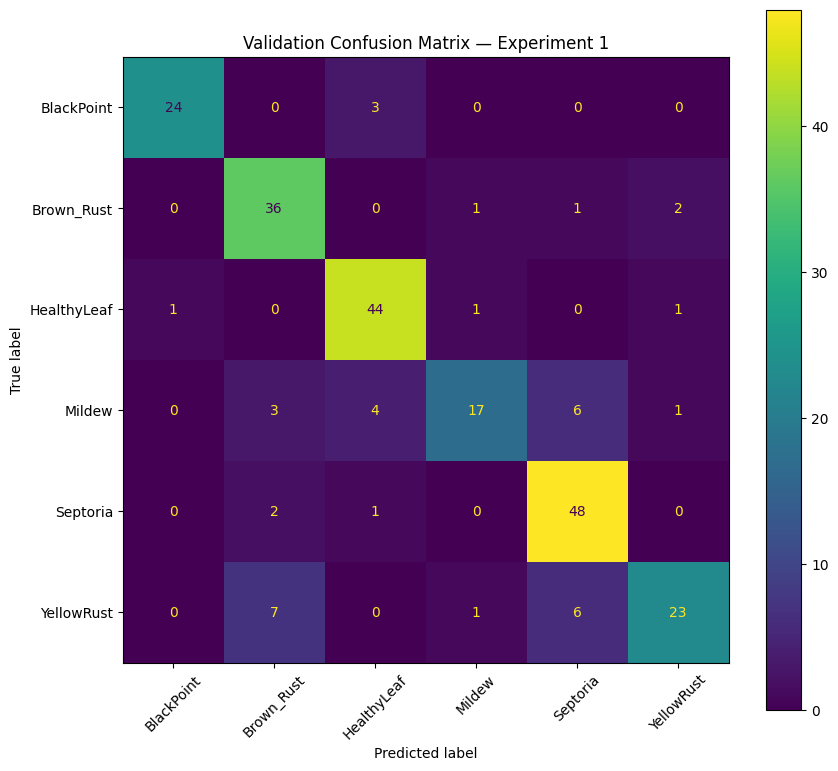

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(val_true, val_pred)

fig, ax = plt.subplots(figsize=(9, 8))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=val_dataset.classes
)

disp.plot(
    ax=ax,
    values_format="d",
    xticks_rotation=45
)

plt.title("Validation Confusion Matrix — Experiment 1")
plt.tight_layout()
plt.show()

In [ ]:
print("Classes:")
print(val_dataset.classes)

print("\nConfusion Matrix:")
print(cm)


Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

Confusion Matrix:
[[24  0  3  0  0  0]
 [ 0 36  0  1  1  2]
 [ 1  0 44  1  0  1]
 [ 0  3  4 17  6  1]
 [ 0  2  1  0 48  0]
 [ 0  7  0  1  6 23]]


# Experiment 2 — Class-Weighted Cross Entropy

### Objective
Improve minority/weak-class performance, particularly Mildew and YellowRust,
using class-weighted CrossEntropyLoss.

### Controlled Experiment
Compared with Experiment 1:
- Same clean dataset
- Same 70/15/15 split
- Same ResNet9 + Self-Attention architecture
- Same image size: 256×256
- Same augmentation
- Same optimizer
- Same learning-rate scheduler
- Same early stopping strategy
- Fresh model initialization

Only primary change:
**Standard CrossEntropyLoss → Class-Weighted CrossEntropyLoss**

In [ ]:
import numpy as np
import torch
from collections import Counter

# -----------------------------------------
# Calculate training class distribution
# -----------------------------------------

train_targets = train_dataset.targets

class_counts = Counter(train_targets)

num_classes = len(train_dataset.classes)
total_train = len(train_dataset)

class_weights = []

print("=" * 65)
print("EXPERIMENT 2 — CLASS WEIGHT CALCULATION")
print("=" * 65)

for class_index, class_name in enumerate(train_dataset.classes):

    count = class_counts[class_index]

    weight = total_train / (num_classes * count)

    class_weights.append(weight)

    print(
        f"{class_name:<15} "
        f"Images: {count:<4} "
        f"Weight: {weight:.4f}"
    )

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)

print("\nClass-weight tensor:")
print(class_weights)

print("\nDevice:")
print(class_weights.device)

EXPERIMENT 2 — CLASS WEIGHT CALCULATION
BlackPoint      Images: 128  Weight: 1.4245
Brown_Rust      Images: 189  Weight: 0.9647
HealthyLeaf     Images: 219  Weight: 0.8326
Mildew          Images: 144  Weight: 1.2662
Septoria        Images: 239  Weight: 0.7629
YellowRust      Images: 175  Weight: 1.0419

Class-weight tensor:
tensor([1.4245, 0.9647, 0.8326, 1.2662, 0.7629, 1.0419], device='cuda:0')

Device:
cuda:0


In [ ]:
import torch
import torch.nn as nn

# ============================================================
# EXPERIMENT 2 — FRESH MODEL INITIALIZATION
# ============================================================

SEED = 42

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# Create a completely fresh model
# ------------------------------------------------------------

model_exp2 = WheatHybridModel(
    num_classes=6,
    embed_dim=64,
    num_heads=4,
    mlp_dim=128,
    transformer_layers=2,
    dropout=0.30
).to(device)


# ------------------------------------------------------------
# Weighted CrossEntropyLoss
# ------------------------------------------------------------

criterion_exp2 = nn.CrossEntropyLoss(
    weight=class_weights
)


# ------------------------------------------------------------
# Check model
# ------------------------------------------------------------

total_params = sum(
    p.numel() for p in model_exp2.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model_exp2.parameters()
    if p.requires_grad
)


print("=" * 65)
print("EXPERIMENT 2 — FRESH MODEL INITIALIZED")
print("=" * 65)

print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"Device               : {device}")

print("\nLoss function:")
print(criterion_exp2)

print("\nClass weights:")
for class_name, weight in zip(
    train_dataset.classes,
    class_weights.detach().cpu().numpy()
):
    print(f"{class_name:<15}: {weight:.4f}")


# ------------------------------------------------------------
# Sanity-check output shape
# ------------------------------------------------------------

model_exp2.eval()

dummy_input = torch.randn(
    2, 3, IMAGE_SIZE, IMAGE_SIZE
).to(device)

with torch.no_grad():
    dummy_output = model_exp2(dummy_input)

print("\nDummy input shape :", dummy_input.shape)
print("Model output shape:", dummy_output.shape)

assert dummy_output.shape == (2, 6)

print("\n✓ Experiment 2 model sanity check passed")


# Return to training mode for later
model_exp2.train()

EXPERIMENT 2 — FRESH MODEL INITIALIZED
Total parameters     : 6,672,390
Trainable parameters : 6,672,390
Device               : cuda

Loss function:
CrossEntropyLoss()

Class weights:
BlackPoint     : 1.4245
Brown_Rust     : 0.9647
HealthyLeaf    : 0.8326
Mildew         : 1.2662
Septoria       : 0.7629
YellowRust     : 1.0419

Dummy input shape : torch.Size([2, 3, 256, 256])
Model output shape: torch.Size([2, 6])

✓ Experiment 2 model sanity check passed


WheatHybridModel(
  (backbone): ResNet9Backbone(
    (conv1): Sequential(
      (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
    )
    (conv2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (res1): Sequential(
      (0): Sequential(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (1): Sequential(
        (0): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias

In [ ]:
import os
import torch

# ============================================================
# EXPERIMENT 2 — TRAINING CONFIGURATION
# ============================================================

# Training settings
MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4


# ------------------------------------------------------------
# Fresh optimizer
# ------------------------------------------------------------

optimizer_exp2 = torch.optim.AdamW(
    model_exp2.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)


# ------------------------------------------------------------
# Fresh LR scheduler
# ------------------------------------------------------------

scheduler_exp2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_exp2,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)


# ------------------------------------------------------------
# AMP scaler
# ------------------------------------------------------------

scaler_exp2 = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda")
)


# ------------------------------------------------------------
# Separate Experiment 2 checkpoint
# ------------------------------------------------------------

MODEL_DIR = "/content/drive/MyDrive/final_year_project/models"

os.makedirs(MODEL_DIR, exist_ok=True)

EXP2_MODEL_PATH = os.path.join(
    MODEL_DIR,
    "wheat_hybrid_weighted_best.pth"
)


# ------------------------------------------------------------
# Fresh training state
# ------------------------------------------------------------

best_val_f1_exp2 = 0.0
early_stop_counter_exp2 = 0

history_exp2 = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_f1": [],
    "lr": []
}


# ------------------------------------------------------------
# Verification
# ------------------------------------------------------------

print("=" * 65)
print("EXPERIMENT 2 — TRAINING CONFIGURATION")
print("=" * 65)

print(f"Epochs              : {MAX_EPOCHS}")
print(f"Early-stop patience : {EARLY_STOPPING_PATIENCE}")
print(f"Learning rate       : {LEARNING_RATE}")
print(f"Weight decay        : {WEIGHT_DECAY}")

print("\nOptimizer:")
print(type(optimizer_exp2).__name__)

print("\nScheduler:")
print(type(scheduler_exp2).__name__)

print("\nLoss:")
print("Weighted CrossEntropyLoss")

print("\nAMP enabled:")
print(scaler_exp2.is_enabled())

print("\nExperiment 2 checkpoint:")
print(EXP2_MODEL_PATH)

print("\nBest validation F1:")
print(best_val_f1_exp2)

print("\n✓ Experiment 2 training configuration ready")

EXPERIMENT 2 — TRAINING CONFIGURATION
Epochs              : 50
Early-stop patience : 8
Learning rate       : 0.001
Weight decay        : 0.0001

Optimizer:
AdamW

Scheduler:
ReduceLROnPlateau

Loss:
Weighted CrossEntropyLoss

AMP enabled:
True

Experiment 2 checkpoint:
/content/drive/MyDrive/final_year_project/models/wheat_hybrid_weighted_best.pth

Best validation F1:
0.0

✓ Experiment 2 training configuration ready


In [ ]:
import time
import torch
from sklearn.metrics import f1_score

# ============================================================
# EXPERIMENT 2 — TRAINING LOOP
# ============================================================

training_start_time = time.time()

print("=" * 70)
print("EXPERIMENT 2 — WEIGHTED CROSS ENTROPY TRAINING")
print("=" * 70)

for epoch in range(MAX_EPOCHS):

    # ========================================================
    # TRAINING
    # ========================================================

    model_exp2.train()

    running_loss = 0.0
    correct = 0
    total = 0

    print(f"\nEpoch [{epoch + 1}/{MAX_EPOCHS}]")

    for batch_idx, (images, labels) in enumerate(train_loader):

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer_exp2.zero_grad(set_to_none=True)

        # Mixed precision
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):

            outputs = model_exp2(images)

            loss = criterion_exp2(
                outputs,
                labels
            )

        # Backpropagation
        scaler_exp2.scale(loss).backward()

        scaler_exp2.step(
            optimizer_exp2
        )

        scaler_exp2.update()

        # Statistics
        running_loss += loss.item() * images.size(0)

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

        # Progress update every 5 batches
        if (
            (batch_idx + 1) % 5 == 0
            or (batch_idx + 1) == len(train_loader)
        ):

            print(
                f"  Batch "
                f"{batch_idx + 1:02d}/"
                f"{len(train_loader)}"
            )


    train_loss = running_loss / total
    train_accuracy = correct / total


    # ========================================================
    # VALIDATION
    # ========================================================

    model_exp2.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    val_true_exp2 = []
    val_pred_exp2 = []

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(device.type == "cuda")
            ):

                outputs = model_exp2(images)

                val_loss = criterion_exp2(
                    outputs,
                    labels
                )

            val_running_loss += (
                val_loss.item()
                * images.size(0)
            )

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == labels
            ).sum().item()

            val_total += labels.size(0)

            val_true_exp2.extend(
                labels.cpu().numpy()
            )

            val_pred_exp2.extend(
                predictions.cpu().numpy()
            )


    val_loss = val_running_loss / val_total
    val_accuracy = val_correct / val_total

    val_macro_f1 = f1_score(
        val_true_exp2,
        val_pred_exp2,
        average="macro"
    )


    # ========================================================
    # LEARNING-RATE SCHEDULER
    # ========================================================

    scheduler_exp2.step(val_loss)

    current_lr = optimizer_exp2.param_groups[0]["lr"]


    # ========================================================
    # SAVE HISTORY
    # ========================================================

    history_exp2["train_loss"].append(
        train_loss
    )

    history_exp2["train_acc"].append(
        train_accuracy
    )

    history_exp2["val_loss"].append(
        val_loss
    )

    history_exp2["val_acc"].append(
        val_accuracy
    )

    history_exp2["val_f1"].append(
        val_macro_f1
    )

    history_exp2["lr"].append(
        current_lr
    )


    # ========================================================
    # SAVE BEST MODEL — MACRO F1
    # ========================================================

    improved = (
        val_macro_f1
        > best_val_f1_exp2 + 1e-4
    )

    if improved:

        best_val_f1_exp2 = val_macro_f1
        early_stop_counter_exp2 = 0

        torch.save(
            {
                "epoch": epoch + 1,

                "model_state_dict":
                    model_exp2.state_dict(),

                "optimizer_state_dict":
                    optimizer_exp2.state_dict(),

                "val_loss":
                    val_loss,

                "val_accuracy":
                    val_accuracy,

                "val_macro_f1":
                    val_macro_f1,

                "classes":
                    train_dataset.classes,

                "class_to_idx":
                    train_dataset.class_to_idx,

                "class_weights":
                    class_weights
                    .detach()
                    .cpu()
                    .tolist(),

                "experiment":
                    "Experiment 2 - Weighted CrossEntropy"
            },
            EXP2_MODEL_PATH
        )

        checkpoint_status = "BEST MODEL SAVED"

    else:

        early_stop_counter_exp2 += 1
        checkpoint_status = "No improvement"


    # ========================================================
    # EPOCH RESULTS
    # ========================================================

    print("-" * 70)

    print(
        f"Train Loss : {train_loss:.4f} | "
        f"Train Acc : {train_accuracy * 100:.2f}%"
    )

    print(
        f"Val Loss   : {val_loss:.4f} | "
        f"Val Acc   : {val_accuracy * 100:.2f}%"
    )

    print(
        f"Macro F1   : {val_macro_f1:.4f}"
    )

    print(
        f"LR         : {current_lr:.8f}"
    )

    print(
        f"Status     : {checkpoint_status}"
    )

    print(
        f"Early Stop : "
        f"{early_stop_counter_exp2}/"
        f"{EARLY_STOPPING_PATIENCE}"
    )


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if (
        early_stop_counter_exp2
        >= EARLY_STOPPING_PATIENCE
    ):

        print("\n" + "=" * 70)

        print(
            f"EARLY STOPPING TRIGGERED "
            f"AT EPOCH {epoch + 1}"
        )

        print("=" * 70)

        break


# ============================================================
# TRAINING COMPLETE
# ============================================================

training_time = (
    time.time()
    - training_start_time
)

print("\n" + "=" * 70)
print("EXPERIMENT 2 TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best Validation Macro F1 : "
    f"{best_val_f1_exp2:.4f}"
)

print(
    f"Training time             : "
    f"{training_time / 60:.2f} minutes"
)

print(
    f"Best checkpoint           : "
    f"{EXP2_MODEL_PATH}"
)

EXPERIMENT 2 — WEIGHTED CROSS ENTROPY TRAINING

Epoch [1/50]
  Batch 05/35
  Batch 10/35
  Batch 15/35
  Batch 20/35
  Batch 25/35
  Batch 30/35
  Batch 35/35
----------------------------------------------------------------------
Train Loss : 1.6067 | Train Acc : 36.75%
Val Loss   : 1.5687 | Val Acc   : 37.34%
Macro F1   : 0.3094
LR         : 0.00100000
Status     : BEST MODEL SAVED
Early Stop : 0/8

Epoch [2/50]
  Batch 05/35
  Batch 10/35
  Batch 15/35
  Batch 20/35
  Batch 25/35
  Batch 30/35
  Batch 35/35
----------------------------------------------------------------------
Train Loss : 1.4174 | Train Acc : 43.69%
Val Loss   : 1.2095 | Val Acc   : 59.23%
Macro F1   : 0.5478
LR         : 0.00100000
Status     : BEST MODEL SAVED
Early Stop : 0/8

Epoch [3/50]
  Batch 05/35
  Batch 10/35
  Batch 15/35
  Batch 20/35
  Batch 25/35
  Batch 30/35
  Batch 35/35
----------------------------------------------------------------------
Train Loss : 1.3499 | Train Acc : 47.53%
Val Loss   : 1.16

In [ ]:
# ============================================================
# RESTORE BEST EXPERIMENT 2 CHECKPOINT
# ============================================================

checkpoint_exp2 = torch.load(
    EXP2_MODEL_PATH,
    map_location=device,
    weights_only=False
)

model_exp2.load_state_dict(
    checkpoint_exp2["model_state_dict"]
)

model_exp2.eval()

print("=" * 65)
print("BEST EXPERIMENT 2 MODEL RESTORED")
print("=" * 65)

print("Best Epoch       :", checkpoint_exp2["epoch"])
print("Val Loss         :", checkpoint_exp2["val_loss"])
print("Val Accuracy     :", checkpoint_exp2["val_accuracy"])
print("Val Macro F1     :", checkpoint_exp2["val_macro_f1"])

print("\nExperiment:")
print(checkpoint_exp2["experiment"])

print("\nClass weights:")
print(checkpoint_exp2["class_weights"])

print("\nTraining mode:", model_exp2.training)

print("\n✓ Best Experiment 2 checkpoint restored")

BEST EXPERIMENT 2 MODEL RESTORED
Best Epoch       : 36
Val Loss         : 0.471184866111166
Val Accuracy     : 0.871244635193133
Val Macro F1     : 0.8734806216845646

Experiment:
Experiment 2 - Weighted CrossEntropy

Class weights:
[1.4244791269302368, 0.9647266268730164, 0.8325722813606262, 1.266203761100769, 0.7629009485244751, 1.0419048070907593]

Training mode: False

✓ Best Experiment 2 checkpoint restored


In [ ]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    f1_score
)

# ============================================================
# EXPERIMENT 2 — DETAILED VALIDATION EVALUATION
# ============================================================

exp2_true = []
exp2_pred = []

model_exp2.eval()

print("Running Experiment 2 validation evaluation...")

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):
            outputs = model_exp2(images)

        predictions = outputs.argmax(dim=1)

        exp2_true.extend(
            labels.cpu().numpy()
        )

        exp2_pred.extend(
            predictions.cpu().numpy()
        )


# ============================================================
# OVERALL METRICS
# ============================================================

exp2_accuracy = accuracy_score(
    exp2_true,
    exp2_pred
)

exp2_macro_f1 = f1_score(
    exp2_true,
    exp2_pred,
    average="macro"
)


print("\n" + "=" * 70)
print("EXPERIMENT 2 — VALIDATION RESULTS")
print("=" * 70)

print(
    f"Accuracy : "
    f"{exp2_accuracy * 100:.2f}%"
)

print(
    f"Macro F1 : "
    f"{exp2_macro_f1:.4f}"
)


# ============================================================
# PER-CLASS REPORT
# ============================================================

print("\nPER-CLASS CLASSIFICATION REPORT\n")

print(
    classification_report(
        exp2_true,
        exp2_pred,
        target_names=val_dataset.classes,
        digits=4,
        zero_division=0
    )
)

Running Experiment 2 validation evaluation...

EXPERIMENT 2 — VALIDATION RESULTS
Accuracy : 87.12%
Macro F1 : 0.8735

PER-CLASS CLASSIFICATION REPORT

              precision    recall  f1-score   support

  BlackPoint     0.9643    1.0000    0.9818        27
  Brown_Rust     0.9231    0.9000    0.9114        40
 HealthyLeaf     0.9767    0.8936    0.9333        47
      Mildew     0.7742    0.7742    0.7742        31
    Septoria     0.8269    0.8431    0.8350        51
  YellowRust     0.7750    0.8378    0.8052        37

    accuracy                         0.8712       233
   macro avg     0.8734    0.8748    0.8735       233
weighted avg     0.8743    0.8712    0.8721       233



In [ ]:
from sklearn.metrics import confusion_matrix

cm_exp2 = confusion_matrix(
    exp2_true,
    exp2_pred
)

print("Classes:")
print(val_dataset.classes)

print("\nExperiment 2 Confusion Matrix:")
print(cm_exp2)

Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

Experiment 2 Confusion Matrix:
[[27  0  0  0  0  0]
 [ 0 36  0  1  1  2]
 [ 1  0 42  2  0  2]
 [ 0  1  1 24  5  0]
 [ 0  1  0  2 43  5]
 [ 0  1  0  2  3 31]]


In [ ]:
import os
from datetime import datetime

# ============================================================
# EXPERIMENT REPORTS
# ============================================================

REPORT_DIR = "/content/drive/MyDrive/final_year_project/reports"
os.makedirs(REPORT_DIR, exist_ok=True)

exp1_report_path = os.path.join(
    REPORT_DIR,
    "Experiment_1_Report.txt"
)

exp2_report_path = os.path.join(
    REPORT_DIR,
    "Experiment_2_Report.txt"
)

comparison_path = os.path.join(
    REPORT_DIR,
    "Experiment_1_vs_2_Comparison.txt"
)


# ============================================================
# EXPERIMENT 1 REPORT
# ============================================================

exp1_report = """
======================================================================
WHEAT DISEASE CLASSIFICATION — EXPERIMENT 1 REPORT
======================================================================

EXPERIMENT:
Baseline — Standard CrossEntropyLoss

MODEL:
ResNet9 + Lightweight Self-Attention / Transformer

Total Parameters : 6,672,390
Input Size       : 256 x 256 RGB
Number of Classes: 6

CLASSES:
1. BlackPoint
2. Brown_Rust
3. HealthyLeaf
4. Mildew
5. Septoria
6. YellowRust

------------------------------------------------------------
DATASET
------------------------------------------------------------

Training Images   : 1094
Validation Images : 233
Test Images       : 240
Total Images      : 1567

Split:
Train      ~70%
Validation ~15%
Test       ~15%

The test set was not used during model selection.

------------------------------------------------------------
TRAINING CONFIGURATION
------------------------------------------------------------

Loss Function     : Standard CrossEntropyLoss
Optimizer         : AdamW
Initial LR        : 0.001
Weight Decay      : 0.0001
Max Epochs        : 50
Early Stop        : 8 epochs
Checkpoint Metric : Validation Macro F1
Scheduler         : ReduceLROnPlateau
AMP               : Enabled

------------------------------------------------------------
BEST CHECKPOINT
------------------------------------------------------------

Best Epoch          : 35
Validation Loss     : 0.5322
Validation Accuracy : 82.40%
Validation Macro F1 : 0.8121

------------------------------------------------------------
PER-CLASS VALIDATION RESULTS
------------------------------------------------------------

Class           Precision    Recall      F1

BlackPoint       0.9600      0.8889     0.9231
Brown_Rust       0.7500      0.9000     0.8182
HealthyLeaf      0.8462      0.9362     0.8889
Mildew           0.8500      0.5484     0.6667
Septoria         0.7869      0.9412     0.8571
YellowRust       0.8519      0.6216     0.7188

------------------------------------------------------------
CONFUSION MATRIX
------------------------------------------------------------

Class order:
BlackPoint, Brown_Rust, HealthyLeaf, Mildew, Septoria, YellowRust

[[24, 0, 3, 0, 0, 0],
 [ 0,36, 0, 1, 1, 2],
 [ 1, 0,44, 1, 0, 1],
 [ 0, 3, 4,17, 6, 1],
 [ 0, 2, 1, 0,48, 0],
 [ 0, 7, 0, 1, 6,23]]

------------------------------------------------------------
OBSERVATIONS
------------------------------------------------------------

Strong performance:
- BlackPoint
- HealthyLeaf
- Septoria

Main weaknesses:
- Mildew recall was only 54.84%.
- YellowRust recall was only 62.16%.
- Mildew was frequently confused with Septoria.
- YellowRust was frequently confused with Brown_Rust and Septoria.

This motivated Experiment 2 using class-weighted CrossEntropyLoss.

======================================================================
"""


# ============================================================
# EXPERIMENT 2 REPORT
# ============================================================

exp2_report = """
======================================================================
WHEAT DISEASE CLASSIFICATION — EXPERIMENT 2 REPORT
======================================================================

EXPERIMENT:
Class-Weighted CrossEntropyLoss

MODEL:
ResNet9 + Lightweight Self-Attention / Transformer

Total Parameters : 6,672,390
Input Size       : 256 x 256 RGB
Number of Classes: 6

------------------------------------------------------------
DATASET
------------------------------------------------------------

Training Images   : 1094
Validation Images : 233
Test Images       : 240
Total Images      : 1567

Same frozen dataset and split as Experiment 1.

The test set was not used during model selection.

------------------------------------------------------------
CLASS WEIGHTS
------------------------------------------------------------

BlackPoint  : 1.4245
Brown_Rust  : 0.9647
HealthyLeaf : 0.8326
Mildew      : 1.2662
Septoria    : 0.7629
YellowRust  : 1.0419

------------------------------------------------------------
TRAINING CONFIGURATION
------------------------------------------------------------

Loss Function     : Weighted CrossEntropyLoss
Optimizer         : AdamW
Initial LR        : 0.001
Weight Decay      : 0.0001
Max Epochs        : 50
Early Stop        : 8 epochs
Checkpoint Metric : Validation Macro F1
Scheduler         : ReduceLROnPlateau
AMP               : Enabled

------------------------------------------------------------
BEST CHECKPOINT
------------------------------------------------------------

Best Epoch          : 36
Validation Loss     : 0.4712
Validation Accuracy : 87.12%
Validation Macro F1 : 0.8735

Training stopped at epoch 44 through early stopping.

------------------------------------------------------------
PER-CLASS VALIDATION RESULTS
------------------------------------------------------------

Class           Precision    Recall      F1

BlackPoint       0.9643      1.0000     0.9818
Brown_Rust       0.9231      0.9000     0.9114
HealthyLeaf      0.9767      0.8936     0.9333
Mildew           0.7742      0.7742     0.7742
Septoria         0.8269      0.8431     0.8350
YellowRust       0.7750      0.8378     0.8052

Macro Precision : 0.8734
Macro Recall    : 0.8748
Macro F1        : 0.8735
Weighted F1     : 0.8721

------------------------------------------------------------
CONFUSION MATRIX
------------------------------------------------------------

Class order:
BlackPoint, Brown_Rust, HealthyLeaf, Mildew, Septoria, YellowRust

[[27, 0, 0, 0, 0, 0],
 [ 0,36, 0, 1, 1, 2],
 [ 1, 0,42, 2, 0, 2],
 [ 0, 1, 1,24, 5, 0],
 [ 0, 1, 0, 2,43, 5],
 [ 0, 1, 0, 2, 3,31]]

------------------------------------------------------------
OBSERVATIONS
------------------------------------------------------------

Major improvements:
- Mildew recall improved to 77.42%.
- YellowRust recall improved to 83.78%.
- BlackPoint achieved 100% validation recall.
- Overall Macro F1 increased substantially.

Remaining issue:
- Septoria recall decreased compared with Experiment 1.
- Some Septoria images are now confused with YellowRust.
- Fine-grained Septoria/YellowRust separation remains an area for
  further investigation.

======================================================================
"""


# ============================================================
# EXPERIMENT 1 VS EXPERIMENT 2
# ============================================================

comparison_report = """
======================================================================
WHEAT DISEASE CLASSIFICATION
EXPERIMENT 1 VS EXPERIMENT 2
======================================================================

MODEL:
ResNet9 + Lightweight Self-Attention / Transformer

DATASET:
Same frozen Train / Validation / Test split for both experiments.

Primary experimental change:
Experiment 1 -> Standard CrossEntropyLoss
Experiment 2 -> Class-Weighted CrossEntropyLoss

------------------------------------------------------------
OVERALL VALIDATION PERFORMANCE
------------------------------------------------------------

Metric                  Experiment 1       Experiment 2
------------------------------------------------------------
Best Epoch                   35                 36
Accuracy                   82.40%             87.12%
Macro F1                   81.21%             87.35%
Weighted F1                81.72%             87.21%

Accuracy Improvement:
+4.72 percentage points

Macro-F1 Improvement:
+6.14 percentage points

------------------------------------------------------------
PER-CLASS RECALL COMPARISON
------------------------------------------------------------

Class           Experiment 1   Experiment 2    Change
------------------------------------------------------------

BlackPoint         88.89%        100.00%      +11.11 pp
Brown_Rust         90.00%         90.00%        0.00 pp
HealthyLeaf        93.62%         89.36%       -4.26 pp
Mildew             54.84%         77.42%      +22.58 pp
Septoria           94.12%         84.31%       -9.81 pp
YellowRust         62.16%         83.78%      +21.62 pp

------------------------------------------------------------
PER-CLASS F1 COMPARISON
------------------------------------------------------------

Class           Experiment 1   Experiment 2
------------------------------------------------------------

BlackPoint          0.9231         0.9818
Brown_Rust          0.8182         0.9114
HealthyLeaf         0.8889         0.9333
Mildew              0.6667         0.7742
Septoria            0.8571         0.8350
YellowRust          0.7188         0.8052

------------------------------------------------------------
KEY FINDINGS
------------------------------------------------------------

Experiment 2 produced a more balanced classifier.

Mildew:
Recall improved from 54.84% to 77.42%.
The number of validation mistakes decreased from 14 to 7.

YellowRust:
Recall improved from 62.16% to 83.78%.
The number of validation mistakes decreased from 14 to 6.

BlackPoint:
Recall improved from 88.89% to 100%.

Trade-off:
Septoria recall decreased from 94.12% to 84.31%.

The weighting changed the decision boundary between visually similar
classes. YellowRust was less frequently classified as Septoria, while
some Septoria images became classified as YellowRust.

------------------------------------------------------------
CURRENT CONCLUSION
------------------------------------------------------------

Experiment 2 is currently the stronger candidate based on:

1. Higher validation accuracy.
2. Higher Macro F1.
3. Better balance across disease classes.
4. Large recall improvement for Mildew.
5. Large recall improvement for YellowRust.

However, Experiment 2 should not yet be declared the final production
model.

The validation misclassifications should be inspected before deciding
whether Experiment 3 is justified.

The TEST SET remains untouched and should only be evaluated after final
model selection.

======================================================================
"""


# ============================================================
# SAVE REPORTS
# ============================================================

with open(exp1_report_path, "w", encoding="utf-8") as f:
    f.write(exp1_report.strip())

with open(exp2_report_path, "w", encoding="utf-8") as f:
    f.write(exp2_report.strip())

with open(comparison_path, "w", encoding="utf-8") as f:
    f.write(comparison_report.strip())


print("=" * 70)
print("EXPERIMENT REPORTS SAVED")
print("=" * 70)

print("\n1. Experiment 1:")
print(exp1_report_path)

print("\n2. Experiment 2:")
print(exp2_report_path)

print("\n3. Comparison:")
print(comparison_path)

print("\n✓ All reports successfully saved to Google Drive.")

EXPERIMENT REPORTS SAVED

1. Experiment 1:
/content/drive/MyDrive/final_year_project/reports/Experiment_1_Report.txt

2. Experiment 2:
/content/drive/MyDrive/final_year_project/reports/Experiment_2_Report.txt

3. Comparison:
/content/drive/MyDrive/final_year_project/reports/Experiment_1_vs_2_Comparison.txt

✓ All reports successfully saved to Google Drive.


In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 1
# COLLECT EXPERIMENT 2 MISCLASSIFIED VALIDATION IMAGES
# ============================================================

import torch
import torch.nn.functional as F
import pandas as pd
from PIL import Image
import os

model_exp2.eval()

misclassified = []

print("=" * 70)
print("EXPERIMENT 3 — STEP 1: MISCLASSIFICATION ANALYSIS")
print("=" * 70)

with torch.no_grad():

    for index in range(len(val_dataset)):

        # Original file path + true label
        image_path, true_label = val_dataset.samples[index]

        # Load image using validation transform
        image = val_dataset[index][0].unsqueeze(0).to(device)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):
            output = model_exp2(image)

        probabilities = F.softmax(output, dim=1)

        confidence, predicted_label = torch.max(
            probabilities,
            dim=1
        )

        predicted_label = predicted_label.item()
        confidence = confidence.item()

        # Save only incorrect predictions
        if predicted_label != true_label:

            misclassified.append({

                "index": index,

                "file_name":
                    os.path.basename(image_path),

                "image_path":
                    image_path,

                "actual":
                    val_dataset.classes[true_label],

                "predicted":
                    val_dataset.classes[predicted_label],

                "confidence":
                    confidence
            })


# Convert to dataframe
misclassified_df = pd.DataFrame(misclassified)

print("\nTotal validation images :", len(val_dataset))
print("Correct predictions     :", len(val_dataset) - len(misclassified))
print("Incorrect predictions   :", len(misclassified))

print("\nMisclassification breakdown:\n")

breakdown = (
    misclassified_df
    .groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(breakdown.to_string(index=False))


print("\n" + "=" * 70)
print("DISEASE → HEALTHY ERRORS")
print("=" * 70)

disease_to_healthy = misclassified_df[
    (misclassified_df["actual"] != "HealthyLeaf") &
    (misclassified_df["predicted"] == "HealthyLeaf")
]

if len(disease_to_healthy) == 0:

    print("No disease images were predicted as HealthyLeaf.")

else:

    print(
        disease_to_healthy[
            [
                "file_name",
                "actual",
                "predicted",
                "confidence"
            ]
        ].to_string(index=False)
    )


print("\n✓ Misclassification collection complete.")

EXPERIMENT 3 — STEP 1: MISCLASSIFICATION ANALYSIS

Total validation images : 233
Correct predictions     : 202
Incorrect predictions   : 31

Misclassification breakdown:

     actual   predicted  count
   Septoria  YellowRust      5
     Mildew    Septoria      5
 YellowRust    Septoria      3
 Brown_Rust  YellowRust      2
   Septoria      Mildew      2
HealthyLeaf      Mildew      2
HealthyLeaf  YellowRust      2
 YellowRust      Mildew      2
     Mildew  Brown_Rust      1
HealthyLeaf  BlackPoint      1
 Brown_Rust      Mildew      1
 Brown_Rust    Septoria      1
 BlackPoint HealthyLeaf      1
     Mildew HealthyLeaf      1
   Septoria  Brown_Rust      1
 YellowRust  Brown_Rust      1

DISEASE → HEALTHY ERRORS
         file_name     actual   predicted  confidence
BlackPoint_100.jpg BlackPoint HealthyLeaf    0.415527
    Mildew1267.png     Mildew HealthyLeaf    0.394287

✓ Misclassification collection complete.


In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 1B
# EXACT MISCLASSIFICATIONS USING VAL_LOADER
# ============================================================

import torch
import torch.nn.functional as F
import pandas as pd
import os

model_exp2.eval()

misclassified = []

all_true = []
all_pred = []

sample_offset = 0

with torch.no_grad():

    for images, labels in val_loader:

        batch_size = images.size(0)

        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):
            outputs = model_exp2(images)

        probabilities = F.softmax(outputs, dim=1)

        confidences, predictions = probabilities.max(dim=1)

        # Save for verification
        all_true.extend(labels.cpu().numpy())
        all_pred.extend(predictions.cpu().numpy())

        # Check each item in this batch
        for j in range(batch_size):

            dataset_index = sample_offset + j

            true_label = labels[j].item()
            pred_label = predictions[j].item()

            if true_label != pred_label:

                image_path, _ = val_dataset.samples[dataset_index]

                misclassified.append({
                    "index": dataset_index,
                    "file_name": os.path.basename(image_path),
                    "image_path": image_path,
                    "actual": val_dataset.classes[true_label],
                    "predicted": val_dataset.classes[pred_label],
                    "confidence": confidences[j].item()
                })

        sample_offset += batch_size


misclassified_df = pd.DataFrame(misclassified)

accuracy_check = (
    sum(t == p for t, p in zip(all_true, all_pred))
    / len(all_true)
)

print("=" * 70)
print("EXPERIMENT 3 — EXACT ERROR COLLECTION")
print("=" * 70)

print(f"Validation images : {len(all_true)}")
print(f"Correct           : {len(all_true) - len(misclassified_df)}")
print(f"Incorrect         : {len(misclassified_df)}")
print(f"Accuracy          : {accuracy_check * 100:.2f}%")

print("\nMisclassification breakdown:\n")

breakdown = (
    misclassified_df
    .groupby(["actual", "predicted"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
)

print(breakdown.to_string(index=False))


print("\n" + "=" * 70)
print("DISEASE → HEALTHY ERRORS")
print("=" * 70)

disease_to_healthy = misclassified_df[
    (misclassified_df["actual"] != "HealthyLeaf") &
    (misclassified_df["predicted"] == "HealthyLeaf")
]

if len(disease_to_healthy) == 0:
    print("None")
else:
    print(
        disease_to_healthy[
            ["file_name", "actual", "predicted", "confidence"]
        ].to_string(index=False)
    )

EXPERIMENT 3 — EXACT ERROR COLLECTION
Validation images : 233
Correct           : 203
Incorrect         : 30
Accuracy          : 87.12%

Misclassification breakdown:

     actual   predicted  count
     Mildew    Septoria      5
   Septoria  YellowRust      5
 YellowRust    Septoria      3
   Septoria      Mildew      2
 Brown_Rust  YellowRust      2
HealthyLeaf  YellowRust      2
HealthyLeaf      Mildew      2
 YellowRust      Mildew      2
HealthyLeaf  BlackPoint      1
 Brown_Rust      Mildew      1
 Brown_Rust    Septoria      1
     Mildew  Brown_Rust      1
     Mildew HealthyLeaf      1
   Septoria  Brown_Rust      1
 YellowRust  Brown_Rust      1

DISEASE → HEALTHY ERRORS
     file_name actual   predicted  confidence
Mildew1267.png Mildew HealthyLeaf    0.394287


In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 2
# DISPLAY ALL EXPERIMENT 2 MISCLASSIFICATIONS
# ============================================================

import matplotlib.pyplot as plt
from PIL import Image
import math

num_images = len(misclassified_df)

cols = 5
rows = math.ceil(num_images / cols)

plt.figure(figsize=(18, rows * 4))

for i, row in misclassified_df.iterrows():

    image = Image.open(row["image_path"]).convert("RGB")

    plt.subplot(rows, cols, i + 1)

    plt.imshow(image)
    plt.axis("off")

    plt.title(
        f"Actual: {row['actual']}\n"
        f"Pred: {row['predicted']}\n"
        f"Conf: {row['confidence'] * 100:.1f}%",
        fontsize=9
    )

plt.suptitle(
    "Experiment 2 — Misclassified Validation Images",
    fontsize=16
)

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
import os
import shutil

# Folder to store misclassified validation images
ERROR_DIR = "/content/drive/MyDrive/final_year_project/Exp2_Misclassified_Images"

os.makedirs(ERROR_DIR, exist_ok=True)

for _, row in misclassified_df.iterrows():

    # Make filename contain actual + predicted class
    new_name = (
        f"ACTUAL_{row['actual']}"
        f"__PRED_{row['predicted']}"
        f"__{row['file_name']}"
    )

    destination = os.path.join(
        ERROR_DIR,
        new_name
    )

    shutil.copy2(
        row["image_path"],
        destination
    )

print("=" * 60)
print("MISCLASSIFIED IMAGES COPIED")
print("=" * 60)

print("Total copied:", len(misclassified_df))
print("\nFolder:")
print(ERROR_DIR)

MISCLASSIFIED IMAGES COPIED
Total copied: 30

Folder:
/content/drive/MyDrive/final_year_project/Exp2_Misclassified_Images


In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 3A
# HEALTHYLEAF vs YELLOWRUST TRAINING-DATA AUDIT
# ============================================================

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

TRAIN_DIR = "/content/Wheat_Split_Clean/train"

AUDIT_CLASSES = [
    "HealthyLeaf",
    "YellowRust"
]

IMAGES_PER_CLASS = 20
SEED = 42

random.seed(SEED)

valid_extensions = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff"
)

# ------------------------------------------------------------
# Collect deterministic samples
# ------------------------------------------------------------

audit_samples = {}

for class_name in AUDIT_CLASSES:

    class_dir = os.path.join(TRAIN_DIR, class_name)

    files = [
        f for f in os.listdir(class_dir)
        if f.lower().endswith(valid_extensions)
    ]

    files = sorted(files)

    sample_count = min(IMAGES_PER_CLASS, len(files))

    selected = random.sample(
        files,
        sample_count
    )

    audit_samples[class_name] = selected

    print(
        f"{class_name:<15}: "
        f"{len(files)} total | "
        f"{sample_count} sampled"
    )


# ------------------------------------------------------------
# Display one class at a time
# ------------------------------------------------------------

for class_name in AUDIT_CLASSES:

    files = audit_samples[class_name]

    cols = 5
    rows = 4

    plt.figure(figsize=(18, 13))

    for i, filename in enumerate(files):

        path = os.path.join(
            TRAIN_DIR,
            class_name,
            filename
        )

        image = Image.open(path).convert("RGB")

        plt.subplot(rows, cols, i + 1)

        plt.imshow(image)
        plt.axis("off")

        plt.title(
            filename[:28],
            fontsize=8
        )

    plt.suptitle(
        f"Training Audit — {class_name}",
        fontsize=18
    )

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 3B
# MILDEW vs SEPTORIA TRAINING-DATA AUDIT
# ============================================================

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

TRAIN_DIR = "/content/Wheat_Split_Clean/train"

AUDIT_CLASSES = [
    "Mildew",
    "Septoria"
]

IMAGES_PER_CLASS = 20
SEED = 42

random.seed(SEED)

valid_extensions = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff"
)

audit_samples = {}

for class_name in AUDIT_CLASSES:

    class_dir = os.path.join(TRAIN_DIR, class_name)

    files = sorted([
        f for f in os.listdir(class_dir)
        if f.lower().endswith(valid_extensions)
    ])

    selected = random.sample(
        files,
        min(IMAGES_PER_CLASS, len(files))
    )

    audit_samples[class_name] = selected

    print(
        f"{class_name:<12}: "
        f"{len(files)} total | "
        f"{len(selected)} sampled"
    )


# Display each class separately
for class_name in AUDIT_CLASSES:

    files = audit_samples[class_name]

    cols = 5
    rows = 4

    plt.figure(figsize=(18, 13))

    for i, filename in enumerate(files):

        path = os.path.join(
            TRAIN_DIR,
            class_name,
            filename
        )

        image = Image.open(path).convert("RGB")

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.axis("off")

        plt.title(
            filename[:28],
            fontsize=8
        )

    plt.suptitle(
        f"Training Audit — {class_name}",
        fontsize=18
    )

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

Device: cuda
GPU: Tesla T4


In [ ]:
import shutil
import os

DRIVE_DATA = "/content/drive/MyDrive/final_year_project/Wheat_Split_Clean"
LOCAL_DATA = "/content/Wheat_Split_Clean"

if os.path.exists(LOCAL_DATA):
    shutil.rmtree(LOCAL_DATA)

print("Copying frozen dataset from Drive to Colab...")

shutil.copytree(DRIVE_DATA, LOCAL_DATA)

print("✓ Dataset restored to local Colab storage")

Copying frozen dataset from Drive to Colab...
✓ Dataset restored to local Colab storage


In [ ]:
for split in ["train", "val", "test"]:

    total = 0

    for class_name in os.listdir(
        os.path.join(LOCAL_DATA, split)
    ):
        class_dir = os.path.join(
            LOCAL_DATA,
            split,
            class_name
        )

        if os.path.isdir(class_dir):
            total += len(os.listdir(class_dir))

    print(f"{split:<6}: {total}")

train : 1094
val   : 233
test  : 240


In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 3C
# BROWN RUST vs SEPTORIA vs YELLOW RUST
# ============================================================

import os
import random
import matplotlib.pyplot as plt
from PIL import Image

TRAIN_DIR = "/content/Wheat_Split_Clean/train"

AUDIT_CLASSES = [
    "Brown_Rust",
    "Septoria",
    "YellowRust"
]

IMAGES_PER_CLASS = 20
SEED = 42

random.seed(SEED)

valid_extensions = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".tif", ".tiff"
)

audit_samples = {}

# Select images
for class_name in AUDIT_CLASSES:

    class_dir = os.path.join(TRAIN_DIR, class_name)

    files = sorted([
        f for f in os.listdir(class_dir)
        if f.lower().endswith(valid_extensions)
    ])

    selected = random.sample(
        files,
        min(IMAGES_PER_CLASS, len(files))
    )

    audit_samples[class_name] = selected

    print(
        f"{class_name:<12}: "
        f"{len(files)} total | "
        f"{len(selected)} sampled"
    )


# Display images
for class_name in AUDIT_CLASSES:

    files = audit_samples[class_name]

    cols = 5
    rows = 4

    plt.figure(figsize=(18, 13))

    for i, filename in enumerate(files):

        path = os.path.join(
            TRAIN_DIR,
            class_name,
            filename
        )

        image = Image.open(path).convert("RGB")

        plt.subplot(rows, cols, i + 1)
        plt.imshow(image)
        plt.axis("off")

        plt.title(filename[:28], fontsize=8)

    plt.suptitle(
        f"Training Audit — {class_name}",
        fontsize=18
    )

    plt.tight_layout()
    plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 4A
# RECREATE TRANSFORMS AFTER COLAB SESSION RESET
# ============================================================

from torchvision import transforms

IMAGE_SIZE = 256
BATCH_SIZE = 32

# Experiment 3 training augmentation
train_transform_exp3 = transforms.Compose([

    transforms.Resize(300),

    # Preserve more of the image than Experiment 2
    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.85, 1.0),
        ratio=(0.90, 1.10)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.RandomVerticalFlip(p=0.10),

    transforms.RandomRotation(15),

    # Moderate lighting robustness
    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.20,
        saturation=0.15,
        hue=0.02
    ),

    # Keep blur rare so small disease texture is preserved
    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 0.8)
        )
    ], p=0.05),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# Validation/test stays identical to Experiment 2
eval_transform = transforms.Compose([

    transforms.Resize(288),

    transforms.CenterCrop(IMAGE_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


print("=" * 60)
print("EXPERIMENT 3 TRANSFORMS RESTORED")
print("=" * 60)

print("IMAGE_SIZE :", IMAGE_SIZE)
print("BATCH_SIZE :", BATCH_SIZE)

print("\nTrain transform:")
print(train_transform_exp3)

print("\n✓ train_transform_exp3 exists")
print("✓ eval_transform exists")

EXPERIMENT 3 TRANSFORMS RESTORED
IMAGE_SIZE : 256
BATCH_SIZE : 32

Train transform:
Compose(
    Resize(size=300, interpolation=bilinear, max_size=None, antialias=True)
    RandomResizedCrop(size=(256, 256), scale=(0.85, 1.0), ratio=(0.9, 1.1), interpolation=bilinear, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomVerticalFlip(p=0.1)
    RandomRotation(degrees=[-15.0, 15.0], interpolation=nearest, expand=False, fill=0)
    ColorJitter(brightness=(0.75, 1.25), contrast=(0.8, 1.2), saturation=(0.85, 1.15), hue=(-0.02, 0.02))
    RandomApply(
    p=0.05
    GaussianBlur(kernel_size=(3, 3), sigma=(0.1, 0.8))
)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

✓ train_transform_exp3 exists
✓ eval_transform exists


In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 4B
# REBUILD DATASETS
# ============================================================

import os
from torchvision import datasets

DATA_ROOT = "/content/Wheat_Split_Clean"

TRAIN_DIR = os.path.join(DATA_ROOT, "train")
VAL_DIR   = os.path.join(DATA_ROOT, "val")
TEST_DIR  = os.path.join(DATA_ROOT, "test")

train_dataset_exp3 = datasets.ImageFolder(
    TRAIN_DIR,
    transform=train_transform_exp3
)

val_dataset = datasets.ImageFolder(
    VAL_DIR,
    transform=eval_transform
)

test_dataset = datasets.ImageFolder(
    TEST_DIR,
    transform=eval_transform
)

print("=" * 60)
print("EXPERIMENT 3 DATASET CHECK")
print("=" * 60)

print("Train images :", len(train_dataset_exp3))
print("Val images   :", len(val_dataset))
print("Test images  :", len(test_dataset))

print("\nClasses:")
print(train_dataset_exp3.classes)

print("\nClass mapping:")
print(train_dataset_exp3.class_to_idx)

# Important consistency checks
assert len(train_dataset_exp3) == 1094
assert len(val_dataset) == 233
assert len(test_dataset) == 240

assert train_dataset_exp3.classes == val_dataset.classes
assert train_dataset_exp3.classes == test_dataset.classes

print("\n✓ Dataset counts correct")
print("✓ Class ordering consistent across Train / Val / Test")

EXPERIMENT 3 DATASET CHECK
Train images : 1094
Val images   : 233
Test images  : 240

Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

Class mapping:
{'BlackPoint': 0, 'Brown_Rust': 1, 'HealthyLeaf': 2, 'Mildew': 3, 'Septoria': 4, 'YellowRust': 5}

✓ Dataset counts correct
✓ Class ordering consistent across Train / Val / Test


In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 4C
# DATALOADERS
# ============================================================

from torch.utils.data import DataLoader

NUM_WORKERS = 2

train_loader_exp3 = DataLoader(
    train_dataset_exp3,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=True
)

print("=" * 60)
print("EXPERIMENT 3 DATALOADERS")
print("=" * 60)

print("Train batches :", len(train_loader_exp3))
print("Val batches   :", len(val_loader))
print("Test batches  :", len(test_loader))

print("\n✓ DataLoaders created")
print("⚠ Test loader remains LOCKED")

EXPERIMENT 3 DATALOADERS
Train batches : 35
Val batches   : 8
Test batches  : 8

✓ DataLoaders created
⚠ Test loader remains LOCKED


In [ ]:
images, labels = next(iter(train_loader_exp3))

print("=" * 60)
print("BATCH SANITY CHECK")
print("=" * 60)

print("Images :", images.shape)
print("Labels :", labels.shape)

print("\nImage dtype :", images.dtype)
print("Label dtype :", labels.dtype)

print("\nPixel min :", images.min().item())
print("Pixel max :", images.max().item())

print("\nFirst 10 labels:")
print(labels[:10].tolist())

assert images.shape == (32, 3, 256, 256)
assert labels.shape == (32,)

print("\n✓ Experiment 3 input pipeline is ready.")

BATCH SANITY CHECK
Images : torch.Size([32, 3, 256, 256])
Labels : torch.Size([32])

Image dtype : torch.float32
Label dtype : torch.int64

Pixel min : -2.1179039478302
Pixel max : 2.640000104904175

First 10 labels:
[1, 2, 1, 4, 2, 1, 0, 4, 3, 2]

✓ Experiment 3 input pipeline is ready.


In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 5A
# RESTORE EXACT MODEL ARCHITECTURE
# ============================================================

import torch
import torch.nn as nn


# ------------------------------------------------------------
# CONVOLUTION BLOCK
# ------------------------------------------------------------

def conv_block(in_channels, out_channels, pool=False):

    layers = [
        nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1,
            bias=False
        ),
        nn.BatchNorm2d(out_channels),
        nn.ReLU(inplace=True)
    ]

    if pool:
        layers.append(nn.MaxPool2d(2))

    return nn.Sequential(*layers)


# ------------------------------------------------------------
# RESNET9 BACKBONE
# ------------------------------------------------------------

class ResNet9Backbone(nn.Module):

    def __init__(self):
        super().__init__()

        self.conv1 = conv_block(3, 64)

        self.conv2 = conv_block(
            64, 128, pool=True
        )

        self.res1 = nn.Sequential(
            conv_block(128, 128),
            conv_block(128, 128)
        )

        self.conv3 = conv_block(
            128, 256, pool=True
        )

        self.conv4 = conv_block(
            256, 512, pool=True
        )

        self.res2 = nn.Sequential(
            conv_block(512, 512),
            conv_block(512, 512)
        )


    def forward(self, x):

        x = self.conv1(x)

        x = self.conv2(x)
        x = x + self.res1(x)

        x = self.conv3(x)

        x = self.conv4(x)
        x = x + self.res2(x)

        return x


# ------------------------------------------------------------
# TRANSFORMER BLOCK
# ------------------------------------------------------------

class TransformerBlock(nn.Module):

    def __init__(
        self,
        embed_dim=64,
        num_heads=4,
        mlp_dim=128,
        dropout=0.1
    ):
        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)

        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(
            nn.Linear(embed_dim, mlp_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim, embed_dim),
            nn.Dropout(dropout)
        )


    def forward(self, x):

        normalized = self.norm1(x)

        attention_output, _ = self.attention(
            normalized,
            normalized,
            normalized,
            need_weights=False
        )

        x = x + attention_output

        x = x + self.mlp(
            self.norm2(x)
        )

        return x


# ------------------------------------------------------------
# COMPLETE WHEAT HYBRID MODEL
# ------------------------------------------------------------

class WheatHybridModel(nn.Module):

    def __init__(
        self,
        num_classes=6,
        embed_dim=64,
        num_heads=4,
        mlp_dim=128,
        transformer_layers=2,
        dropout=0.30
    ):
        super().__init__()

        self.backbone = ResNet9Backbone()

        # [B, 512, H, W] -> [B, 512, 8, 8]
        self.feature_pool = nn.AdaptiveAvgPool2d(
            (8, 8)
        )

        # 512-dimensional CNN features -> 64-dimensional tokens
        self.projection = nn.Linear(
            512,
            embed_dim
        )

        # 8x8 = 64 spatial tokens
        self.pos_embedding = nn.Parameter(
            torch.zeros(
                1,
                64,
                embed_dim
            )
        )

        nn.init.trunc_normal_(
            self.pos_embedding,
            std=0.02
        )

        self.transformer = nn.Sequential(
            *[
                TransformerBlock(
                    embed_dim=embed_dim,
                    num_heads=num_heads,
                    mlp_dim=mlp_dim
                )
                for _ in range(
                    transformer_layers
                )
            ]
        )

        self.final_norm = nn.LayerNorm(
            embed_dim
        )

        self.dropout = nn.Dropout(
            dropout
        )

        self.classifier = nn.Linear(
            embed_dim,
            num_classes
        )


    def forward(self, x):

        # CNN
        x = self.backbone(x)

        # Spatial pooling
        x = self.feature_pool(x)

        # [B,512,8,8]
        #       ↓
        # [B,64,512]
        x = x.flatten(2).transpose(1, 2)

        # [B,64,512]
        #       ↓
        # [B,64,64]
        x = self.projection(x)

        x = x + self.pos_embedding

        # Self-attention
        x = self.transformer(x)

        x = self.final_norm(x)

        # Token mean pooling
        x = x.mean(dim=1)

        x = self.dropout(x)

        # Six wheat classes
        x = self.classifier(x)

        return x


print("✓ Model architecture restored.")

✓ Model architecture restored.


In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 5B
# FRESH MODEL + SANITY CHECK
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

torch.manual_seed(42)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)


model_exp3 = WheatHybridModel(
    num_classes=6,
    embed_dim=64,
    num_heads=4,
    mlp_dim=128,
    transformer_layers=2,
    dropout=0.30
).to(device)


# ------------------------------------------------------------
# PARAMETER COUNT
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model_exp3.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model_exp3.parameters()
    if p.requires_grad
)


# ------------------------------------------------------------
# DUMMY FORWARD PASS
# ------------------------------------------------------------

model_exp3.eval()

dummy_input = torch.randn(
    2, 3, 256, 256
).to(device)

with torch.no_grad():
    dummy_output = model_exp3(
        dummy_input
    )


print("=" * 60)
print("EXPERIMENT 3 MODEL SANITY CHECK")
print("=" * 60)

print("Device               :", device)

if torch.cuda.is_available():
    print(
        "GPU                  :",
        torch.cuda.get_device_name(0)
    )

print("Total parameters     :", f"{total_params:,}")
print("Trainable parameters :", f"{trainable_params:,}")

print("\nDummy input :", dummy_input.shape)
print("Model output:", dummy_output.shape)


assert total_params == 6_672_390, \
    f"Unexpected parameter count: {total_params}"

assert dummy_output.shape == (2, 6), \
    f"Unexpected output shape: {dummy_output.shape}"

print("\n✓ Parameter count matches Experiment 2.")
print("✓ Output shape is correct.")
print("✓ Fresh Experiment 3 model is ready.")

EXPERIMENT 3 MODEL SANITY CHECK
Device               : cuda
GPU                  : Tesla T4
Total parameters     : 6,672,390
Trainable parameters : 6,672,390

Dummy input : torch.Size([2, 3, 256, 256])
Model output: torch.Size([2, 6])

✓ Parameter count matches Experiment 2.
✓ Output shape is correct.
✓ Fresh Experiment 3 model is ready.


In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 6A
# CLASS WEIGHTS + LOSS
# ============================================================

import torch
import torch.nn as nn

# Same weights used in Experiment 2
class_weights = torch.tensor(
    [
        1.4244791269302368,  # BlackPoint
        0.9647266268730164,  # Brown_Rust
        0.8325722813606262,  # HealthyLeaf
        1.266203761100769,   # Mildew
        0.7629009485244751,  # Septoria
        1.0419048070907593   # YellowRust
    ],
    dtype=torch.float32,
    device=device
)

criterion_exp3 = nn.CrossEntropyLoss(
    weight=class_weights
)

print("=" * 65)
print("EXPERIMENT 3 — LOSS CONFIGURATION")
print("=" * 65)

for class_name, weight in zip(
    train_dataset_exp3.classes,
    class_weights.cpu().tolist()
):
    print(f"{class_name:<15}: {weight:.4f}")

print("\nLoss:", criterion_exp3)

assert len(class_weights) == 6

print("\n✓ Same weighted CrossEntropy as Experiment 2.")

EXPERIMENT 3 — LOSS CONFIGURATION
BlackPoint     : 1.4245
Brown_Rust     : 0.9647
HealthyLeaf    : 0.8326
Mildew         : 1.2662
Septoria       : 0.7629
YellowRust     : 1.0419

Loss: CrossEntropyLoss()

✓ Same weighted CrossEntropy as Experiment 2.


In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 6B
# OPTIMIZER + SCHEDULER
# ============================================================

import torch.optim as optim

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

optimizer_exp3 = optim.AdamW(
    model_exp3.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

scheduler_exp3 = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_exp3,
    mode="min",
    factor=0.5,
    patience=3,
    min_lr=1e-6
)

print("=" * 65)
print("EXPERIMENT 3 — OPTIMIZATION")
print("=" * 65)

print("Optimizer       : AdamW")
print("Learning rate   :", LEARNING_RATE)
print("Weight decay    :", WEIGHT_DECAY)

print("\nScheduler       : ReduceLROnPlateau")
print("Monitor         : Validation Loss")
print("Factor          : 0.5")
print("Patience        : 3")
print("Minimum LR      : 1e-6")

print("\n✓ Optimizer and scheduler ready.")

EXPERIMENT 3 — OPTIMIZATION
Optimizer       : AdamW
Learning rate   : 0.001
Weight decay    : 0.0001

Scheduler       : ReduceLROnPlateau
Monitor         : Validation Loss
Factor          : 0.5
Patience        : 3
Minimum LR      : 1e-6

✓ Optimizer and scheduler ready.


In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 6C
# TRAINING CONTROL
# ============================================================

import os

MAX_EPOCHS = 50
EARLY_STOPPING_PATIENCE = 8

MODEL_DIR = (
    "/content/drive/MyDrive/"
    "final_year_project/models"
)

os.makedirs(MODEL_DIR, exist_ok=True)

EXP3_CHECKPOINT = os.path.join(
    MODEL_DIR,
    "wheat_hybrid_exp3_robust_best.pth"
)

print("=" * 65)
print("EXPERIMENT 3 — TRAINING CONTROL")
print("=" * 65)

print("Maximum epochs        :", MAX_EPOCHS)
print("Early-stop patience   :", EARLY_STOPPING_PATIENCE)

print("\nCheckpoint:")
print(EXP3_CHECKPOINT)

print("\nCheckpoint selection  : Validation Macro-F1")
print("Scheduler monitoring  : Validation Loss")
print("Test evaluation       : LOCKED")

print("\n✓ Training-control configuration ready.")

EXPERIMENT 3 — TRAINING CONTROL
Maximum epochs        : 50
Early-stop patience   : 8

Checkpoint:
/content/drive/MyDrive/final_year_project/models/wheat_hybrid_exp3_robust_best.pth

Checkpoint selection  : Validation Macro-F1
Scheduler monitoring  : Validation Loss
Test evaluation       : LOCKED

✓ Training-control configuration ready.


In [ ]:
# ============================================================
# EXPERIMENT 3 — STEP 7
# TRAINING + VALIDATION LOOP
# ============================================================

import time
import torch
import numpy as np

from sklearn.metrics import f1_score


# ------------------------------------------------------------
# TRAIN ONE EPOCH
# ------------------------------------------------------------

def train_one_epoch_exp3(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # AMP forward pass
        with torch.autocast(
            device_type="cuda",
            dtype=torch.float16,
            enabled=(device.type == "cuda")
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)


    epoch_loss = (
        running_loss / total
    )

    epoch_accuracy = (
        correct / total
    )

    return epoch_loss, epoch_accuracy


# ------------------------------------------------------------
# VALIDATE
# ------------------------------------------------------------

def validate_exp3(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            with torch.autocast(
                device_type="cuda",
                dtype=torch.float16,
                enabled=(device.type == "cuda")
            ):

                outputs = model(images)

                loss = criterion(
                    outputs,
                    labels
                )

            predictions = outputs.argmax(
                dim=1
            )

            running_loss += (
                loss.item()
                * images.size(0)
            )

            correct += (
                predictions == labels
            ).sum().item()

            total += labels.size(0)

            all_labels.extend(
                labels.cpu().numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )


    val_loss = (
        running_loss / total
    )

    val_accuracy = (
        correct / total
    )

    val_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return (
        val_loss,
        val_accuracy,
        val_macro_f1
    )


print("✓ Experiment 3 training functions created.")

✓ Experiment 3 training functions created.


In [ ]:
# ============================================================
# EXPERIMENT 3 — FINAL PRE-TRAINING CHECK
# ============================================================

print("=" * 70)
print("EXPERIMENT 3 — FINAL CONFIGURATION")
print("=" * 70)

print("\nDATA")
print("Train :", len(train_dataset_exp3))
print("Val   :", len(val_dataset))
print("Test  :", len(test_dataset), "(LOCKED)")

print("\nMODEL")
print(
    "Parameters:",
    f"{sum(p.numel() for p in model_exp3.parameters()):,}"
)

print("\nLOSS")
print("Weighted CrossEntropy")
print(
    "Weights:",
    [round(x, 4) for x in class_weights.cpu().tolist()]
)

print("\nOPTIMIZATION")
print("Optimizer     : AdamW")
print("Initial LR    :", optimizer_exp3.param_groups[0]["lr"])
print("Weight decay :", WEIGHT_DECAY)

print("\nTRAINING")
print("Max epochs          :", MAX_EPOCHS)
print("Early-stop patience :", EARLY_STOPPING_PATIENCE)
print("Best model metric   : Validation Macro-F1")
print("Scheduler metric    : Validation Loss")

print("\nEXPERIMENTAL CHANGE")
print("Exp2 crop scale     : 0.70 - 1.00")
print("Exp3 crop scale     : 0.85 - 1.00")
print("Exp2 rotation       : ±20 degrees")
print("Exp3 rotation       : ±15 degrees")
print("Exp2 brightness     : 0.20")
print("Exp3 brightness     : 0.25")
print("Exp2 blur p         : 0.10")
print("Exp3 blur p         : 0.05")

print("\nCHECKPOINT")
print(EXP3_CHECKPOINT)

print("\n✓ Configuration ready.")
print("⚠ Test set has not been evaluated.")

EXPERIMENT 3 — FINAL CONFIGURATION

DATA
Train : 1094
Val   : 233
Test  : 240 (LOCKED)

MODEL
Parameters: 6,672,390

LOSS
Weighted CrossEntropy
Weights: [1.4245, 0.9647, 0.8326, 1.2662, 0.7629, 1.0419]

OPTIMIZATION
Optimizer     : AdamW
Initial LR    : 0.001
Weight decay : 0.0001

TRAINING
Max epochs          : 50
Early-stop patience : 8
Best model metric   : Validation Macro-F1
Scheduler metric    : Validation Loss

EXPERIMENTAL CHANGE
Exp2 crop scale     : 0.70 - 1.00
Exp3 crop scale     : 0.85 - 1.00
Exp2 rotation       : ±20 degrees
Exp3 rotation       : ±15 degrees
Exp2 brightness     : 0.20
Exp3 brightness     : 0.25
Exp2 blur p         : 0.10
Exp3 blur p         : 0.05

CHECKPOINT
/content/drive/MyDrive/final_year_project/models/wheat_hybrid_exp3_robust_best.pth

✓ Configuration ready.
⚠ Test set has not been evaluated.


In [ ]:
# ============================================================
# EXPERIMENT 3 — START TRAINING
# ============================================================

# Modern AMP GradScaler
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda")
)

best_macro_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0

history_exp3 = {
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "learning_rate": []
}

training_start = time.time()

print("=" * 85)
print("EXPERIMENT 3 — ROBUST AUGMENTATION")
print("=" * 85)

for epoch in range(1, MAX_EPOCHS + 1):

    epoch_start = time.time()

    # ---------------- TRAIN ----------------

    train_loss, train_accuracy = train_one_epoch_exp3(
        model=model_exp3,
        loader=train_loader_exp3,
        criterion=criterion_exp3,
        optimizer=optimizer_exp3,
        scaler=scaler,
        device=device
    )

    # -------------- VALIDATE ---------------

    val_loss, val_accuracy, val_macro_f1 = validate_exp3(
        model=model_exp3,
        loader=val_loader,
        criterion=criterion_exp3,
        device=device
    )

    # Scheduler watches validation loss
    scheduler_exp3.step(val_loss)

    current_lr = optimizer_exp3.param_groups[0]["lr"]

    # Save history
    history_exp3["train_loss"].append(train_loss)
    history_exp3["train_accuracy"].append(train_accuracy)
    history_exp3["val_loss"].append(val_loss)
    history_exp3["val_accuracy"].append(val_accuracy)
    history_exp3["val_macro_f1"].append(val_macro_f1)
    history_exp3["learning_rate"].append(current_lr)

    # ----------- CHECKPOINTING -------------

    improved = val_macro_f1 > best_macro_f1

    if improved:

        best_macro_f1 = val_macro_f1
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "epoch": epoch,
                "model_state_dict": model_exp3.state_dict(),
                "optimizer_state_dict": optimizer_exp3.state_dict(),
                "scheduler_state_dict": scheduler_exp3.state_dict(),

                "val_loss": val_loss,
                "val_accuracy": val_accuracy,
                "val_macro_f1": val_macro_f1,

                "class_names": train_dataset_exp3.classes,
                "class_weights": class_weights.detach().cpu().tolist(),

                "experiment": "Experiment 3 - Robust Augmentation",
                "architecture": "ResNet9 + 2-layer Self-Attention",
                "image_size": IMAGE_SIZE
            },
            EXP3_CHECKPOINT
        )

    else:

        epochs_without_improvement += 1


    epoch_time = time.time() - epoch_start

    marker = "  ★ BEST" if improved else ""

    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:6.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy * 100:6.2f}% | "
        f"Macro F1: {val_macro_f1:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"{epoch_time:.1f}s"
        f"{marker}"
    )

    # ------------ EARLY STOP ---------------

    if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:

        print("\n" + "=" * 85)
        print(
            f"Early stopping triggered at epoch {epoch}."
        )
        print(
            f"Best validation Macro-F1: "
            f"{best_macro_f1:.4f} "
            f"(epoch {best_epoch})"
        )
        print("=" * 85)

        break


total_training_time = (
    time.time() - training_start
)

print("\n" + "=" * 85)
print("EXPERIMENT 3 TRAINING COMPLETE")
print("=" * 85)

print("Best epoch        :", best_epoch)
print(
    "Best Macro-F1     :",
    f"{best_macro_f1:.4f}"
)
print(
    "Training time     :",
    f"{total_training_time / 60:.2f} minutes"
)

print("\nBest checkpoint:")
print(EXP3_CHECKPOINT)

print("\n⚠ Test set remains LOCKED.")

EXPERIMENT 3 — ROBUST AUGMENTATION
Epoch 01/50 | Train Loss: 1.5870 | Train Acc:  37.57% | Val Loss: 1.3733 | Val Acc:  45.06% | Macro F1: 0.4092 | LR: 1.00e-03 | 51.4s  ★ BEST
Epoch 02/50 | Train Loss: 1.3857 | Train Acc:  45.25% | Val Loss: 1.2053 | Val Acc:  52.36% | Macro F1: 0.4858 | LR: 1.00e-03 | 47.4s  ★ BEST
Epoch 03/50 | Train Loss: 1.3470 | Train Acc:  47.44% | Val Loss: 1.1583 | Val Acc:  59.66% | Macro F1: 0.5322 | LR: 1.00e-03 | 48.4s  ★ BEST
Epoch 04/50 | Train Loss: 1.3446 | Train Acc:  48.17% | Val Loss: 1.2245 | Val Acc:  50.21% | Macro F1: 0.4935 | LR: 1.00e-03 | 49.3s
Epoch 05/50 | Train Loss: 1.2905 | Train Acc:  49.27% | Val Loss: 1.1142 | Val Acc:  61.37% | Macro F1: 0.5587 | LR: 1.00e-03 | 47.1s  ★ BEST
Epoch 06/50 | Train Loss: 1.2579 | Train Acc:  50.82% | Val Loss: 1.0321 | Val Acc:  60.94% | Macro F1: 0.5860 | LR: 1.00e-03 | 49.9s  ★ BEST
Epoch 07/50 | Train Loss: 1.1908 | Train Acc:  53.38% | Val Loss: 1.1272 | Val Acc:  54.51% | Macro F1: 0.5406 | LR: 1.00

In [ ]:
# ============================================================
# EXPERIMENT 3 — RESTORE BEST MODEL + VALIDATION ANALYSIS
# ============================================================

import torch
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# ------------------------------------------------------------
# RESTORE BEST CHECKPOINT
# ------------------------------------------------------------

checkpoint_exp3 = torch.load(
    EXP3_CHECKPOINT,
    map_location=device,
    weights_only=False
)

model_exp3.load_state_dict(
    checkpoint_exp3["model_state_dict"]
)

model_exp3.eval()

class_names = train_dataset_exp3.classes

print("=" * 70)
print("EXPERIMENT 3 — BEST CHECKPOINT")
print("=" * 70)

print("Best epoch    :", checkpoint_exp3["epoch"])
print("Val Loss      :", checkpoint_exp3["val_loss"])
print("Val Accuracy  :", checkpoint_exp3["val_accuracy"])
print("Val Macro F1  :", checkpoint_exp3["val_macro_f1"])

print("\n✓ Best Experiment 3 checkpoint restored.")


# ------------------------------------------------------------
# VALIDATION PREDICTIONS
# ------------------------------------------------------------

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        outputs = model_exp3(images)

        predictions = outputs.argmax(dim=1)

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )

all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)


# ------------------------------------------------------------
# OVERALL METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

print("\n" + "=" * 70)
print("VALIDATION RESULTS")
print("=" * 70)

print(
    f"Accuracy : {accuracy * 100:.2f}%"
)

print(
    f"Macro F1 : {macro_f1:.4f}"
)


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASSIFICATION REPORT")
print("=" * 70)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("=" * 70)
print("CONFUSION MATRIX")
print("=" * 70)

print("Class order:")
print(class_names)

print("\n", cm)


# ------------------------------------------------------------
# DISEASE -> HEALTHY FALSE NEGATIVES
# ------------------------------------------------------------

healthy_idx = class_names.index(
    "HealthyLeaf"
)

disease_mask = (
    all_labels != healthy_idx
)

disease_total = disease_mask.sum()

disease_to_healthy = np.sum(
    disease_mask &
    (all_predictions == healthy_idx)
)

screening_sensitivity = (
    (disease_total - disease_to_healthy)
    / disease_total
)


print("\n" + "=" * 70)
print("DISEASE SCREENING CHECK")
print("=" * 70)

print(
    "Disease validation images :",
    disease_total
)

print(
    "Disease → Healthy errors  :",
    disease_to_healthy
)

print(
    "Disease screening recall  :",
    f"{screening_sensitivity * 100:.2f}%"
)

print("\n⚠ Test set remains LOCKED.")

EXPERIMENT 3 — BEST CHECKPOINT
Best epoch    : 50
Val Loss      : 0.4058942934218394
Val Accuracy  : 0.8841201716738197
Val Macro F1  : 0.8816480491566646

✓ Best Experiment 3 checkpoint restored.

VALIDATION RESULTS
Accuracy : 88.41%
Macro F1 : 0.8816

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  BlackPoint     0.8966    0.9630    0.9286        27
  Brown_Rust     0.9750    0.9750    0.9750        40
 HealthyLeaf     0.8800    0.9362    0.9072        47
      Mildew     0.8214    0.7419    0.7797        31
    Septoria     0.8462    0.8627    0.8544        51
  YellowRust     0.8824    0.8108    0.8451        37

    accuracy                         0.8841       233
   macro avg     0.8836    0.8816    0.8816       233
weighted avg     0.8834    0.8841    0.8829       233

CONFUSION MATRIX
Class order:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

 [[26  0  1  0  0  0]
 [ 0 39  0  1  0  0]
 [ 1  0 44  1  1  0]
 [ 1  

In [ ]:
# ============================================================
# EXPERIMENT 3 — CONTINUATION SETUP
# Epoch 50 -> Maximum Epoch 65
# ============================================================

import os
import torch

ORIGINAL_EXP3_CHECKPOINT = (
    "/content/drive/MyDrive/final_year_project/models/"
    "wheat_hybrid_exp3_robust_best.pth"
)

CONTINUED_EXP3_CHECKPOINT = (
    "/content/drive/MyDrive/final_year_project/models/"
    "wheat_hybrid_exp3_continued_best.pth"
)

assert os.path.exists(ORIGINAL_EXP3_CHECKPOINT), \
    "Original Experiment 3 checkpoint not found!"


# ------------------------------------------------------------
# LOAD BEST EPOCH-50 CHECKPOINT
# ------------------------------------------------------------

checkpoint = torch.load(
    ORIGINAL_EXP3_CHECKPOINT,
    map_location=device,
    weights_only=False
)

model_exp3.load_state_dict(
    checkpoint["model_state_dict"]
)

optimizer_exp3.load_state_dict(
    checkpoint["optimizer_state_dict"]
)

scheduler_exp3.load_state_dict(
    checkpoint["scheduler_state_dict"]
)


# ------------------------------------------------------------
# RESTORE IMPORTANT STATE
# ------------------------------------------------------------

start_epoch = checkpoint["epoch"] + 1

best_epoch_cont = checkpoint["epoch"]
best_macro_f1_cont = checkpoint["val_macro_f1"]

epochs_without_improvement = 0

CONTINUE_UNTIL_EPOCH = 65
CONTINUATION_PATIENCE = 8


# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

print("=" * 70)
print("EXPERIMENT 3 — CONTINUATION SETUP")
print("=" * 70)

print("Loaded epoch             :", checkpoint["epoch"])
print(
    "Current best Macro-F1    :",
    f"{best_macro_f1_cont:.4f}"
)
print(
    "Current Val Accuracy     :",
    f"{checkpoint['val_accuracy'] * 100:.2f}%"
)
print(
    "Current Val Loss         :",
    f"{checkpoint['val_loss']:.4f}"
)

print(
    "Restored LR              :",
    optimizer_exp3.param_groups[0]["lr"]
)

print("\nContinuation starts      :", start_epoch)
print("Maximum final epoch      :", CONTINUE_UNTIL_EPOCH)
print("Early stopping patience  :", CONTINUATION_PATIENCE)

print("\nOriginal checkpoint:")
print(ORIGINAL_EXP3_CHECKPOINT)

print("\nContinuation checkpoint:")
print(CONTINUED_EXP3_CHECKPOINT)

print("\n✓ Model restored")
print("✓ Optimizer restored")
print("✓ Scheduler restored")
print("✓ Original Exp3 checkpoint protected")
print("⚠ Test set remains LOCKED")

EXPERIMENT 3 — CONTINUATION SETUP
Loaded epoch             : 50
Current best Macro-F1    : 0.8816
Current Val Accuracy     : 88.41%
Current Val Loss         : 0.4059
Restored LR              : 0.000125

Continuation starts      : 51
Maximum final epoch      : 65
Early stopping patience  : 8

Original checkpoint:
/content/drive/MyDrive/final_year_project/models/wheat_hybrid_exp3_robust_best.pth

Continuation checkpoint:
/content/drive/MyDrive/final_year_project/models/wheat_hybrid_exp3_continued_best.pth

✓ Model restored
✓ Optimizer restored
✓ Scheduler restored
✓ Original Exp3 checkpoint protected
⚠ Test set remains LOCKED


In [ ]:
# ============================================================
# EXPERIMENT 3 — CONTROLLED CONTINUATION
# Epochs 51 -> 65
# ============================================================

import time

# Fresh AMP scaler is okay for continuation.
scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda")
)

continuation_history = {
    "epoch": [],
    "train_loss": [],
    "train_accuracy": [],
    "val_loss": [],
    "val_accuracy": [],
    "val_macro_f1": [],
    "learning_rate": []
}

continuation_start_time = time.time()

print("=" * 90)
print("EXPERIMENT 3 — CONTROLLED CONTINUATION")
print("=" * 90)

for epoch in range(
    start_epoch,
    CONTINUE_UNTIL_EPOCH + 1
):

    epoch_start = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    train_loss, train_accuracy = train_one_epoch_exp3(
        model=model_exp3,
        loader=train_loader_exp3,
        criterion=criterion_exp3,
        optimizer=optimizer_exp3,
        scaler=scaler,
        device=device
    )

    # ========================================================
    # VALIDATE
    # ========================================================

    val_loss, val_accuracy, val_macro_f1 = validate_exp3(
        model=model_exp3,
        loader=val_loader,
        criterion=criterion_exp3,
        device=device
    )

    # Scheduler watches validation loss
    scheduler_exp3.step(val_loss)

    current_lr = optimizer_exp3.param_groups[0]["lr"]

    # ========================================================
    # HISTORY
    # ========================================================

    continuation_history["epoch"].append(epoch)
    continuation_history["train_loss"].append(train_loss)
    continuation_history["train_accuracy"].append(train_accuracy)
    continuation_history["val_loss"].append(val_loss)
    continuation_history["val_accuracy"].append(val_accuracy)
    continuation_history["val_macro_f1"].append(val_macro_f1)
    continuation_history["learning_rate"].append(current_lr)

    # ========================================================
    # CHECK FOR IMPROVEMENT
    # ========================================================

    improved = (
        val_macro_f1 > best_macro_f1_cont
    )

    if improved:

        best_macro_f1_cont = val_macro_f1
        best_epoch_cont = epoch

        epochs_without_improvement = 0

        # Save into NEW checkpoint.
        # Original epoch-50 checkpoint is untouched.
        torch.save(
            {
                "epoch": epoch,

                "model_state_dict":
                    model_exp3.state_dict(),

                "optimizer_state_dict":
                    optimizer_exp3.state_dict(),

                "scheduler_state_dict":
                    scheduler_exp3.state_dict(),

                "val_loss":
                    val_loss,

                "val_accuracy":
                    val_accuracy,

                "val_macro_f1":
                    val_macro_f1,

                "class_names":
                    train_dataset_exp3.classes,

                "class_weights":
                    class_weights.detach().cpu().tolist(),

                "experiment":
                    "Experiment 3 - Robust Augmentation - Continued",

                "continued_from_epoch":
                    checkpoint["epoch"],

                "architecture":
                    "ResNet9 + 2-layer Self-Attention",

                "image_size":
                    IMAGE_SIZE
            },

            CONTINUED_EXP3_CHECKPOINT
        )

    else:

        epochs_without_improvement += 1


    # ========================================================
    # PRINT EPOCH
    # ========================================================

    epoch_time = time.time() - epoch_start

    marker = (
        "  ★ NEW BEST"
        if improved
        else ""
    )

    print(
        f"Epoch {epoch:02d}/{CONTINUE_UNTIL_EPOCH} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_accuracy * 100:6.2f}% | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_accuracy * 100:6.2f}% | "
        f"Macro F1: {val_macro_f1:.4f} | "
        f"LR: {current_lr:.2e} | "
        f"{epoch_time:.1f}s"
        f"{marker}"
    )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if (
        epochs_without_improvement
        >= CONTINUATION_PATIENCE
    ):

        print("\n" + "=" * 90)

        print(
            f"Early stopping triggered "
            f"at epoch {epoch}."
        )

        print(
            f"Best Macro-F1 remains "
            f"{best_macro_f1_cont:.4f} "
            f"at epoch {best_epoch_cont}."
        )

        print("=" * 90)

        break


continuation_time = (
    time.time()
    - continuation_start_time
)


print("\n" + "=" * 90)
print("EXPERIMENT 3 CONTINUATION COMPLETE")
print("=" * 90)

print(
    "Best epoch       :",
    best_epoch_cont
)

print(
    "Best Macro-F1    :",
    f"{best_macro_f1_cont:.4f}"
)

print(
    "Additional time  :",
    f"{continuation_time / 60:.2f} minutes"
)


# ------------------------------------------------------------
# IMPORTANT: DETERMINE WHICH CHECKPOINT WON
# ------------------------------------------------------------

if best_epoch_cont > checkpoint["epoch"]:

    print("\n✓ Continuation produced a NEW BEST model.")

    print("Best continuation checkpoint:")
    print(CONTINUED_EXP3_CHECKPOINT)

else:

    print(
        "\nNo continuation epoch beat "
        "the original epoch-50 model."
    )

    print(
        "Keep original Experiment 3 checkpoint:"
    )

    print(ORIGINAL_EXP3_CHECKPOINT)


print("\n⚠ Test set remains LOCKED.")

EXPERIMENT 3 — CONTROLLED CONTINUATION
Epoch 51/65 | Train Loss: 0.3785 | Train Acc:  86.84% | Val Loss: 0.3786 | Val Acc:  87.55% | Macro F1: 0.8743 | LR: 1.25e-04 | 48.4s
Epoch 52/65 | Train Loss: 0.3869 | Train Acc:  86.01% | Val Loss: 0.3578 | Val Acc:  89.70% | Macro F1: 0.9001 | LR: 1.25e-04 | 44.5s  ★ NEW BEST
Epoch 53/65 | Train Loss: 0.3611 | Train Acc:  86.84% | Val Loss: 0.3914 | Val Acc:  85.41% | Macro F1: 0.8556 | LR: 1.25e-04 | 45.4s
Epoch 54/65 | Train Loss: 0.3855 | Train Acc:  85.56% | Val Loss: 0.3465 | Val Acc:  88.84% | Macro F1: 0.8898 | LR: 1.25e-04 | 44.3s
Epoch 55/65 | Train Loss: 0.3731 | Train Acc:  85.74% | Val Loss: 0.3638 | Val Acc:  86.27% | Macro F1: 0.8653 | LR: 1.25e-04 | 44.5s
Epoch 56/65 | Train Loss: 0.3640 | Train Acc:  86.65% | Val Loss: 0.3752 | Val Acc:  87.98% | Macro F1: 0.8791 | LR: 1.25e-04 | 44.6s
Epoch 57/65 | Train Loss: 0.3472 | Train Acc:  86.93% | Val Loss: 0.3684 | Val Acc:  87.98% | Macro F1: 0.8779 | LR: 1.25e-04 | 44.7s
Epoch 58/65

In [ ]:
# ============================================================
# EXPERIMENT 3 — FINAL VALIDATION ANALYSIS
# BEST CONTINUATION CHECKPOINT (EPOCH 52)
# ============================================================

import torch
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)


# ------------------------------------------------------------
# LOAD BEST CONTINUED CHECKPOINT
# ------------------------------------------------------------

checkpoint_final_exp3 = torch.load(
    CONTINUED_EXP3_CHECKPOINT,
    map_location=device,
    weights_only=False
)

model_exp3.load_state_dict(
    checkpoint_final_exp3["model_state_dict"]
)

model_exp3.eval()

class_names = train_dataset_exp3.classes


print("=" * 72)
print("EXPERIMENT 3 — BEST CONTINUED CHECKPOINT")
print("=" * 72)

print(
    "Best epoch       :",
    checkpoint_final_exp3["epoch"]
)

print(
    "Val Loss         :",
    checkpoint_final_exp3["val_loss"]
)

print(
    "Val Accuracy     :",
    checkpoint_final_exp3["val_accuracy"]
)

print(
    "Val Macro F1     :",
    checkpoint_final_exp3["val_macro_f1"]
)

print("\n✓ Best continued checkpoint restored.")


# ------------------------------------------------------------
# GET VALIDATION PREDICTIONS
# ------------------------------------------------------------

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        outputs = model_exp3(images)

        predictions = outputs.argmax(dim=1)

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )


all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)


# ------------------------------------------------------------
# OVERALL METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)


print("\n" + "=" * 72)
print("VALIDATION RESULTS")
print("=" * 72)

print(
    f"Accuracy : {accuracy * 100:.2f}%"
)

print(
    f"Macro F1 : {macro_f1:.4f}"
)


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 72)
print("CLASSIFICATION REPORT")
print("=" * 72)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("=" * 72)
print("CONFUSION MATRIX")
print("=" * 72)

print("Class order:")
print(class_names)

print()

print(cm)


# ------------------------------------------------------------
# DISEASE -> HEALTHY ANALYSIS
# ------------------------------------------------------------

healthy_idx = class_names.index(
    "HealthyLeaf"
)

disease_mask = (
    all_labels != healthy_idx
)

disease_total = disease_mask.sum()

disease_to_healthy = np.sum(
    disease_mask
    & (all_predictions == healthy_idx)
)

screening_recall = (
    (disease_total - disease_to_healthy)
    / disease_total
)


print("\n" + "=" * 72)
print("DISEASE SCREENING")
print("=" * 72)

print(
    "Disease images          :",
    disease_total
)

print(
    "Disease → Healthy errors:",
    disease_to_healthy
)

print(
    "Disease screening recall:",
    f"{screening_recall * 100:.2f}%"
)


# ------------------------------------------------------------
# WHICH DISEASES WERE CALLED HEALTHY?
# ------------------------------------------------------------

print("\nDisease → Healthy breakdown:")

found = False

for class_idx, class_name in enumerate(class_names):

    if class_idx == healthy_idx:
        continue

    count = np.sum(
        (all_labels == class_idx)
        & (all_predictions == healthy_idx)
    )

    if count > 0:

        print(
            f"{class_name:<15} → HealthyLeaf : {count}"
        )

        found = True


if not found:
    print("None ✓")


print("\n⚠ Test set remains LOCKED.")


EXPERIMENT 3 — BEST CONTINUED CHECKPOINT
Best epoch       : 52
Val Loss         : 0.35779362757062705
Val Accuracy     : 0.8969957081545065
Val Macro F1     : 0.9001352341411603

✓ Best continued checkpoint restored.

VALIDATION RESULTS
Accuracy : 89.70%
Macro F1 : 0.9001

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  BlackPoint     0.9643    1.0000    0.9818        27
  Brown_Rust     0.9744    0.9500    0.9620        40
 HealthyLeaf     0.9762    0.8723    0.9213        47
      Mildew     0.7941    0.8710    0.8308        31
    Septoria     0.8627    0.8627    0.8627        51
  YellowRust     0.8205    0.8649    0.8421        37

    accuracy                         0.8970       233
   macro avg     0.8987    0.9035    0.9001       233
weighted avg     0.9007    0.8970    0.8979       233

CONFUSION MATRIX
Class order:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

[[27  0  0  0  0  0]
 [ 0 38  0  1  0  1]
 [ 1  0 

In [ ]:
# ============================================================
# FINAL MODEL — TEST SET EVALUATION
# Experiment 3, Best Epoch 52
# ============================================================

import torch
import numpy as np

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score
)

# ------------------------------------------------------------
# LOAD FROZEN SELECTED MODEL
# ------------------------------------------------------------

FINAL_CHECKPOINT = (
    "/content/drive/MyDrive/final_year_project/models/"
    "wheat_hybrid_exp3_continued_best.pth"
)

final_checkpoint = torch.load(
    FINAL_CHECKPOINT,
    map_location=device,
    weights_only=False
)

model_exp3.load_state_dict(
    final_checkpoint["model_state_dict"]
)

model_exp3.eval()

class_names = test_dataset.classes

print("=" * 75)
print("FINAL TEST EVALUATION")
print("=" * 75)

print("Selected experiment : Experiment 3")
print("Selected epoch      :", final_checkpoint["epoch"])
print(
    "Validation Macro-F1 :",
    f"{final_checkpoint['val_macro_f1']:.4f}"
)

print("\nTest images         :", len(test_dataset))
print("Number of classes   :", len(class_names))

print("\nClasses:")
print(class_names)

print("\n✓ Frozen model loaded")
print("✓ Test set now opened for FINAL evaluation")


# ------------------------------------------------------------
# TEST PREDICTIONS
# ------------------------------------------------------------

test_labels = []
test_predictions = []

test_running_loss = 0.0
test_total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels_device = labels.to(
            device,
            non_blocking=True
        )

        outputs = model_exp3(images)

        loss = criterion_exp3(
            outputs,
            labels_device
        )

        predictions = outputs.argmax(
            dim=1
        )

        test_running_loss += (
            loss.item() * images.size(0)
        )

        test_total += labels.size(0)

        test_labels.extend(
            labels.numpy()
        )

        test_predictions.extend(
            predictions.cpu().numpy()
        )


test_labels = np.array(test_labels)
test_predictions = np.array(test_predictions)

test_loss = (
    test_running_loss / test_total
)


# ------------------------------------------------------------
# OVERALL TEST METRICS
# ------------------------------------------------------------

test_accuracy = accuracy_score(
    test_labels,
    test_predictions
)

test_macro_f1 = f1_score(
    test_labels,
    test_predictions,
    average="macro",
    zero_division=0
)


print("\n" + "=" * 75)
print("FINAL TEST RESULTS")
print("=" * 75)

print(
    f"Test Loss     : {test_loss:.4f}"
)

print(
    f"Test Accuracy : {test_accuracy * 100:.2f}%"
)

print(
    f"Test Macro F1 : {test_macro_f1:.4f}"
)


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("TEST CLASSIFICATION REPORT")
print("=" * 75)

print(
    classification_report(
        test_labels,
        test_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

test_cm = confusion_matrix(
    test_labels,
    test_predictions
)

print("=" * 75)
print("TEST CONFUSION MATRIX")
print("=" * 75)

print("Class order:")
print(class_names)

print()
print(test_cm)


# ------------------------------------------------------------
# DISEASE SCREENING ANALYSIS
# ------------------------------------------------------------

healthy_idx = class_names.index(
    "HealthyLeaf"
)

disease_mask = (
    test_labels != healthy_idx
)

disease_total = disease_mask.sum()

disease_to_healthy = np.sum(
    disease_mask
    & (test_predictions == healthy_idx)
)

disease_screening_recall = (
    (disease_total - disease_to_healthy)
    / disease_total
)


print("\n" + "=" * 75)
print("TEST DISEASE SCREENING")
print("=" * 75)

print(
    "Disease test images      :",
    disease_total
)

print(
    "Disease → Healthy errors :",
    disease_to_healthy
)

print(
    "Disease screening recall :",
    f"{disease_screening_recall * 100:.2f}%"
)


# ------------------------------------------------------------
# DISEASE -> HEALTHY BREAKDOWN
# ------------------------------------------------------------

print("\nDisease → Healthy breakdown:")

found = False

for class_idx, class_name in enumerate(
    class_names
):

    if class_idx == healthy_idx:
        continue

    count = np.sum(
        (test_labels == class_idx)
        & (test_predictions == healthy_idx)
    )

    if count > 0:

        print(
            f"{class_name:<15} → HealthyLeaf : {count}"
        )

        found = True


if not found:
    print("None ✓")


# ------------------------------------------------------------
# HEALTHY -> DISEASE FALSE POSITIVES
# ------------------------------------------------------------

healthy_mask = (
    test_labels == healthy_idx
)

healthy_total = healthy_mask.sum()

healthy_to_disease = np.sum(
    healthy_mask
    & (test_predictions != healthy_idx)
)


print("\n" + "=" * 75)
print("HEALTHY SCREENING CHECK")
print("=" * 75)

print(
    "Healthy test images      :",
    healthy_total
)

print(
    "Healthy → Disease errors :",
    healthy_to_disease
)

healthy_specificity = (
    (healthy_total - healthy_to_disease)
    / healthy_total
)

print(
    "Healthy correctly cleared:",
    f"{healthy_specificity * 100:.2f}%"
)


# ------------------------------------------------------------
# FINAL SAFETY CHECK
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FINAL EVALUATION COMPLETE")
print("=" * 75)

print(
    f"Accuracy                 : "
    f"{test_accuracy * 100:.2f}%"
)

print(
    f"Macro F1                 : "
    f"{test_macro_f1:.4f}"
)

print(
    f"Disease screening recall : "
    f"{disease_screening_recall * 100:.2f}%"
)

print(
    f"Disease → Healthy errors : "
    f"{disease_to_healthy}"
)

print("\n✓ Test evaluation completed.")
print("⚠ Do NOT tune the selected model using these test results.")

FINAL TEST EVALUATION
Selected experiment : Experiment 3
Selected epoch      : 52
Validation Macro-F1 : 0.9001

Test images         : 240
Number of classes   : 6

Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

✓ Frozen model loaded
✓ Test set now opened for FINAL evaluation

FINAL TEST RESULTS
Test Loss     : 0.5037
Test Accuracy : 80.83%
Test Macro F1 : 0.8166

TEST CLASSIFICATION REPORT
              precision    recall  f1-score   support

  BlackPoint     0.9355    1.0000    0.9667        29
  Brown_Rust     0.9355    0.7073    0.8056        41
 HealthyLeaf     0.9459    0.7292    0.8235        48
      Mildew     0.6829    0.8750    0.7671        32
    Septoria     0.8085    0.7308    0.7677        52
  YellowRust     0.6604    0.9211    0.7692        38

    accuracy                         0.8083       240
   macro avg     0.8281    0.8272    0.8166       240
weighted avg     0.8328    0.8083    0.8095       240

TEST CONFUSION MATRIX


In [ ]:
# ============================================================
# SAVE EXPERIMENT 3 FINAL REPORT
# ============================================================

import os
from datetime import datetime

REPORT_DIR = (
    "/content/drive/MyDrive/"
    "final_year_project/reports"
)

os.makedirs(REPORT_DIR, exist_ok=True)

REPORT_PATH = os.path.join(
    REPORT_DIR,
    "Experiment_3_Final_Report.txt"
)

report = f"""
======================================================================
WHEAT DISEASE CLASSIFICATION — EXPERIMENT 3 FINAL REPORT
======================================================================

Report generated: {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}

----------------------------------------------------------------------
1. EXPERIMENT
----------------------------------------------------------------------

Experiment:
Experiment 3 — Robust Augmentation

Continuation:
Experiment 3 was continued from epoch 50 using the restored optimizer
and scheduler state.

Selected best epoch:
52

Architecture:
Custom ResNet9 + 2-layer Self-Attention

Total parameters:
6,672,390

Input resolution:
256 x 256 RGB

Number of classes:
6

Classes:
1. BlackPoint
2. Brown_Rust
3. HealthyLeaf
4. Mildew
5. Septoria
6. YellowRust


----------------------------------------------------------------------
2. DATASET
----------------------------------------------------------------------

Clean dataset total:
1567 images

Training:
1094 images

Validation:
233 images

Test:
240 images

Split:
Approximately 70 / 15 / 15

Exact duplicate cross-split leakage:
0 detected

Near-duplicate cross-split leakage at audited pHash threshold:
0 detected


----------------------------------------------------------------------
3. TRAINING CONFIGURATION
----------------------------------------------------------------------

Loss:
Weighted CrossEntropyLoss

Class weights:

BlackPoint   : 1.4245
Brown_Rust   : 0.9647
HealthyLeaf  : 0.8326
Mildew       : 1.2662
Septoria     : 0.7629
YellowRust   : 1.0419

Optimizer:
AdamW

Initial learning rate:
0.001

Weight decay:
0.0001

Scheduler:
ReduceLROnPlateau

Scheduler factor:
0.5

Scheduler patience:
3

Minimum learning rate:
0.000001

Checkpoint selection:
Validation Macro-F1

Original maximum epochs:
50

Controlled continuation:
Epoch 51 to maximum epoch 65

Continuation early stopping:
Triggered at epoch 60

Final selected epoch:
52


----------------------------------------------------------------------
4. EXPERIMENT 3 AUGMENTATION
----------------------------------------------------------------------

Resize:
300

RandomResizedCrop:
256 x 256
scale = (0.85, 1.00)
ratio = (0.90, 1.10)

Horizontal flip:
p = 0.50

Vertical flip:
p = 0.10

Rotation:
+/- 15 degrees

Color jitter:
brightness = 0.25
contrast   = 0.20
saturation = 0.15
hue        = 0.02

Gaussian blur:
p = 0.05
sigma = (0.1, 0.8)

Normalization:
ImageNet mean/std


----------------------------------------------------------------------
5. SELECTED MODEL — VALIDATION RESULTS
----------------------------------------------------------------------

Selected epoch:
52

Validation Loss:
0.35779362757062705

Validation Accuracy:
89.70%

Validation Macro-F1:
0.9001


Validation per-class results:

Class          Precision    Recall      F1
------------------------------------------------
BlackPoint       0.9643      1.0000    0.9818
Brown_Rust       0.9744      0.9500    0.9620
HealthyLeaf      0.9762      0.8723    0.9213
Mildew           0.7941      0.8710    0.8308
Septoria         0.8627      0.8627    0.8627
YellowRust       0.8205      0.8649    0.8421


Validation disease screening:

Disease images:
186

Disease -> Healthy errors:
1

Disease screening recall:
99.46%

Disease -> Healthy breakdown:

Mildew -> HealthyLeaf:
1


----------------------------------------------------------------------
6. FINAL UNTOUCHED TEST RESULTS
----------------------------------------------------------------------

IMPORTANT:

The test set was kept locked during model development and model
selection. It was opened only after Experiment 3 epoch 52 had been
selected using validation performance.

Test images:
240

Test Loss:
0.5037

Test Accuracy:
80.83%

Test Macro-F1:
0.8166


Test per-class results:

Class          Precision    Recall      F1       Support
---------------------------------------------------------
BlackPoint       0.9355      1.0000    0.9667      29
Brown_Rust       0.9355      0.7073    0.8056      41
HealthyLeaf      0.9459      0.7292    0.8235      48
Mildew           0.6829      0.8750    0.7671      32
Septoria         0.8085      0.7308    0.7677      52
YellowRust       0.6604      0.9211    0.7692      38


----------------------------------------------------------------------
7. FINAL TEST CONFUSION MATRIX
----------------------------------------------------------------------

Class order:

BlackPoint
Brown_Rust
HealthyLeaf
Mildew
Septoria
YellowRust


Confusion matrix:

[[29, 0,  0, 0, 0, 0],
 [ 0, 29, 0, 1, 2, 9],
 [ 1, 0, 35, 9, 3, 0],
 [ 1, 1,  1, 28, 1, 0],
 [ 0, 1,  1, 3, 38, 9],
 [ 0, 0,  0, 0, 3, 35]]


----------------------------------------------------------------------
8. TEST DISEASE-SCREENING RESULTS
----------------------------------------------------------------------

Disease test images:
192

Disease -> Healthy errors:
2

Disease screening recall:
98.96%

Disease -> Healthy breakdown:

Mildew   -> HealthyLeaf : 1
Septoria -> HealthyLeaf : 1


Healthy test images:
48

Healthy -> Disease errors:
13

Healthy correctly classified:
72.92%


----------------------------------------------------------------------
9. IMPORTANT ERROR PATTERNS
----------------------------------------------------------------------

Three major confusion directions observed in the final test set:

Brown_Rust -> YellowRust:
9 images

Septoria -> YellowRust:
9 images

HealthyLeaf -> Mildew:
9 images

These three directions account for:

27 / 46 total incorrect predictions

Approximately:
58.7% of all test errors.


Other important observations:

- BlackPoint achieved 100% test recall.

- YellowRust achieved high recall (92.11%) but lower precision
  (66.04%), indicating that YellowRust acts as an attractor class for
  some Brown Rust and Septoria images.

- Mildew achieved 87.50% recall but 68.29% precision.

- Brown Rust test recall was 70.73%.

- Septoria test recall was 73.08%.

- HealthyLeaf recall was 72.92%.

- Disease screening remained strong, with only 2 diseased images
  classified as Healthy.


----------------------------------------------------------------------
10. VALIDATION VS TEST GENERALIZATION
----------------------------------------------------------------------

                         Validation        Test
------------------------------------------------
Accuracy                   89.70%          80.83%
Macro-F1                    0.9001          0.8166
Disease screening recall   99.46%          98.96%


Accuracy generalization gap:
8.87 percentage points

Macro-F1 difference:
0.0835


The test results indicate that the model generalizes less strongly
than validation performance suggested.

The final test result must be preserved as the unbiased evaluation
result for this development cycle.


----------------------------------------------------------------------
11. MODEL SELECTION
----------------------------------------------------------------------

Selected model:

Experiment 3
Robust Augmentation
Custom ResNet9 + Self-Attention

Selected epoch:
52

Checkpoint:

/content/drive/MyDrive/final_year_project/models/
wheat_hybrid_exp3_continued_best.pth


----------------------------------------------------------------------
12. METHODOLOGICAL NOTE
----------------------------------------------------------------------

The 240-image test set has now been evaluated.

It must NOT be repeatedly used for:

- hyperparameter tuning
- augmentation selection
- architecture selection
- checkpoint selection
- early stopping
- deciding which future model is best

Future improvements should use a new development/evaluation protocol
rather than repeatedly optimizing against these 240 test labels.


----------------------------------------------------------------------
13. CONCLUSION
----------------------------------------------------------------------

Experiment 3 improved validation performance over Experiment 2 and
achieved:

Validation Accuracy:
89.70%

Validation Macro-F1:
0.9001

On the previously untouched final test set, it achieved:

Test Accuracy:
80.83%

Test Macro-F1:
0.8166

Disease screening recall:
98.96%

The model is strong at detecting the presence of disease but still
shows significant fine-grained classification confusion, particularly
among Brown Rust, Septoria and Yellow Rust, and false disease alarms
for some HealthyLeaf images.

The next development cycle should focus on improving generalization
rather than simply increasing training duration.
======================================================================
"""

with open(
    REPORT_PATH,
    "w",
    encoding="utf-8"
) as f:
    f.write(report)

print("=" * 70)
print("EXPERIMENT 3 REPORT SAVED")
print("=" * 70)

print(REPORT_PATH)

print("\nFile size:", os.path.getsize(REPORT_PATH), "bytes")

assert os.path.exists(REPORT_PATH)

print("\n✓ Final Experiment 3 results permanently recorded.")

EXPERIMENT 3 REPORT SAVED
/content/drive/MyDrive/final_year_project/reports/Experiment_3_Final_Report.txt

File size: 8554 bytes

✓ Final Experiment 3 results permanently recorded.


In [ ]:
# ============================================================
# IMPROVEMENT CYCLE 2 — STEP 1
# CREATE SAFE WORKSPACE
# ============================================================

import os

PROJECT_ROOT = (
    "/content/drive/MyDrive/final_year_project"
)

CYCLE2_ROOT = os.path.join(
    PROJECT_ROOT,
    "improvement_cycle_2"
)

CYCLE2_MODEL_DIR = os.path.join(
    CYCLE2_ROOT,
    "models"
)

CYCLE2_REPORT_DIR = os.path.join(
    CYCLE2_ROOT,
    "reports"
)

CYCLE2_ANALYSIS_DIR = os.path.join(
    CYCLE2_ROOT,
    "analysis"
)

for folder in [
    CYCLE2_ROOT,
    CYCLE2_MODEL_DIR,
    CYCLE2_REPORT_DIR,
    CYCLE2_ANALYSIS_DIR
]:
    os.makedirs(
        folder,
        exist_ok=True
    )


print("=" * 65)
print("IMPROVEMENT CYCLE 2")
print("=" * 65)

print("\nWorkspace:")
print(CYCLE2_ROOT)

print("\nCreated:")

print("Models   :", CYCLE2_MODEL_DIR)
print("Reports  :", CYCLE2_REPORT_DIR)
print("Analysis :", CYCLE2_ANALYSIS_DIR)

print("\n✓ Cycle 1 remains frozen.")
print("✓ Cycle 2 workspace created.")

IMPROVEMENT CYCLE 2

Workspace:
/content/drive/MyDrive/final_year_project/improvement_cycle_2

Created:
Models   : /content/drive/MyDrive/final_year_project/improvement_cycle_2/models
Reports  : /content/drive/MyDrive/final_year_project/improvement_cycle_2/reports
Analysis : /content/drive/MyDrive/final_year_project/improvement_cycle_2/analysis

✓ Cycle 1 remains frozen.
✓ Cycle 2 workspace created.


In [ ]:
# ============================================================
# CYCLE 2 — STEP 2A
# INSPECT DEVELOPMENT POOL BEFORE CROSS-VALIDATION
# ============================================================

import os
from collections import Counter

DATASET_ROOT = (
    "/content/drive/MyDrive/"
    "final_year_project/Wheat_Split_Clean"
)

TRAIN_DIR = os.path.join(DATASET_ROOT, "train")
VAL_DIR   = os.path.join(DATASET_ROOT, "val")
TEST_DIR  = os.path.join(DATASET_ROOT, "test")

IMAGE_EXTENSIONS = (
    ".jpg", ".jpeg", ".png",
    ".bmp", ".webp"
)

classes = sorted([
    d for d in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, d))
])

development_records = []

for split_name, split_dir in [
    ("train", TRAIN_DIR),
    ("val", VAL_DIR)
]:

    for class_name in classes:

        class_dir = os.path.join(
            split_dir,
            class_name
        )

        for filename in sorted(
            os.listdir(class_dir)
        ):

            if filename.lower().endswith(
                IMAGE_EXTENSIONS
            ):

                development_records.append({
                    "split": split_name,
                    "class": class_name,
                    "filename": filename,
                    "path": os.path.join(
                        class_dir,
                        filename
                    )
                })


print("=" * 75)
print("CYCLE 2 DEVELOPMENT POOL INSPECTION")
print("=" * 75)

print("\nClasses:")
print(classes)

print(
    "\nDevelopment images:",
    len(development_records)
)

print("\nPer-class development counts:")

class_counts = Counter(
    r["class"]
    for r in development_records
)

for class_name in classes:

    print(
        f"{class_name:<15}: "
        f"{class_counts[class_name]}"
    )


# ------------------------------------------------------------
# ORIGINAL SPLIT COUNTS
# ------------------------------------------------------------

print("\nOriginal source split:")

split_counts = Counter(
    r["split"]
    for r in development_records
)

for split_name in ["train", "val"]:

    print(
        f"{split_name:<10}: "
        f"{split_counts[split_name]}"
    )


# ------------------------------------------------------------
# SAMPLE FILENAMES
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("SAMPLE FILENAMES")
print("=" * 75)

for class_name in classes:

    print(f"\n[{class_name}]")

    examples = [
        r["filename"]
        for r in development_records
        if r["class"] == class_name
    ][:15]

    for filename in examples:
        print(" ", filename)


# ------------------------------------------------------------
# TEST SAFETY CHECK
# ------------------------------------------------------------

test_count = 0

for class_name in classes:

    class_dir = os.path.join(
        TEST_DIR,
        class_name
    )

    test_count += len([
        f for f in os.listdir(class_dir)
        if f.lower().endswith(
            IMAGE_EXTENSIONS
        )
    ])


print("\n" + "=" * 75)
print("SAFETY CHECK")
print("=" * 75)

print(
    "Development pool:",
    len(development_records)
)

print(
    "Locked old test:",
    test_count
)

assert len(development_records) == 1327
assert test_count == 240

print("\n✓ Development pool contains Train + Validation only.")
print("✓ Old 240-image test is excluded.")
print("✓ No Cycle-2 training has started.")

CYCLE 2 DEVELOPMENT POOL INSPECTION

Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

Development images: 1327

Per-class development counts:
BlackPoint     : 155
Brown_Rust     : 229
HealthyLeaf    : 266
Mildew         : 175
Septoria       : 290
YellowRust     : 212

Original source split:
train     : 1094
val       : 233

SAMPLE FILENAMES

[BlackPoint]
  BlackPoint_10.jpg
  BlackPoint_101.jpg
  BlackPoint_102.jpg
  BlackPoint_103.jpg
  BlackPoint_104.jpg
  BlackPoint_108.jpg
  BlackPoint_11.jpg
  BlackPoint_112.jpg
  BlackPoint_113.jpg
  BlackPoint_114.jpg
  BlackPoint_115.jpg
  BlackPoint_116.jpg
  BlackPoint_118.jpg
  BlackPoint_119.jpg
  BlackPoint_120.jpg

[Brown_Rust]
  BrownRust1147.png
  BrownRust1206.png
  BrownRust1215.png
  BrownRust1248.png
  BrownRust1279.png
  BrownRust1301.png
  BrownRust1325.png
  BrownRust1339.png
  BrownRust1353.png
  BrownRust1364.png
  BrownRust1935.png
  BrownRust2179.png
  BrownRust2213.png
  BrownRust2220

In [ ]:
# ============================================================
# CYCLE 2 — STEP 2B
# CREATE STRATIFIED 5-FOLD DEVELOPMENT MANIFEST
# ============================================================

import os
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold
from collections import Counter


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

SEED = 42
N_FOLDS = 5

CYCLE2_ROOT = (
    "/content/drive/MyDrive/"
    "final_year_project/improvement_cycle_2"
)

MANIFEST_PATH = os.path.join(
    CYCLE2_ROOT,
    "cycle2_5fold_manifest.csv"
)


# ------------------------------------------------------------
# BUILD DATAFRAME FROM DEVELOPMENT RECORDS
# ------------------------------------------------------------

df = pd.DataFrame(
    development_records
)

# Stable deterministic ordering
df = df.sort_values(
    by=["class", "filename", "split"]
).reset_index(drop=True)

print("=" * 75)
print("CYCLE 2 — STRATIFIED 5-FOLD CREATION")
print("=" * 75)

print("\nDevelopment images:", len(df))

print("\nClass distribution:")

for class_name in classes:
    count = (df["class"] == class_name).sum()
    print(f"{class_name:<15}: {count}")


# ------------------------------------------------------------
# CREATE FOLDS
# ------------------------------------------------------------

skf = StratifiedKFold(
    n_splits=N_FOLDS,
    shuffle=True,
    random_state=SEED
)

df["fold"] = -1

labels = df["class"].values


for fold_number, (_, val_indices) in enumerate(
    skf.split(df, labels),
    start=1
):
    df.loc[val_indices, "fold"] = fold_number


# ------------------------------------------------------------
# SANITY CHECKS
# ------------------------------------------------------------

assert (df["fold"] != -1).all()
assert len(df) == 1327
assert df["path"].nunique() == 1327

print("\n✓ Every image assigned exactly one fold.")


# ------------------------------------------------------------
# DISPLAY FOLD SIZES
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FOLD SIZES")
print("=" * 75)

for fold in range(1, N_FOLDS + 1):

    fold_df = df[
        df["fold"] == fold
    ]

    print(
        f"Fold {fold}: "
        f"{len(fold_df)} images"
    )


# ------------------------------------------------------------
# DISPLAY PER-CLASS DISTRIBUTION
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("PER-CLASS VALIDATION DISTRIBUTION")
print("=" * 75)

fold_table = pd.crosstab(
    df["class"],
    df["fold"]
)

print(fold_table)


# ------------------------------------------------------------
# CHECK EACH TRAIN/VAL CONFIGURATION
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("TRAIN / VALIDATION SIZE PER FOLD")
print("=" * 75)

for fold in range(1, N_FOLDS + 1):

    val_mask = (
        df["fold"] == fold
    )

    train_mask = ~val_mask

    train_count = train_mask.sum()
    val_count = val_mask.sum()

    train_classes = Counter(
        df.loc[train_mask, "class"]
    )

    val_classes = Counter(
        df.loc[val_mask, "class"]
    )

    print(
        f"\nFold {fold}"
        f"\n  Train      : {train_count}"
        f"\n  Validation : {val_count}"
    )

    # Make sure every class exists
    assert len(train_classes) == 6
    assert len(val_classes) == 6


# ------------------------------------------------------------
# ENSURE OLD TEST IS ABSENT
# ------------------------------------------------------------

test_prefix = os.path.abspath(
    TEST_DIR
)

test_leakage = []

for path in df["path"]:

    absolute_path = os.path.abspath(path)

    if absolute_path.startswith(
        test_prefix + os.sep
    ):
        test_leakage.append(path)


print("\n" + "=" * 75)
print("OLD TEST SAFETY CHECK")
print("=" * 75)

print(
    "Old-test paths found in manifest:",
    len(test_leakage)
)

assert len(test_leakage) == 0

print("✓ Old Cycle-1 test remains excluded.")


# ------------------------------------------------------------
# SAVE MANIFEST
# ------------------------------------------------------------

df.to_csv(
    MANIFEST_PATH,
    index=False
)

print("\n" + "=" * 75)
print("MANIFEST SAVED")
print("=" * 75)

print(MANIFEST_PATH)

print(
    "\nRows:",
    len(df)
)

print(
    "Columns:",
    list(df.columns)
)

print("\nFirst 10 rows:")
print(
    df[
        [
            "class",
            "filename",
            "split",
            "fold"
        ]
    ].head(10)
)

print(
    "\n✓ Cycle 2 cross-validation protocol created."
)

print(
    "⚠ No model training has occurred yet."
)

CYCLE 2 — STRATIFIED 5-FOLD CREATION

Development images: 1327

Class distribution:
BlackPoint     : 155
Brown_Rust     : 229
HealthyLeaf    : 266
Mildew         : 175
Septoria       : 290
YellowRust     : 212

✓ Every image assigned exactly one fold.

FOLD SIZES
Fold 1: 266 images
Fold 2: 266 images
Fold 3: 265 images
Fold 4: 265 images
Fold 5: 265 images

PER-CLASS VALIDATION DISTRIBUTION
fold          1   2   3   4   5
class                          
BlackPoint   31  31  31  31  31
Brown_Rust   46  46  46  46  45
HealthyLeaf  53  53  53  53  54
Mildew       35  35  35  35  35
Septoria     58  58  58  58  58
YellowRust   43  43  42  42  42

TRAIN / VALIDATION SIZE PER FOLD

Fold 1
  Train      : 1061
  Validation : 266

Fold 2
  Train      : 1061
  Validation : 266

Fold 3
  Train      : 1062
  Validation : 265

Fold 4
  Train      : 1062
  Validation : 265

Fold 5
  Train      : 1062
  Validation : 265

OLD TEST SAFETY CHECK
Old-test paths found in manifest: 0
✓ Old Cycle-1 test rem

In [ ]:
# ============================================================
# CYCLE 2 — STEP 3A
# FOLD 1 DATASET + DATALOADERS
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch

from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms


# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

IMAGE_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 2

FOLD = 1

MANIFEST_PATH = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2/cycle2_5fold_manifest.csv"
)

manifest = pd.read_csv(MANIFEST_PATH)

class_names = sorted(
    manifest["class"].unique().tolist()
)

class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(class_names)
}

print("Classes:")
print(class_names)

print("\nClass mapping:")
print(class_to_idx)


# ------------------------------------------------------------
# SPLIT FOLD 1
# ------------------------------------------------------------

fold1_train_df = manifest[
    manifest["fold"] != FOLD
].reset_index(drop=True)

fold1_val_df = manifest[
    manifest["fold"] == FOLD
].reset_index(drop=True)

print("\nFold 1:")
print("Train      :", len(fold1_train_df))
print("Validation :", len(fold1_val_df))

assert len(fold1_train_df) == 1061
assert len(fold1_val_df) == 266


# ------------------------------------------------------------
# TRANSFORMS
# ------------------------------------------------------------
# Start with the robust augmentation developed in Experiment 3.
#
# The comparison is intentionally controlled:
# architecture/pretraining changes while the preprocessing strategy
# remains largely consistent.

train_transform_cycle2 = transforms.Compose([

    transforms.Resize(300),

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.85, 1.0),
        ratio=(0.90, 1.10)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.10
    ),

    transforms.RandomRotation(
        15
    ),

    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.20,
        saturation=0.15,
        hue=0.02
    ),

    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 0.8)
        )
    ], p=0.05),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


val_transform_cycle2 = transforms.Compose([

    transforms.Resize(288),

    transforms.CenterCrop(
        IMAGE_SIZE
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ------------------------------------------------------------
# CUSTOM DATASET
# ------------------------------------------------------------

class ManifestImageDataset(Dataset):

    def __init__(
        self,
        dataframe,
        class_to_idx,
        transform=None
    ):

        self.dataframe = (
            dataframe.reset_index(drop=True)
        )

        self.class_to_idx = class_to_idx
        self.transform = transform


    def __len__(self):

        return len(self.dataframe)


    def __getitem__(self, index):

        row = self.dataframe.iloc[index]

        image_path = row["path"]
        class_name = row["class"]

        with Image.open(image_path) as img:
            image = img.convert("RGB")

        label = self.class_to_idx[
            class_name
        ]

        if self.transform is not None:
            image = self.transform(image)

        return image, label


# ------------------------------------------------------------
# DATASETS
# ------------------------------------------------------------

fold1_train_dataset = ManifestImageDataset(
    fold1_train_df,
    class_to_idx,
    train_transform_cycle2
)

fold1_val_dataset = ManifestImageDataset(
    fold1_val_df,
    class_to_idx,
    val_transform_cycle2
)


# ------------------------------------------------------------
# DATALOADERS
# ------------------------------------------------------------

fold1_train_loader = DataLoader(

    fold1_train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=(
        NUM_WORKERS > 0
    )
)


fold1_val_loader = DataLoader(

    fold1_val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=(
        NUM_WORKERS > 0
    )
)


# ------------------------------------------------------------
# SANITY CHECK
# ------------------------------------------------------------

images, labels = next(
    iter(fold1_train_loader)
)

print("\n" + "=" * 70)
print("FOLD 1 PIPELINE SANITY CHECK")
print("=" * 70)

print("Train images :", len(fold1_train_dataset))
print("Val images   :", len(fold1_val_dataset))

print("\nTrain batches:", len(fold1_train_loader))
print("Val batches  :", len(fold1_val_loader))

print("\nBatch image shape:")
print(images.shape)

print("\nBatch label shape:")
print(labels.shape)

print("\nImage dtype:")
print(images.dtype)

print("\nLabel dtype:")
print(labels.dtype)

print("\nNormalized pixel range:")
print(
    float(images.min()),
    "to",
    float(images.max())
)

print("\nLabels in batch:")
print(
    sorted(labels.unique().tolist())
)

assert images.shape[1:] == (
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
)

assert labels.dtype == torch.int64

print("\n✓ Fold 1 data pipeline passed.")
print("✓ Test set has NOT been used.")

Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

Class mapping:
{'BlackPoint': 0, 'Brown_Rust': 1, 'HealthyLeaf': 2, 'Mildew': 3, 'Septoria': 4, 'YellowRust': 5}

Fold 1:
Train      : 1061
Validation : 266

FOLD 1 PIPELINE SANITY CHECK
Train images : 1061
Val images   : 266

Train batches: 34
Val batches  : 9

Batch image shape:
torch.Size([32, 3, 256, 256])

Batch label shape:
torch.Size([32])

Image dtype:
torch.float32

Label dtype:
torch.int64

Normalized pixel range:
-2.1179039478302 to 2.640000104904175

Labels in batch:
[0, 1, 2, 3, 4, 5]

✓ Fold 1 data pipeline passed.
✓ Test set has NOT been used.


In [ ]:
# ============================================================
# CYCLE 2 — STEP 3B
# BUILD PRETRAINED EFFICIENTNET-B0
# NO TRAINING YET
# ============================================================

import torch
import torch.nn as nn
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("=" * 70)
print("CYCLE 2 — EFFICIENTNET-B0 MODEL SETUP")
print("=" * 70)

print("\nDevice:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )


# ------------------------------------------------------------
# LOAD IMAGENET PRETRAINED WEIGHTS
# ------------------------------------------------------------

weights = EfficientNet_B0_Weights.DEFAULT

model_effnet = efficientnet_b0(
    weights=weights
)

print("\n✓ ImageNet pretrained weights loaded.")


# ------------------------------------------------------------
# ORIGINAL CLASSIFIER
# ------------------------------------------------------------

print("\nOriginal classifier:")
print(model_effnet.classifier)


# ------------------------------------------------------------
# REPLACE CLASSIFIER
# ------------------------------------------------------------

num_features = (
    model_effnet.classifier[1].in_features
)

NUM_CLASSES = len(class_names)

model_effnet.classifier = nn.Sequential(

    nn.Dropout(p=0.30),

    nn.Linear(
        num_features,
        NUM_CLASSES
    )
)

model_effnet = model_effnet.to(device)


print("\nNew classifier:")
print(model_effnet.classifier)

print(
    "\nClassifier input features:",
    num_features
)

print(
    "Output classes:",
    NUM_CLASSES
)


# ------------------------------------------------------------
# PARAMETER COUNT
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in model_effnet.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model_effnet.parameters()
    if p.requires_grad
)


print("\n" + "=" * 70)
print("PARAMETER COUNT")
print("=" * 70)

print(
    f"Total parameters    : "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)


# ------------------------------------------------------------
# CHECK WHETHER BACKBONE IS TRAINABLE
# ------------------------------------------------------------

backbone_trainable = sum(

    p.numel()

    for name, p
    in model_effnet.named_parameters()

    if (
        p.requires_grad
        and not name.startswith("classifier")
    )
)

classifier_trainable = sum(

    p.numel()

    for name, p
    in model_effnet.named_parameters()

    if (
        p.requires_grad
        and name.startswith("classifier")
    )
)


print("\nTrainable backbone parameters:")
print(f"{backbone_trainable:,}")

print("\nTrainable classifier parameters:")
print(f"{classifier_trainable:,}")


# ------------------------------------------------------------
# DUMMY FORWARD PASS
# ------------------------------------------------------------

model_effnet.eval()

dummy_input = torch.randn(
    2,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(device)

with torch.no_grad():

    dummy_output = model_effnet(
        dummy_input
    )


print("\n" + "=" * 70)
print("FORWARD PASS")
print("=" * 70)

print(
    "Input shape :",
    dummy_input.shape
)

print(
    "Output shape:",
    dummy_output.shape
)

assert dummy_output.shape == (
    2,
    NUM_CLASSES
)


# ------------------------------------------------------------
# VERIFY CLASS ORDER
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CLASS ORDER")
print("=" * 70)

for index, class_name in enumerate(
    class_names
):
    print(
        f"{index} -> {class_name}"
    )


# ------------------------------------------------------------
# FINAL CHECK
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("MODEL SETUP COMPLETE")
print("=" * 70)

print(
    "Architecture     : EfficientNet-B0"
)

print(
    "Initialization   : ImageNet pretrained"
)

print(
    "Input resolution :",
    IMAGE_SIZE
)

print(
    "Classes          :",
    NUM_CLASSES
)

print(
    "Fold             :",
    FOLD
)

print(
    "Training images  :",
    len(fold1_train_dataset)
)

print(
    "Validation images:",
    len(fold1_val_dataset)
)

print("\n✓ Model architecture passed.")
print("✓ No training performed.")
print("✓ Old test set remains untouched.")

CYCLE 2 — EFFICIENTNET-B0 MODEL SETUP

Device: cuda
GPU: Tesla T4
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 79.2MB/s]



✓ ImageNet pretrained weights loaded.

Original classifier:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

New classifier:
Sequential(
  (0): Dropout(p=0.3, inplace=False)
  (1): Linear(in_features=1280, out_features=6, bias=True)
)

Classifier input features: 1280
Output classes: 6

PARAMETER COUNT
Total parameters    : 4,015,234
Trainable parameters: 4,015,234

Trainable backbone parameters:
4,007,548

Trainable classifier parameters:
7,686

FORWARD PASS
Input shape : torch.Size([2, 3, 256, 256])
Output shape: torch.Size([2, 6])

CLASS ORDER
0 -> BlackPoint
1 -> Brown_Rust
2 -> HealthyLeaf
3 -> Mildew
4 -> Septoria
5 -> YellowRust

MODEL SETUP COMPLETE
Architecture     : EfficientNet-B0
Initialization   : ImageNet pretrained
Input resolution : 256
Classes          : 6
Fold             : 1
Training images  : 1061
Validation images: 266

✓ Model architecture passed.
✓ No training performed.
✓ Old test set remains untouc

In [ ]:
# ============================================================
# CYCLE 2 — STEP 3C-1
# FOLD 1 CLASS WEIGHTS
# ============================================================

import torch
import torch.nn as nn
import numpy as np
from collections import Counter

# ------------------------------------------------------------
# COUNT FOLD-1 TRAINING CLASSES
# ------------------------------------------------------------

train_class_counts = Counter(
    fold1_train_df["class"]
)

total_train = len(fold1_train_df)
num_classes = len(class_names)

weights_list = []

print("=" * 70)
print("FOLD 1 — CLASS WEIGHTS")
print("=" * 70)

for class_name in class_names:

    count = train_class_counts[
        class_name
    ]

    weight = (
        total_train /
        (num_classes * count)
    )

    weights_list.append(weight)

    print(
        f"{class_name:<15}"
        f" Count = {count:<4}"
        f" Weight = {weight:.4f}"
    )


class_weights_fold1 = torch.tensor(
    weights_list,
    dtype=torch.float32,
    device=device
)

print("\nWeight tensor:")
print(class_weights_fold1)


# ------------------------------------------------------------
# WEIGHTED LOSS
# ------------------------------------------------------------

criterion_fold1 = nn.CrossEntropyLoss(
    weight=class_weights_fold1
)

print("\n✓ Fold-1 class weights calculated from training data only.")
print("✓ Weighted CrossEntropyLoss created.")

FOLD 1 — CLASS WEIGHTS
BlackPoint      Count = 124  Weight = 1.4261
Brown_Rust      Count = 183  Weight = 0.9663
HealthyLeaf     Count = 213  Weight = 0.8302
Mildew          Count = 140  Weight = 1.2631
Septoria        Count = 232  Weight = 0.7622
YellowRust      Count = 169  Weight = 1.0464

Weight tensor:
tensor([1.4261, 0.9663, 0.8302, 1.2631, 0.7622, 1.0464], device='cuda:0')

✓ Fold-1 class weights calculated from training data only.
✓ Weighted CrossEntropyLoss created.


In [ ]:
# ============================================================
# CYCLE 2 — STEP 3C-2
# STAGE A — CLASSIFIER WARM-UP
# ============================================================

import torch.optim as optim
from sklearn.metrics import f1_score


# ------------------------------------------------------------
# FREEZE BACKBONE
# ------------------------------------------------------------

for param in model_effnet.features.parameters():
    param.requires_grad = False


# Keep classifier trainable
for param in model_effnet.classifier.parameters():
    param.requires_grad = True


trainable_params = sum(
    p.numel()
    for p in model_effnet.parameters()
    if p.requires_grad
)

print("=" * 70)
print("STAGE A — CLASSIFIER WARM-UP")
print("=" * 70)

print(
    "\nTrainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Expected classifier parameters:",
    "7,686"
)


# ------------------------------------------------------------
# OPTIMIZER
# ------------------------------------------------------------

optimizer_stage_a = optim.AdamW(
    filter(
        lambda p: p.requires_grad,
        model_effnet.parameters()
    ),
    lr=1e-3,
    weight_decay=1e-4
)


# ------------------------------------------------------------
# AMP
# ------------------------------------------------------------

scaler_stage_a = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda")
)


# ------------------------------------------------------------
# TRAIN ONE EPOCH
# ------------------------------------------------------------

def train_one_epoch_stage_a(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            "cuda",
            enabled=(device.type == "cuda")
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(
            loss
        ).backward()

        scaler.step(
            optimizer
        )

        scaler.update()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total
    )


# ------------------------------------------------------------
# VALIDATION
# ------------------------------------------------------------

def evaluate_cycle2(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    total = 0

    labels_all = []
    predictions_all = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels_device = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels_device
            )

            predictions = outputs.argmax(
                dim=1
            )

            running_loss += (
                loss.item() *
                images.size(0)
            )

            total += labels.size(0)

            labels_all.extend(
                labels.numpy()
            )

            predictions_all.extend(
                predictions.cpu().numpy()
            )

    labels_all = np.array(
        labels_all
    )

    predictions_all = np.array(
        predictions_all
    )

    accuracy = (
        predictions_all == labels_all
    ).mean()

    macro_f1 = f1_score(
        labels_all,
        predictions_all,
        average="macro",
        zero_division=0
    )

    loss = (
        running_loss / total
    )

    return (
        loss,
        accuracy,
        macro_f1
    )


# ------------------------------------------------------------
# WARM-UP
# ------------------------------------------------------------

STAGE_A_EPOCHS = 5

stage_a_history = []

for epoch in range(
    1,
    STAGE_A_EPOCHS + 1
):

    train_loss, train_acc = (
        train_one_epoch_stage_a(
            model_effnet,
            fold1_train_loader,
            criterion_fold1,
            optimizer_stage_a,
            scaler_stage_a,
            device
        )
    )

    val_loss, val_acc, val_f1 = (
        evaluate_cycle2(
            model_effnet,
            fold1_val_loader,
            criterion_fold1,
            device
        )
    )

    stage_a_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_macro_f1": val_f1
    })

    print(
        f"Epoch {epoch:02d}/{STAGE_A_EPOCHS}"
        f" | Train Loss {train_loss:.4f}"
        f" | Train Acc {train_acc*100:.2f}%"
        f" | Val Loss {val_loss:.4f}"
        f" | Val Acc {val_acc*100:.2f}%"
        f" | Macro-F1 {val_f1:.4f}"
    )


print("\n✓ Stage A classifier warm-up complete.")
print("⚠ Full backbone is still frozen.")
print("⚠ Old test set remains untouched.")

STAGE A — CLASSIFIER WARM-UP

Trainable parameters: 7,686
Expected classifier parameters: 7,686
Epoch 01/5 | Train Loss 1.5410 | Train Acc 43.64% | Val Loss 1.2678 | Val Acc 56.77% | Macro-F1 0.5735
Epoch 02/5 | Train Loss 1.1672 | Train Acc 64.37% | Val Loss 1.0558 | Val Acc 67.29% | Macro-F1 0.6761
Epoch 03/5 | Train Loss 1.0120 | Train Acc 65.13% | Val Loss 0.9647 | Val Acc 65.79% | Macro-F1 0.6693
Epoch 04/5 | Train Loss 0.9201 | Train Acc 69.93% | Val Loss 0.8841 | Val Acc 71.05% | Macro-F1 0.7181
Epoch 05/5 | Train Loss 0.8536 | Train Acc 70.03% | Val Loss 0.8609 | Val Acc 65.41% | Macro-F1 0.6652

✓ Stage A classifier warm-up complete.
⚠ Full backbone is still frozen.
⚠ Old test set remains untouched.


In [ ]:
# ============================================================
# CYCLE 2 — STEP 3D
# STAGE B — FULL EFFICIENTNET-B0 FINE-TUNING
# FOLD 1
# ============================================================

import os
import time
import copy
import torch
import numpy as np

from torch import optim
from sklearn.metrics import f1_score


# ------------------------------------------------------------
# CHECKPOINT
# ------------------------------------------------------------

FOLD1_CHECKPOINT = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2/models/"
    "efficientnet_b0_fold1_best.pth"
)

os.makedirs(
    os.path.dirname(FOLD1_CHECKPOINT),
    exist_ok=True
)


# ------------------------------------------------------------
# UNFREEZE ENTIRE MODEL
# ------------------------------------------------------------

for param in model_effnet.parameters():
    param.requires_grad = True


backbone_params = list(
    model_effnet.features.parameters()
)

classifier_params = list(
    model_effnet.classifier.parameters()
)


print("=" * 75)
print("CYCLE 2 — STAGE B FULL FINE-TUNING")
print("=" * 75)

print("\nArchitecture : EfficientNet-B0")
print("Fold         : 1")

print(
    "Train images:",
    len(fold1_train_dataset)
)

print(
    "Val images  :",
    len(fold1_val_dataset)
)


total_trainable = sum(
    p.numel()
    for p in model_effnet.parameters()
    if p.requires_grad
)

print(
    "\nTrainable parameters:",
    f"{total_trainable:,}"
)


# ------------------------------------------------------------
# DISCRIMINATIVE LEARNING RATES
# ------------------------------------------------------------

BACKBONE_LR = 1e-5
CLASSIFIER_LR = 1e-4
WEIGHT_DECAY = 1e-4

optimizer_stage_b = optim.AdamW(
    [
        {
            "params": backbone_params,
            "lr": BACKBONE_LR
        },
        {
            "params": classifier_params,
            "lr": CLASSIFIER_LR
        }
    ],
    weight_decay=WEIGHT_DECAY
)


# ------------------------------------------------------------
# LR SCHEDULER
# ------------------------------------------------------------

scheduler_stage_b = (
    optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_stage_b,
        mode="min",
        factor=0.5,
        patience=3,
        min_lr=1e-7
    )
)


# ------------------------------------------------------------
# AMP
# ------------------------------------------------------------

scaler_stage_b = torch.amp.GradScaler(
    "cuda",
    enabled=(device.type == "cuda")
)


# ------------------------------------------------------------
# TRAIN FUNCTION
# ------------------------------------------------------------

def train_one_epoch_stage_b(
    model,
    loader,
    criterion,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        with torch.amp.autocast(
            "cuda",
            enabled=(device.type == "cuda")
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )

        scaler.scale(loss).backward()

        # Helps protect pretrained weights
        scaler.unscale_(optimizer)

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )

        scaler.step(optimizer)
        scaler.update()

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = outputs.argmax(
            dim=1
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total
    )


# ------------------------------------------------------------
# VALIDATION FUNCTION
# ------------------------------------------------------------

def evaluate_stage_b(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    total = 0

    all_labels = []
    all_predictions = []

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels_device = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(images)

            loss = criterion(
                outputs,
                labels_device
            )

            predictions = outputs.argmax(
                dim=1
            )

            running_loss += (
                loss.item() * images.size(0)
            )

            total += labels.size(0)

            all_labels.extend(
                labels.numpy()
            )

            all_predictions.extend(
                predictions.cpu().numpy()
            )

    all_labels = np.array(all_labels)
    all_predictions = np.array(
        all_predictions
    )

    val_loss = (
        running_loss / total
    )

    val_accuracy = (
        all_predictions == all_labels
    ).mean()

    val_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )

    return (
        val_loss,
        val_accuracy,
        val_macro_f1
    )


# ------------------------------------------------------------
# TRAINING SETTINGS
# ------------------------------------------------------------

MAX_EPOCHS_STAGE_B = 30
EARLY_STOPPING_PATIENCE = 7

best_macro_f1 = -1.0
best_epoch = 0
epochs_without_improvement = 0

stage_b_history = []

training_start = time.time()


# ------------------------------------------------------------
# TRAIN
# ------------------------------------------------------------

for epoch in range(
    1,
    MAX_EPOCHS_STAGE_B + 1
):

    epoch_start = time.time()

    train_loss, train_acc = (
        train_one_epoch_stage_b(
            model_effnet,
            fold1_train_loader,
            criterion_fold1,
            optimizer_stage_b,
            scaler_stage_b,
            device
        )
    )

    val_loss, val_acc, val_macro_f1 = (
        evaluate_stage_b(
            model_effnet,
            fold1_val_loader,
            criterion_fold1,
            device
        )
    )


    # Scheduler watches validation loss
    scheduler_stage_b.step(
        val_loss
    )


    backbone_lr = (
        optimizer_stage_b
        .param_groups[0]["lr"]
    )

    classifier_lr = (
        optimizer_stage_b
        .param_groups[1]["lr"]
    )


    stage_b_history.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
        "val_macro_f1": val_macro_f1,
        "backbone_lr": backbone_lr,
        "classifier_lr": classifier_lr
    })


    improved = (
        val_macro_f1 > best_macro_f1
    )


    if improved:

        best_macro_f1 = val_macro_f1
        best_epoch = epoch
        epochs_without_improvement = 0

        torch.save(
            {
                "experiment":
                    "Cycle 2 - EfficientNet-B0 Transfer Learning",

                "fold": 1,

                "stage":
                    "Stage B Full Fine-Tuning",

                "epoch":
                    epoch,

                "model_state_dict":
                    model_effnet.state_dict(),

                "optimizer_state_dict":
                    optimizer_stage_b.state_dict(),

                "scheduler_state_dict":
                    scheduler_stage_b.state_dict(),

                "val_loss":
                    val_loss,

                "val_accuracy":
                    val_acc,

                "val_macro_f1":
                    val_macro_f1,

                "class_names":
                    class_names,

                "class_weights":
                    class_weights_fold1.detach()
                    .cpu()
                    .tolist(),

                "backbone_lr":
                    backbone_lr,

                "classifier_lr":
                    classifier_lr,

                "image_size":
                    IMAGE_SIZE,

                "architecture":
                    "EfficientNet-B0",

                "initialization":
                    "ImageNet pretrained"
            },

            FOLD1_CHECKPOINT
        )

    else:

        epochs_without_improvement += 1


    epoch_time = (
        time.time() - epoch_start
    )


    print(
        f"Epoch {epoch:02d}/{MAX_EPOCHS_STAGE_B}"
        f" | Train Loss {train_loss:.4f}"
        f" | Train Acc {train_acc*100:.2f}%"
        f" | Val Loss {val_loss:.4f}"
        f" | Val Acc {val_acc*100:.2f}%"
        f" | Macro-F1 {val_macro_f1:.4f}"
        f" | BB LR {backbone_lr:.2e}"
        f" | CLS LR {classifier_lr:.2e}"
        f" | {epoch_time:.1f}s"
        + (" ★ NEW BEST" if improved else "")
    )


    # --------------------------------------------------------
    # EARLY STOPPING
    # --------------------------------------------------------

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


# ------------------------------------------------------------
# SUMMARY
# ------------------------------------------------------------

training_time = (
    time.time() - training_start
)

print("\n" + "=" * 75)
print("STAGE B COMPLETE")
print("=" * 75)

print(
    "Best epoch    :",
    best_epoch
)

print(
    "Best Macro-F1 :",
    f"{best_macro_f1:.4f}"
)

print(
    "Training time :",
    f"{training_time / 60:.2f} minutes"
)

print(
    "\nCheckpoint:"
)

print(
    FOLD1_CHECKPOINT
)

print(
    "\n✓ Best checkpoint selected using validation Macro-F1."
)

print(
    "✓ Old 240-image test set was NOT used."
)

CYCLE 2 — STAGE B FULL FINE-TUNING

Architecture : EfficientNet-B0
Fold         : 1
Train images: 1061
Val images  : 266

Trainable parameters: 4,015,234
Epoch 01/30 | Train Loss 0.8012 | Train Acc 72.38% | Val Loss 0.8118 | Val Acc 68.05% | Macro-F1 0.6911 | BB LR 1.00e-05 | CLS LR 1.00e-04 | 66.6s ★ NEW BEST
Epoch 02/30 | Train Loss 0.7581 | Train Acc 75.12% | Val Loss 0.7687 | Val Acc 69.92% | Macro-F1 0.7054 | BB LR 1.00e-05 | CLS LR 1.00e-04 | 44.9s ★ NEW BEST
Epoch 03/30 | Train Loss 0.7133 | Train Acc 76.91% | Val Loss 0.7430 | Val Acc 71.05% | Macro-F1 0.7201 | BB LR 1.00e-05 | CLS LR 1.00e-04 | 48.3s ★ NEW BEST
Epoch 04/30 | Train Loss 0.7091 | Train Acc 75.49% | Val Loss 0.7113 | Val Acc 71.80% | Macro-F1 0.7270 | BB LR 1.00e-05 | CLS LR 1.00e-04 | 46.2s ★ NEW BEST
Epoch 05/30 | Train Loss 0.6443 | Train Acc 79.08% | Val Loss 0.6793 | Val Acc 73.31% | Macro-F1 0.7436 | BB LR 1.00e-05 | CLS LR 1.00e-04 | 46.3s ★ NEW BEST
Epoch 06/30 | Train Loss 0.6366 | Train Acc 79.36% | Val

In [ ]:
# ============================================================
# CYCLE 2 — STEP 3E
# ANALYZE BEST EFFICIENTNET-B0 FOLD-1 CHECKPOINT
# ============================================================

import torch
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# ------------------------------------------------------------
# RESTORE BEST CHECKPOINT
# ------------------------------------------------------------

checkpoint = torch.load(
    FOLD1_CHECKPOINT,
    map_location=device,
    weights_only=False
)

model_effnet.load_state_dict(
    checkpoint["model_state_dict"]
)

model_effnet.eval()

print("=" * 75)
print("CYCLE 2 — EFFICIENTNET-B0 FOLD 1")
print("=" * 75)

print("Best epoch       :", checkpoint["epoch"])
print("Val Loss         :", checkpoint["val_loss"])
print("Val Accuracy     :", checkpoint["val_accuracy"])
print("Val Macro F1     :", checkpoint["val_macro_f1"])

print("\n✓ Best Fold-1 checkpoint restored.")


# ------------------------------------------------------------
# PREDICTIONS
# ------------------------------------------------------------

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in fold1_val_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        outputs = model_effnet(images)

        predictions = outputs.argmax(
            dim=1
        )

        all_labels.extend(
            labels.numpy()
        )

        all_predictions.extend(
            predictions.cpu().numpy()
        )


all_labels = np.array(all_labels)
all_predictions = np.array(all_predictions)


# ------------------------------------------------------------
# OVERALL METRICS
# ------------------------------------------------------------

accuracy = accuracy_score(
    all_labels,
    all_predictions
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro",
    zero_division=0
)


print("\n" + "=" * 75)
print("FOLD-1 VALIDATION RESULTS")
print("=" * 75)

print(
    f"Accuracy : {accuracy * 100:.2f}%"
)

print(
    f"Macro F1 : {macro_f1:.4f}"
)


# ------------------------------------------------------------
# CLASSIFICATION REPORT
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("CLASSIFICATION REPORT")
print("=" * 75)

print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)


# ------------------------------------------------------------
# CONFUSION MATRIX
# ------------------------------------------------------------

cm = confusion_matrix(
    all_labels,
    all_predictions
)

print("=" * 75)
print("CONFUSION MATRIX")
print("=" * 75)

print("Class order:")
print(class_names)

print()
print(cm)


# ------------------------------------------------------------
# DISEASE SCREENING
# ------------------------------------------------------------

healthy_idx = class_names.index(
    "HealthyLeaf"
)

disease_mask = (
    all_labels != healthy_idx
)

disease_total = disease_mask.sum()

disease_to_healthy = np.sum(
    disease_mask
    & (all_predictions == healthy_idx)
)

screening_recall = (
    (disease_total - disease_to_healthy)
    / disease_total
)


print("\n" + "=" * 75)
print("DISEASE SCREENING")
print("=" * 75)

print(
    "Disease images          :",
    disease_total
)

print(
    "Disease → Healthy errors:",
    disease_to_healthy
)

print(
    "Disease screening recall:",
    f"{screening_recall * 100:.2f}%"
)


print("\nDisease → Healthy breakdown:")

found = False

for idx, class_name in enumerate(
    class_names
):

    if idx == healthy_idx:
        continue

    count = np.sum(
        (all_labels == idx)
        & (all_predictions == healthy_idx)
    )

    if count > 0:

        print(
            f"{class_name:<15} → HealthyLeaf : {count}"
        )

        found = True

if not found:
    print("None ✓")


# ------------------------------------------------------------
# HEALTHY FALSE POSITIVES
# ------------------------------------------------------------

healthy_mask = (
    all_labels == healthy_idx
)

healthy_total = healthy_mask.sum()

healthy_to_disease = np.sum(
    healthy_mask
    & (all_predictions != healthy_idx)
)

healthy_recall = (
    (healthy_total - healthy_to_disease)
    / healthy_total
)


print("\n" + "=" * 75)
print("HEALTHY SCREENING")
print("=" * 75)

print(
    "Healthy images          :",
    healthy_total
)

print(
    "Healthy → Disease errors:",
    healthy_to_disease
)

print(
    "Healthy recall          :",
    f"{healthy_recall * 100:.2f}%"
)


print("\nHealthy → Disease breakdown:")

found = False

for idx, class_name in enumerate(
    class_names
):

    if idx == healthy_idx:
        continue

    count = np.sum(
        (all_labels == healthy_idx)
        & (all_predictions == idx)
    )

    if count > 0:

        print(
            f"HealthyLeaf → {class_name:<12}: {count}"
        )

        found = True

if not found:
    print("None ✓")


print("\n" + "=" * 75)
print("FOLD-1 ANALYSIS COMPLETE")
print("=" * 75)

print("✓ Old 240-image test set remains untouched.")

CYCLE 2 — EFFICIENTNET-B0 FOLD 1
Best epoch       : 29
Val Loss         : 0.30079596024706845
Val Accuracy     : 0.8909774436090225
Val Macro F1     : 0.8950750345850317

✓ Best Fold-1 checkpoint restored.

FOLD-1 VALIDATION RESULTS
Accuracy : 89.10%
Macro F1 : 0.8951

CLASSIFICATION REPORT
              precision    recall  f1-score   support

  BlackPoint     1.0000    1.0000    1.0000        31
  Brown_Rust     0.9524    0.8696    0.9091        46
 HealthyLeaf     0.9245    0.9245    0.9245        53
      Mildew     0.8750    0.8000    0.8358        35
    Septoria     0.9231    0.8276    0.8727        58
  YellowRust     0.7321    0.9535    0.8283        43

    accuracy                         0.8910       266
   macro avg     0.9012    0.8959    0.8951       266
weighted avg     0.9002    0.8910    0.8921       266

CONFUSION MATRIX
Class order:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

[[31  0  0  0  0  0]
 [ 0 40  2  1  1  2]
 [ 0  1 49  

In [ ]:
# ============================================================
# CYCLE 2 — STEP 4
# AUTOMATED EFFICIENTNET-B0 CROSS-VALIDATION
# FOLDS 2, 3, 4, 5
#
# IMPORTANT:
# - Fold 1 already completed separately
# - Old Cycle-1 test set is NEVER used here
# - Same fixed protocol for all remaining folds
# ============================================================

import os
import gc
import time
import copy
import json
import random

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. GLOBAL SETTINGS
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)


IMAGE_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 2

STAGE_A_EPOCHS = 5
STAGE_B_MAX_EPOCHS = 30

EARLY_STOPPING_PATIENCE = 7

STAGE_A_LR = 1e-3
BACKBONE_LR = 1e-5
CLASSIFIER_LR = 1e-4

WEIGHT_DECAY = 1e-4


MANIFEST_PATH = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2/"
    "cycle2_5fold_manifest.csv"
)

MODEL_DIR = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2/models"
)

REPORT_DIR = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2/reports"
)

ANALYSIS_DIR = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2/analysis"
)


os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)
os.makedirs(ANALYSIS_DIR, exist_ok=True)


# ============================================================
# 2. LOAD MANIFEST
# ============================================================

manifest = pd.read_csv(
    MANIFEST_PATH
)

class_names = sorted(
    manifest["class"].unique()
)

class_to_idx = {
    name: idx
    for idx, name in enumerate(class_names)
}

NUM_CLASSES = len(class_names)


print("=" * 80)
print("CYCLE 2 — AUTOMATED FOLDS 2–5")
print("=" * 80)

print("\nDevice:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print("\nClasses:")
print(class_names)

print("\nTotal development images:")
print(len(manifest))

print("\nFold distribution:")
print(
    manifest["fold"]
    .value_counts()
    .sort_index()
)

assert len(manifest) == 1327
assert NUM_CLASSES == 6


# ============================================================
# 3. TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(300),

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.85, 1.0),
        ratio=(0.90, 1.10)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.10
    ),

    transforms.RandomRotation(
        15
    ),

    transforms.ColorJitter(
        brightness=0.25,
        contrast=0.20,
        saturation=0.15,
        hue=0.02
    ),

    transforms.RandomApply([
        transforms.GaussianBlur(
            kernel_size=3,
            sigma=(0.1, 0.8)
        )
    ], p=0.05),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


val_transform = transforms.Compose([

    transforms.Resize(288),

    transforms.CenterCrop(
        IMAGE_SIZE
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[
            0.485,
            0.456,
            0.406
        ],
        std=[
            0.229,
            0.224,
            0.225
        ]
    )
])


# ============================================================
# 4. DATASET
# ============================================================

class ManifestDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
            .copy()
        )

        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, index):

        row = self.df.iloc[index]

        image = Image.open(
            row["path"]
        ).convert("RGB")

        label = class_to_idx[
            row["class"]
        ]

        image = self.transform(
            image
        )

        return image, label


# ============================================================
# 5. MODEL FACTORY
# ============================================================

def create_effnet():

    weights = (
        EfficientNet_B0_Weights.DEFAULT
    )

    model = efficientnet_b0(
        weights=weights
    )

    in_features = (
        model.classifier[1]
        .in_features
    )

    model.classifier = nn.Sequential(

        nn.Dropout(
            p=0.30
        ),

        nn.Linear(
            in_features,
            NUM_CLASSES
        )
    )

    return model.to(device)


# ============================================================
# 6. CLASS WEIGHTS
# ============================================================

def calculate_class_weights(
    train_df
):

    total = len(train_df)

    weights = []

    counts = {}

    for class_name in class_names:

        count = int(
            (
                train_df["class"]
                == class_name
            ).sum()
        )

        counts[class_name] = count

        weight = (
            total /
            (NUM_CLASSES * count)
        )

        weights.append(weight)


    weight_tensor = torch.tensor(
        weights,
        dtype=torch.float32,
        device=device
    )

    return (
        weight_tensor,
        counts
    )


# ============================================================
# 7. TRAIN ONE EPOCH
# ============================================================

def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    scaler
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.amp.autocast(
            "cuda",
            enabled=(
                device.type == "cuda"
            )
        ):

            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels
            )


        scaler.scale(
            loss
        ).backward()


        scaler.unscale_(
            optimizer
        )

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        scaler.step(
            optimizer
        )

        scaler.update()


        running_loss += (
            loss.item()
            * images.size(0)
        )

        predictions = (
            outputs.argmax(dim=1)
        )

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)


    return (
        running_loss / total,
        correct / total
    )


# ============================================================
# 8. VALIDATION
# ============================================================

def evaluate_model(
    model,
    loader,
    criterion
):

    model.eval()

    running_loss = 0.0
    total = 0

    all_labels = []
    all_predictions = []


    with torch.no_grad():

        for images, labels in loader:

            images = images.to(
                device,
                non_blocking=True
            )

            labels_device = labels.to(
                device,
                non_blocking=True
            )


            outputs = model(
                images
            )

            loss = criterion(
                outputs,
                labels_device
            )

            predictions = (
                outputs.argmax(
                    dim=1
                )
            )


            running_loss += (
                loss.item()
                * images.size(0)
            )

            total += labels.size(0)


            all_labels.extend(
                labels.numpy()
            )

            all_predictions.extend(
                predictions
                .cpu()
                .numpy()
            )


    all_labels = np.array(
        all_labels
    )

    all_predictions = np.array(
        all_predictions
    )


    val_loss = (
        running_loss / total
    )

    val_accuracy = accuracy_score(
        all_labels,
        all_predictions
    )

    val_macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro",
        zero_division=0
    )


    return (
        val_loss,
        val_accuracy,
        val_macro_f1,
        all_labels,
        all_predictions
    )


# ============================================================
# 9. RESULTS CONTAINER
# ============================================================

all_fold_results = []


# ============================================================
# 10. TRAIN FOLDS 2–5
# ============================================================

for FOLD in [2, 3, 4, 5]:

    print("\n\n")
    print("#" * 80)
    print(
        f"STARTING FOLD {FOLD}"
    )
    print("#" * 80)


    # --------------------------------------------------------
    # Reset seeds per fold
    # --------------------------------------------------------

    fold_seed = (
        SEED + FOLD
    )

    random.seed(fold_seed)
    np.random.seed(fold_seed)
    torch.manual_seed(fold_seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            fold_seed
        )


    # --------------------------------------------------------
    # Split
    # --------------------------------------------------------

    train_df = manifest[
        manifest["fold"] != FOLD
    ].copy()

    val_df = manifest[
        manifest["fold"] == FOLD
    ].copy()


    print(
        "\nTrain:",
        len(train_df)
    )

    print(
        "Val  :",
        len(val_df)
    )


    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    train_dataset = ManifestDataset(
        train_df,
        train_transform
    )

    val_dataset = ManifestDataset(
        val_df,
        val_transform
    )


    train_loader = DataLoader(

        train_dataset,

        batch_size=BATCH_SIZE,

        shuffle=True,

        num_workers=NUM_WORKERS,

        pin_memory=True,

        persistent_workers=(
            NUM_WORKERS > 0
        )
    )


    val_loader = DataLoader(

        val_dataset,

        batch_size=BATCH_SIZE,

        shuffle=False,

        num_workers=NUM_WORKERS,

        pin_memory=True,

        persistent_workers=(
            NUM_WORKERS > 0
        )
    )


    # --------------------------------------------------------
    # Fold-specific class weights
    # --------------------------------------------------------

    class_weights, class_counts = (
        calculate_class_weights(
            train_df
        )
    )


    print("\nTraining class counts:")

    for class_name in class_names:

        print(
            f"{class_name:<15}: "
            f"{class_counts[class_name]}"
        )


    print("\nClass weights:")

    for class_name, weight in zip(
        class_names,
        class_weights.detach()
        .cpu()
        .tolist()
    ):

        print(
            f"{class_name:<15}: "
            f"{weight:.4f}"
        )


    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )


    # --------------------------------------------------------
    # Fresh ImageNet model
    # --------------------------------------------------------

    model = create_effnet()


    # ========================================================
    # STAGE A
    # ========================================================

    print("\n" + "=" * 80)
    print(
        f"FOLD {FOLD} — STAGE A"
    )
    print("=" * 80)


    for param in (
        model.features.parameters()
    ):

        param.requires_grad = False


    for param in (
        model.classifier.parameters()
    ):

        param.requires_grad = True


    optimizer_a = optim.AdamW(

        model.classifier.parameters(),

        lr=STAGE_A_LR,

        weight_decay=WEIGHT_DECAY
    )


    scaler_a = torch.amp.GradScaler(

        "cuda",

        enabled=(
            device.type == "cuda"
        )
    )


    best_stage_a_f1 = -1.0
    best_stage_a_epoch = 0
    best_stage_a_state = None


    for epoch in range(
        1,
        STAGE_A_EPOCHS + 1
    ):

        start = time.time()


        train_loss, train_acc = (
            train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer_a,
                scaler_a
            )
        )


        (
            val_loss,
            val_acc,
            val_f1,
            _,
            _
        ) = evaluate_model(
            model,
            val_loader,
            criterion
        )


        improved = (
            val_f1
            > best_stage_a_f1
        )


        if improved:

            best_stage_a_f1 = (
                val_f1
            )

            best_stage_a_epoch = (
                epoch
            )

            best_stage_a_state = (
                copy.deepcopy(
                    model.state_dict()
                )
            )


        print(
            f"Epoch {epoch:02d}/{STAGE_A_EPOCHS}"
            f" | Train Loss {train_loss:.4f}"
            f" | Train Acc {train_acc*100:.2f}%"
            f" | Val Loss {val_loss:.4f}"
            f" | Val Acc {val_acc*100:.2f}%"
            f" | Macro-F1 {val_f1:.4f}"
            f" | {time.time()-start:.1f}s"
            + (
                " ★"
                if improved
                else ""
            )
        )


    # --------------------------------------------------------
    # Restore best Stage-A weights
    # --------------------------------------------------------

    model.load_state_dict(
        best_stage_a_state
    )


    print(
        f"\n✓ Restored best Stage-A "
        f"epoch {best_stage_a_epoch}"
        f" | F1 {best_stage_a_f1:.4f}"
    )


    # Free memory
    del best_stage_a_state
    del optimizer_a
    del scaler_a

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


    # ========================================================
    # STAGE B
    # ========================================================

    print("\n" + "=" * 80)
    print(
        f"FOLD {FOLD} — STAGE B"
    )
    print("=" * 80)


    for param in model.parameters():
        param.requires_grad = True


    optimizer_b = optim.AdamW(

        [
            {
                "params":
                    model.features.parameters(),

                "lr":
                    BACKBONE_LR
            },

            {
                "params":
                    model.classifier.parameters(),

                "lr":
                    CLASSIFIER_LR
            }
        ],

        weight_decay=WEIGHT_DECAY
    )


    scheduler_b = (
        optim.lr_scheduler
        .ReduceLROnPlateau(

            optimizer_b,

            mode="min",

            factor=0.5,

            patience=3,

            min_lr=1e-7
        )
    )


    scaler_b = torch.amp.GradScaler(

        "cuda",

        enabled=(
            device.type == "cuda"
        )
    )


    best_f1 = -1.0
    best_epoch = 0
    best_val_loss = None
    best_val_acc = None

    epochs_without_improvement = 0


    checkpoint_path = os.path.join(
        MODEL_DIR,
        f"efficientnet_b0_fold{FOLD}_best.pth"
    )


    fold_start = time.time()


    for epoch in range(
        1,
        STAGE_B_MAX_EPOCHS + 1
    ):

        epoch_start = time.time()


        train_loss, train_acc = (
            train_one_epoch(
                model,
                train_loader,
                criterion,
                optimizer_b,
                scaler_b
            )
        )


        (
            val_loss,
            val_acc,
            val_f1,
            _,
            _
        ) = evaluate_model(
            model,
            val_loader,
            criterion
        )


        scheduler_b.step(
            val_loss
        )


        bb_lr = (
            optimizer_b
            .param_groups[0]["lr"]
        )

        cls_lr = (
            optimizer_b
            .param_groups[1]["lr"]
        )


        improved = (
            val_f1 > best_f1
        )


        if improved:

            best_f1 = val_f1
            best_epoch = epoch

            best_val_loss = val_loss
            best_val_acc = val_acc

            epochs_without_improvement = 0


            torch.save(
                {
                    "experiment":
                        "Cycle 2 EfficientNet-B0 5-Fold CV",

                    "fold":
                        FOLD,

                    "stage_a_best_epoch":
                        best_stage_a_epoch,

                    "stage_a_best_f1":
                        best_stage_a_f1,

                    "stage_b_best_epoch":
                        epoch,

                    "model_state_dict":
                        model.state_dict(),

                    "optimizer_state_dict":
                        optimizer_b.state_dict(),

                    "scheduler_state_dict":
                        scheduler_b.state_dict(),

                    "val_loss":
                        val_loss,

                    "val_accuracy":
                        val_acc,

                    "val_macro_f1":
                        val_f1,

                    "class_names":
                        class_names,

                    "class_weights":
                        class_weights
                        .detach()
                        .cpu()
                        .tolist(),

                    "class_counts":
                        class_counts,

                    "image_size":
                        IMAGE_SIZE,

                    "architecture":
                        "EfficientNet-B0",

                    "initialization":
                        "ImageNet pretrained",

                    "backbone_lr":
                        bb_lr,

                    "classifier_lr":
                        cls_lr
                },

                checkpoint_path
            )

        else:

            epochs_without_improvement += 1


        print(
            f"Epoch {epoch:02d}/{STAGE_B_MAX_EPOCHS}"
            f" | Train Loss {train_loss:.4f}"
            f" | Train Acc {train_acc*100:.2f}%"
            f" | Val Loss {val_loss:.4f}"
            f" | Val Acc {val_acc*100:.2f}%"
            f" | Macro-F1 {val_f1:.4f}"
            f" | BB {bb_lr:.2e}"
            f" | CLS {cls_lr:.2e}"
            f" | {time.time()-epoch_start:.1f}s"
            + (
                " ★ NEW BEST"
                if improved
                else ""
            )
        )


        if (
            epochs_without_improvement
            >= EARLY_STOPPING_PATIENCE
        ):

            print(
                "\nEarly stopping."
            )

            break


    # ========================================================
    # RESTORE BEST STAGE-B MODEL
    # ========================================================

    best_checkpoint = torch.load(
        checkpoint_path,
        map_location=device,
        weights_only=False
    )

    model.load_state_dict(
        best_checkpoint[
            "model_state_dict"
        ]
    )


    # ========================================================
    # FINAL FOLD VALIDATION ANALYSIS
    # ========================================================

    (
        final_val_loss,
        final_val_acc,
        final_val_f1,
        y_true,
        y_pred
    ) = evaluate_model(
        model,
        val_loader,
        criterion
    )


    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=list(
            range(NUM_CLASSES)
        )
    )


    report_dict = classification_report(

        y_true,
        y_pred,

        labels=list(
            range(NUM_CLASSES)
        ),

        target_names=class_names,

        output_dict=True,

        zero_division=0
    )


    # --------------------------------------------------------
    # Disease screening
    # --------------------------------------------------------

    healthy_idx = (
        class_names.index(
            "HealthyLeaf"
        )
    )


    disease_mask = (
        y_true != healthy_idx
    )

    disease_total = int(
        disease_mask.sum()
    )

    disease_to_healthy = int(
        np.sum(
            disease_mask
            & (
                y_pred
                == healthy_idx
            )
        )
    )


    screening_recall = (

        (
            disease_total
            - disease_to_healthy
        )

        / disease_total
    )


    healthy_mask = (
        y_true == healthy_idx
    )

    healthy_total = int(
        healthy_mask.sum()
    )

    healthy_correct = int(
        np.sum(
            healthy_mask
            & (
                y_pred
                == healthy_idx
            )
        )
    )

    healthy_recall = (
        healthy_correct
        / healthy_total
    )


    # ========================================================
    # SAVE PREDICTIONS
    # ========================================================

    prediction_df = val_df[
        [
            "class",
            "filename",
            "path",
            "fold"
        ]
    ].reset_index(
        drop=True
    ).copy()


    prediction_df[
        "true_index"
    ] = y_true


    prediction_df[
        "pred_index"
    ] = y_pred


    prediction_df[
        "predicted_class"
    ] = [
        class_names[i]
        for i in y_pred
    ]


    prediction_path = os.path.join(

        ANALYSIS_DIR,

        f"fold{FOLD}_predictions.csv"
    )


    prediction_df.to_csv(
        prediction_path,
        index=False
    )


    # ========================================================
    # FOLD RESULT
    # ========================================================

    fold_result = {

        "fold":
            FOLD,

        "train_size":
            len(train_df),

        "val_size":
            len(val_df),

        "stage_a_best_epoch":
            best_stage_a_epoch,

        "stage_a_best_macro_f1":
            float(
                best_stage_a_f1
            ),

        "stage_b_best_epoch":
            best_epoch,

        "val_loss":
            float(
                final_val_loss
            ),

        "val_accuracy":
            float(
                final_val_acc
            ),

        "val_macro_f1":
            float(
                final_val_f1
            ),

        "disease_total":
            disease_total,

        "disease_to_healthy":
            disease_to_healthy,

        "disease_screening_recall":
            float(
                screening_recall
            ),

        "healthy_total":
            healthy_total,

        "healthy_recall":
            float(
                healthy_recall
            ),

        "confusion_matrix":
            cm.tolist(),

        "classification_report":
            report_dict,

        "checkpoint":
            checkpoint_path,

        "prediction_file":
            prediction_path,

        "training_minutes":
            float(
                (
                    time.time()
                    - fold_start
                ) / 60
            )
    }


    all_fold_results.append(
        fold_result
    )


    # ========================================================
    # SAVE FOLD REPORT IMMEDIATELY
    # ========================================================

    result_path = os.path.join(

        REPORT_DIR,

        f"efficientnet_fold{FOLD}_result.json"
    )


    with open(
        result_path,
        "w"
    ) as f:

        json.dump(
            fold_result,
            f,
            indent=4
        )


    print("\n" + "=" * 80)

    print(
        f"FOLD {FOLD} COMPLETE"
    )

    print("=" * 80)

    print(
        f"Best Stage-B epoch : "
        f"{best_epoch}"
    )

    print(
        f"Accuracy           : "
        f"{final_val_acc*100:.2f}%"
    )

    print(
        f"Macro-F1           : "
        f"{final_val_f1:.4f}"
    )

    print(
        f"Disease screening  : "
        f"{screening_recall*100:.2f}%"
    )

    print(
        f"Healthy recall     : "
        f"{healthy_recall*100:.2f}%"
    )

    print(
        f"Training time      : "
        f"{fold_result['training_minutes']:.2f} min"
    )

    print(
        "\nCheckpoint:"
    )

    print(
        checkpoint_path
    )

    print(
        "\nResult:"
    )

    print(
        result_path
    )

    print(
        "\n✓ Fold saved successfully."
    )

    print(
        "✓ Old test set untouched."
    )


    # ========================================================
    # CLEAN GPU BEFORE NEXT FOLD
    # ========================================================

    del model
    del optimizer_b
    del scheduler_b
    del scaler_b
    del criterion
    del train_loader
    del val_loader
    del train_dataset
    del val_dataset

    gc.collect()

    if torch.cuda.is_available():
        torch.cuda.empty_cache()


# ============================================================
# 11. SESSION SUMMARY — FOLDS 2–5
# ============================================================

print("\n\n")
print("#" * 80)
print("FOLDS 2–5 TRAINING COMPLETE")
print("#" * 80)


for result in all_fold_results:

    print(
        f"Fold {result['fold']}"
        f" | Accuracy "
        f"{result['val_accuracy']*100:.2f}%"
        f" | Macro-F1 "
        f"{result['val_macro_f1']:.4f}"
        f" | Screening "
        f"{result['disease_screening_recall']*100:.2f}%"
        f" | Healthy "
        f"{result['healthy_recall']*100:.2f}%"
    )


print(
    "\n✓ Folds 2–5 completed."
)

print(
    "✓ Individual checkpoints saved."
)

print(
    "✓ Individual result JSON files saved."
)

print(
    "✓ Out-of-fold prediction CSVs saved."
)

print(
    "✓ Old Cycle-1 test set was NEVER used."
)

CYCLE 2 — AUTOMATED FOLDS 2–5

Device: cuda
GPU: Tesla T4

Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

Total development images:
1327

Fold distribution:
fold
1    266
2    266
3    265
4    265
5    265
Name: count, dtype: int64



################################################################################
STARTING FOLD 2
################################################################################

Train: 1061
Val  : 266

Training class counts:
BlackPoint     : 124
Brown_Rust     : 183
HealthyLeaf    : 213
Mildew         : 140
Septoria       : 232
YellowRust     : 169

Class weights:
BlackPoint     : 1.4261
Brown_Rust     : 0.9663
HealthyLeaf    : 0.8302
Mildew         : 1.2631
Septoria       : 0.7622
YellowRust     : 1.0464

FOLD 2 — STAGE A
Epoch 01/5 | Train Loss 1.5141 | Train Acc 44.67% | Val Loss 1.2219 | Val Acc 63.16% | Macro-F1 0.6280 | 68.2s ★
Epoch 02/5 | Train Loss 1.1464 | Train Acc 61.36% | Val Loss 1.0250 | Val Acc 

In [ ]:
# ============================================================
# CYCLE 2 — RESUME CHECK
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os

BASE_DIR = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2"
)

MODEL_DIR = os.path.join(BASE_DIR, "models")
REPORT_DIR = os.path.join(BASE_DIR, "reports")
ANALYSIS_DIR = os.path.join(BASE_DIR, "analysis")

print("=" * 70)
print("CYCLE 2 — SAVED FILE CHECK")
print("=" * 70)

for fold in range(1, 6):

    model_path = os.path.join(
        MODEL_DIR,
        f"efficientnet_b0_fold{fold}_best.pth"
    )

    result_path = os.path.join(
        REPORT_DIR,
        f"efficientnet_fold{fold}_result.json"
    )

    prediction_path = os.path.join(
        ANALYSIS_DIR,
        f"fold{fold}_predictions.csv"
    )

    print(f"\nFold {fold}")

    print(
        "  Model      :",
        "✓" if os.path.exists(model_path) else "✗"
    )

    print(
        "  JSON result:",
        "✓" if os.path.exists(result_path) else "✗"
    )

    print(
        "  Predictions:",
        "✓" if os.path.exists(prediction_path) else "✗"
    )


print("\n" + "=" * 70)
print("GPU CHECK")
print("=" * 70)

import torch

print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Mounted at /content/drive
CYCLE 2 — SAVED FILE CHECK

Fold 1
  Model      : ✓
  JSON result: ✗
  Predictions: ✗

Fold 2
  Model      : ✓
  JSON result: ✓
  Predictions: ✓

Fold 3
  Model      : ✓
  JSON result: ✓
  Predictions: ✓

Fold 4
  Model      : ✓
  JSON result: ✓
  Predictions: ✓

Fold 5
  Model      : ✓
  JSON result: ✗
  Predictions: ✗

GPU CHECK
CUDA available: True
GPU: Tesla T4


In [ ]:
# ============================================================
# CYCLE 2 — RESUME STEP
# INSPECT SAVED FOLDS 2–5
# ============================================================

import os
import json
import torch

BASE_DIR = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2"
)

MODEL_DIR = os.path.join(
    BASE_DIR,
    "models"
)

REPORT_DIR = os.path.join(
    BASE_DIR,
    "reports"
)


print("=" * 75)
print("CYCLE 2 — SAVED FOLD INSPECTION")
print("=" * 75)


# ------------------------------------------------------------
# FOLDS 2–4 COMPLETED RESULTS
# ------------------------------------------------------------

print("\nCOMPLETED FOLDS")
print("-" * 75)

for fold in [2, 3, 4]:

    result_path = os.path.join(
        REPORT_DIR,
        f"efficientnet_fold{fold}_result.json"
    )

    if os.path.exists(result_path):

        with open(
            result_path,
            "r"
        ) as f:

            result = json.load(f)

        print(
            f"\nFold {fold}"
        )

        print(
            "  Stage-A best epoch :",
            result["stage_a_best_epoch"]
        )

        print(
            "  Stage-B best epoch :",
            result["stage_b_best_epoch"]
        )

        print(
            "  Accuracy           :",
            f"{result['val_accuracy']*100:.2f}%"
        )

        print(
            "  Macro-F1           :",
            f"{result['val_macro_f1']:.4f}"
        )

        print(
            "  Disease screening  :",
            f"{result['disease_screening_recall']*100:.2f}%"
        )

        print(
            "  Healthy recall     :",
            f"{result['healthy_recall']*100:.2f}%"
        )

    else:

        print(
            f"\nFold {fold}: RESULT MISSING"
        )


# ------------------------------------------------------------
# INSPECT FOLD 5 CHECKPOINT
# ------------------------------------------------------------

print("\n" + "=" * 75)
print("FOLD 5 CHECKPOINT INSPECTION")
print("=" * 75)


fold5_checkpoint_path = os.path.join(
    MODEL_DIR,
    "efficientnet_b0_fold5_best.pth"
)


if not os.path.exists(
    fold5_checkpoint_path
):

    print(
        "\n✗ Fold 5 checkpoint not found."
    )

else:

    checkpoint = torch.load(
        fold5_checkpoint_path,
        map_location="cpu",
        weights_only=False
    )

    print(
        "\nCheckpoint found:"
    )

    print(
        fold5_checkpoint_path
    )

    print("\nSaved information:")

    print(
        "  Fold               :",
        checkpoint.get("fold")
    )

    print(
        "  Stage-A best epoch :",
        checkpoint.get(
            "stage_a_best_epoch"
        )
    )

    print(
        "  Stage-A best F1    :",
        checkpoint.get(
            "stage_a_best_f1"
        )
    )

    print(
        "  Stage-B best epoch :",
        checkpoint.get(
            "stage_b_best_epoch"
        )
    )

    print(
        "  Val loss           :",
        checkpoint.get(
            "val_loss"
        )
    )

    print(
        "  Val accuracy       :",
        checkpoint.get(
            "val_accuracy"
        )
    )

    print(
        "  Val Macro-F1       :",
        checkpoint.get(
            "val_macro_f1"
        )
    )

    print(
        "  Backbone LR        :",
        checkpoint.get(
            "backbone_lr"
        )
    )

    print(
        "  Classifier LR      :",
        checkpoint.get(
            "classifier_lr"
        )
    )

    print(
        "\nCheckpoint keys:"
    )

    print(
        list(checkpoint.keys())
    )


print("\n" + "=" * 75)
print("INSPECTION COMPLETE")
print("=" * 75)

print(
    "\nNo model training was performed."
)

print(
    "Old Cycle-1 test set was NOT used."
)

CYCLE 2 — SAVED FOLD INSPECTION

COMPLETED FOLDS
---------------------------------------------------------------------------

Fold 2
  Stage-A best epoch : 4
  Stage-B best epoch : 28
  Accuracy           : 87.97%
  Macro-F1           : 0.8836
  Disease screening  : 99.06%
  Healthy recall     : 98.11%

Fold 3
  Stage-A best epoch : 5
  Stage-B best epoch : 22
  Accuracy           : 86.42%
  Macro-F1           : 0.8665
  Disease screening  : 96.70%
  Healthy recall     : 92.45%

Fold 4
  Stage-A best epoch : 5
  Stage-B best epoch : 20
  Accuracy           : 88.68%
  Macro-F1           : 0.8890
  Disease screening  : 99.06%
  Healthy recall     : 92.45%

FOLD 5 CHECKPOINT INSPECTION

Checkpoint found:
/content/drive/MyDrive/final_year_project/improvement_cycle_2/models/efficientnet_b0_fold5_best.pth

Saved information:
  Fold               : 5
  Stage-A best epoch : 5
  Stage-A best F1    : 0.678725275399405
  Stage-B best epoch : 25
  Val loss           : 0.49474185705184937
  Val acc

In [ ]:
import os
import shutil

MODEL_DIR = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2/models"
)

old_path = os.path.join(
    MODEL_DIR,
    "efficientnet_b0_fold5_best.pth"
)

backup_path = os.path.join(
    MODEL_DIR,
    "efficientnet_b0_fold5_interrupted_backup.pth"
)

if os.path.exists(old_path):

    shutil.copy2(
        old_path,
        backup_path
    )

    print("✓ Interrupted Fold-5 checkpoint backed up.")
    print(backup_path)

else:
    print("✗ Fold-5 checkpoint not found.")

✓ Interrupted Fold-5 checkpoint backed up.
/content/drive/MyDrive/final_year_project/improvement_cycle_2/models/efficientnet_b0_fold5_interrupted_backup.pth


In [ ]:
# ============================================================
# CYCLE 2 — STEP 5A
# REGENERATE FOLD 1 OOF PREDICTIONS
# NO TRAINING
# OLD CYCLE-1 TEST SET IS NOT USED
# ============================================================

import os
import json
import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from torchvision.models import efficientnet_b0
from PIL import Image

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. SETTINGS
# ============================================================

FOLD = 1
IMAGE_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 2

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 80)
print("CYCLE 2 — STEP 5A: FOLD 1 RECONSTRUCTION")
print("=" * 80)

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


# ============================================================
# 2. PATHS
# ============================================================

BASE_DIR = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2"
)

MANIFEST_PATH = os.path.join(
    BASE_DIR,
    "cycle2_5fold_manifest.csv"
)

CHECKPOINT_PATH = os.path.join(
    BASE_DIR,
    "models",
    "efficientnet_b0_fold1_best.pth"
)

PREDICTION_PATH = os.path.join(
    BASE_DIR,
    "analysis",
    "fold1_predictions.csv"
)

RESULT_PATH = os.path.join(
    BASE_DIR,
    "reports",
    "efficientnet_fold1_result.json"
)


# ============================================================
# 3. VERIFY REQUIRED FILES
# ============================================================

assert os.path.exists(MANIFEST_PATH), \
    f"Manifest missing: {MANIFEST_PATH}"

assert os.path.exists(CHECKPOINT_PATH), \
    f"Fold 1 checkpoint missing: {CHECKPOINT_PATH}"

print("\n✓ Manifest found")
print("✓ Fold 1 checkpoint found")


# ============================================================
# 4. LOAD MANIFEST
# ============================================================

manifest = pd.read_csv(MANIFEST_PATH)

class_names = sorted(
    manifest["class"].unique()
)

class_to_idx = {
    name: idx
    for idx, name in enumerate(class_names)
}

NUM_CLASSES = len(class_names)


val_df = manifest[
    manifest["fold"] == FOLD
].copy()

val_df = val_df.reset_index(drop=True)


print("\nClasses:")
print(class_names)

print("\nFold 1 validation images:", len(val_df))

assert len(val_df) == 266, \
    f"Expected 266 Fold-1 images, found {len(val_df)}"

assert NUM_CLASSES == 6


# ============================================================
# 5. VALIDATION TRANSFORM
# Must be identical to Cycle-2 evaluation transform
# ============================================================

eval_transform = transforms.Compose([

    transforms.Resize(288),

    transforms.CenterCrop(IMAGE_SIZE),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 6. DATASET
# ============================================================

class ManifestDataset(Dataset):

    def __init__(self, dataframe, transform):

        self.df = dataframe.reset_index(drop=True).copy()
        self.transform = transform


    def __len__(self):

        return len(self.df)


    def __getitem__(self, index):

        row = self.df.iloc[index]

        with Image.open(row["path"]) as img:
            image = img.convert("RGB")

        image = self.transform(image)

        label = class_to_idx[row["class"]]

        return image, label


val_dataset = ManifestDataset(
    val_df,
    eval_transform
)


val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True,
    persistent_workers=(NUM_WORKERS > 0)
)


print("Validation batches:", len(val_loader))


# ============================================================
# 7. LOAD FOLD 1 CHECKPOINT
# ============================================================

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)


print("\nCheckpoint information:")
print("Fold:", checkpoint.get("fold"))
print(
    "Best Stage-B epoch:",
    checkpoint.get("stage_b_best_epoch")
)
print(
    "Saved validation accuracy:",
    checkpoint.get("val_accuracy")
)
print(
    "Saved validation Macro-F1:",
    checkpoint.get("val_macro_f1")
)


# ============================================================
# 8. REBUILD EFFICIENTNET-B0
# IMPORTANT:
# No ImageNet download required because checkpoint contains
# the complete trained model state.
# ============================================================

model = efficientnet_b0(weights=None)

in_features = model.classifier[1].in_features

model.classifier = nn.Sequential(
    nn.Dropout(p=0.30),
    nn.Linear(in_features, NUM_CLASSES)
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(device)
model.eval()


print("\n✓ Fold 1 model restored")


# ============================================================
# 9. RUN FOLD 1 INFERENCE
# ============================================================

y_true = []
y_pred = []

total_loss = 0.0
total_samples = 0


# Reconstruct Fold-1 class weights from checkpoint if available.
# This allows validation loss to match the original protocol.

if "class_weights" in checkpoint:

    class_weights = torch.tensor(
        checkpoint["class_weights"],
        dtype=torch.float32,
        device=device
    )

    criterion = nn.CrossEntropyLoss(
        weight=class_weights
    )

else:

    criterion = nn.CrossEntropyLoss()


with torch.no_grad():

    for images, labels in val_loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels_device = labels.to(
            device,
            non_blocking=True
        )

        outputs = model(images)

        loss = criterion(
            outputs,
            labels_device
        )

        predictions = outputs.argmax(dim=1)


        total_loss += (
            loss.item() * images.size(0)
        )

        total_samples += images.size(0)


        y_true.extend(
            labels.numpy().tolist()
        )

        y_pred.extend(
            predictions.cpu().numpy().tolist()
        )


y_true = np.array(y_true)
y_pred = np.array(y_pred)

val_loss = total_loss / total_samples

accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)


# ============================================================
# 10. CONFUSION MATRIX + CLASSIFICATION REPORT
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES))
)


report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)


report_text = classification_report(
    y_true,
    y_pred,
    labels=list(range(NUM_CLASSES)),
    target_names=class_names,
    digits=4,
    zero_division=0
)


# ============================================================
# 11. DISEASE SCREENING METRICS
# ============================================================

healthy_idx = class_to_idx["HealthyLeaf"]


# Disease -> Healthy errors

disease_mask = y_true != healthy_idx

disease_total = int(
    disease_mask.sum()
)

disease_to_healthy = int(
    np.sum(
        disease_mask &
        (y_pred == healthy_idx)
    )
)


disease_screening_recall = (
    (disease_total - disease_to_healthy)
    / disease_total
)


# Healthy recall

healthy_mask = y_true == healthy_idx

healthy_total = int(
    healthy_mask.sum()
)

healthy_correct = int(
    np.sum(
        healthy_mask &
        (y_pred == healthy_idx)
    )
)

healthy_recall = (
    healthy_correct / healthy_total
)


# ============================================================
# 12. SAVE FOLD 1 PREDICTIONS
# ============================================================

prediction_df = val_df[
    [
        "class",
        "filename",
        "path",
        "fold"
    ]
].copy()


prediction_df["true_index"] = y_true
prediction_df["pred_index"] = y_pred

prediction_df["predicted_class"] = [
    class_names[i]
    for i in y_pred
]


prediction_df.to_csv(
    PREDICTION_PATH,
    index=False
)


# ============================================================
# 13. SAVE STANDARDIZED FOLD 1 JSON
# ============================================================

fold1_result = {

    "fold": 1,

    "train_size": int(
        len(manifest) - len(val_df)
    ),

    "val_size": int(len(val_df)),

    "stage_a_best_epoch":
        checkpoint.get("stage_a_best_epoch"),

    "stage_a_best_macro_f1":
        checkpoint.get("stage_a_best_f1"),

    "stage_b_best_epoch":
        checkpoint.get("stage_b_best_epoch"),

    "val_loss":
        float(val_loss),

    "val_accuracy":
        float(accuracy),

    "val_macro_f1":
        float(macro_f1),

    "disease_total":
        disease_total,

    "disease_to_healthy":
        disease_to_healthy,

    "disease_screening_recall":
        float(disease_screening_recall),

    "healthy_total":
        healthy_total,

    "healthy_recall":
        float(healthy_recall),

    "confusion_matrix":
        cm.tolist(),

    "classification_report":
        report_dict,

    "checkpoint":
        CHECKPOINT_PATH,

    "prediction_file":
        PREDICTION_PATH
}


with open(
    RESULT_PATH,
    "w"
) as f:

    json.dump(
        fold1_result,
        f,
        indent=4
    )


# ============================================================
# 14. VERIFY AGAINST ORIGINAL SAVED CHECKPOINT
# ============================================================

saved_acc = checkpoint.get("val_accuracy")
saved_f1 = checkpoint.get("val_macro_f1")


print("\n" + "=" * 80)
print("FOLD 1 RECONSTRUCTION RESULT")
print("=" * 80)

print(
    f"Validation Loss      : {val_loss:.4f}"
)

print(
    f"Accuracy             : {accuracy*100:.2f}%"
)

print(
    f"Macro-F1             : {macro_f1:.4f}"
)

print(
    f"Disease Screening    : "
    f"{disease_screening_recall*100:.2f}%"
)

print(
    f"Disease -> Healthy   : "
    f"{disease_to_healthy}/{disease_total}"
)

print(
    f"Healthy Recall       : "
    f"{healthy_recall*100:.2f}%"
)


print("\nClassification Report:\n")
print(report_text)


print("Confusion Matrix:")
print(cm)


# ============================================================
# 15. CONSISTENCY CHECK
# ============================================================

print("\n" + "-" * 80)
print("CHECKPOINT CONSISTENCY")
print("-" * 80)


if saved_acc is not None:

    print(
        "Original accuracy :",
        f"{saved_acc*100:.2f}%"
    )

    print(
        "Reconstructed     :",
        f"{accuracy*100:.2f}%"
    )


if saved_f1 is not None:

    print(
        "Original Macro-F1 :",
        f"{saved_f1:.4f}"
    )

    print(
        "Reconstructed     :",
        f"{macro_f1:.4f}"
    )


acc_match = (
    saved_acc is None
    or abs(saved_acc - accuracy) < 1e-6
)

f1_match = (
    saved_f1 is None
    or abs(saved_f1 - macro_f1) < 1e-6
)


if acc_match and f1_match:

    print(
        "\n✓ PASS — Fold 1 reconstruction matches checkpoint."
    )

else:

    print(
        "\n⚠ Metrics differ from original checkpoint."
    )

    print(
        "Do NOT aggregate folds yet."
    )


print("\nSaved:")
print(PREDICTION_PATH)
print(RESULT_PATH)

print("\n✓ NO TRAINING performed.")
print("✓ Old Cycle-1 test set NOT used.")

CYCLE 2 — STEP 5A: FOLD 1 RECONSTRUCTION
Device: cuda
GPU: Tesla T4

✓ Manifest found
✓ Fold 1 checkpoint found

Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

Fold 1 validation images: 266
Validation batches: 9

Checkpoint information:
Fold: 1
Best Stage-B epoch: None
Saved validation accuracy: 0.8909774436090225
Saved validation Macro-F1: 0.8950750345850317

✓ Fold 1 model restored

FOLD 1 RECONSTRUCTION RESULT
Validation Loss      : 0.3008
Accuracy             : 89.10%
Macro-F1             : 0.8951
Disease Screening    : 98.12%
Disease -> Healthy   : 4/213
Healthy Recall       : 92.45%

Classification Report:

              precision    recall  f1-score   support

  BlackPoint     1.0000    1.0000    1.0000        31
  Brown_Rust     0.9524    0.8696    0.9091        46
 HealthyLeaf     0.9245    0.9245    0.9245        53
      Mildew     0.8750    0.8000    0.8358        35
    Septoria     0.9231    0.8276    0.8727        58
  YellowRus

In [ ]:
# ============================================================
# CYCLE 2 — STEP 5B
# AGGREGATE FOLDS 1–4 OOF PREDICTIONS
#
# Purpose:
# 1. Combine Fold 1–4 predictions
# 2. Verify every expected validation image appears exactly once
# 3. Calculate pooled OOF metrics
# 4. Calculate per-class performance
# 5. Find biggest confusion directions
# 6. Save all misclassified images
#
# NO TRAINING
# NO CYCLE-1 TEST SET
# ============================================================

import os
import json
import numpy as np
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2"
)

ANALYSIS_DIR = os.path.join(
    BASE_DIR,
    "analysis"
)

REPORT_DIR = os.path.join(
    BASE_DIR,
    "reports"
)

MANIFEST_PATH = os.path.join(
    BASE_DIR,
    "cycle2_5fold_manifest.csv"
)

OOF_PATH = os.path.join(
    ANALYSIS_DIR,
    "folds1_4_oof_predictions.csv"
)

ERROR_PATH = os.path.join(
    ANALYSIS_DIR,
    "folds1_4_misclassified.csv"
)

CONFUSION_PATH = os.path.join(
    ANALYSIS_DIR,
    "folds1_4_confusion_directions.csv"
)

CLASS_METRICS_PATH = os.path.join(
    ANALYSIS_DIR,
    "folds1_4_per_class_metrics.csv"
)

SUMMARY_PATH = os.path.join(
    REPORT_DIR,
    "efficientnet_folds1_4_summary.json"
)


# ============================================================
# 2. LOAD MANIFEST
# ============================================================

manifest = pd.read_csv(
    MANIFEST_PATH
)

class_names = sorted(
    manifest["class"].unique()
)

class_to_idx = {
    name: i
    for i, name in enumerate(class_names)
}

NUM_CLASSES = len(class_names)

SELECTED_FOLDS = [1, 2, 3, 4]


print("=" * 80)
print("CYCLE 2 — STEP 5B")
print("FOLDS 1–4 OOF ANALYSIS")
print("=" * 80)

print("\nClasses:")
print(class_names)


# ============================================================
# 3. LOAD PREDICTION FILES
# ============================================================

prediction_frames = []

for fold in SELECTED_FOLDS:

    path = os.path.join(
        ANALYSIS_DIR,
        f"fold{fold}_predictions.csv"
    )

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"Missing Fold {fold} prediction file:\n{path}"
        )

    df = pd.read_csv(path)

    print(
        f"Fold {fold}: "
        f"{len(df)} predictions loaded"
    )

    prediction_frames.append(df)


oof = pd.concat(
    prediction_frames,
    ignore_index=True
)


print("\nTotal OOF predictions:", len(oof))


# ============================================================
# 4. VERIFY EXPECTED SIZE
# ============================================================

expected_manifest = manifest[
    manifest["fold"].isin(
        SELECTED_FOLDS
    )
].copy()

expected_count = len(
    expected_manifest
)

print(
    "Expected from manifest:",
    expected_count
)


assert len(oof) == expected_count, (
    f"OOF count mismatch: "
    f"{len(oof)} vs {expected_count}"
)


# ============================================================
# 5. VERIFY EACH IMAGE APPEARS EXACTLY ONCE
# ============================================================

duplicate_paths = oof[
    oof.duplicated(
        subset=["path"],
        keep=False
    )
]


if len(duplicate_paths) == 0:

    print(
        "✓ No duplicate image paths "
        "across Folds 1–4."
    )

else:

    print(
        "\n✗ DUPLICATE PATHS FOUND:"
    )

    print(
        duplicate_paths[
            ["path", "fold"]
        ]
    )

    raise RuntimeError(
        "Duplicate OOF predictions detected."
    )


# ============================================================
# 6. VERIFY ALL EXPECTED IMAGES ARE PRESENT
# ============================================================

expected_paths = set(
    expected_manifest["path"]
)

actual_paths = set(
    oof["path"]
)

missing_paths = (
    expected_paths
    - actual_paths
)

unexpected_paths = (
    actual_paths
    - expected_paths
)


print(
    "Missing expected images:",
    len(missing_paths)
)

print(
    "Unexpected images:",
    len(unexpected_paths)
)


assert len(missing_paths) == 0
assert len(unexpected_paths) == 0


print(
    "✓ OOF integrity check PASSED."
)


# ============================================================
# 7. VERIFY TRUE LABELS
# ============================================================

expected_label_map = dict(
    zip(
        expected_manifest["path"],
        expected_manifest["class"]
    )
)

label_mismatch = []

for _, row in oof.iterrows():

    expected_class = expected_label_map[
        row["path"]
    ]

    if row["class"] != expected_class:

        label_mismatch.append(
            (
                row["path"],
                expected_class,
                row["class"]
            )
        )


print(
    "Label mismatches:",
    len(label_mismatch)
)

assert len(label_mismatch) == 0


# ============================================================
# 8. PREPARE TRUE/PRED LABELS
# ============================================================

y_true = oof[
    "true_index"
].astype(int).to_numpy()

y_pred = oof[
    "pred_index"
].astype(int).to_numpy()


# ============================================================
# 9. POOLED OOF METRICS
# ============================================================

accuracy = accuracy_score(
    y_true,
    y_pred
)

macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro",
    zero_division=0
)

weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted",
    zero_division=0
)


# ============================================================
# 10. CLASSIFICATION REPORT
# ============================================================

report_dict = classification_report(
    y_true,
    y_pred,
    labels=list(
        range(NUM_CLASSES)
    ),
    target_names=class_names,
    output_dict=True,
    zero_division=0
)

report_text = classification_report(
    y_true,
    y_pred,
    labels=list(
        range(NUM_CLASSES)
    ),
    target_names=class_names,
    digits=4,
    zero_division=0
)


# ============================================================
# 11. CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=list(
        range(NUM_CLASSES)
    )
)


# ============================================================
# 12. DISEASE SCREENING METRICS
# ============================================================

healthy_idx = class_to_idx[
    "HealthyLeaf"
]

disease_mask = (
    y_true != healthy_idx
)

disease_total = int(
    disease_mask.sum()
)

disease_to_healthy = int(
    np.sum(
        disease_mask
        & (y_pred == healthy_idx)
    )
)

disease_screening_recall = (
    (
        disease_total
        - disease_to_healthy
    )
    / disease_total
)


healthy_mask = (
    y_true == healthy_idx
)

healthy_total = int(
    healthy_mask.sum()
)

healthy_correct = int(
    np.sum(
        healthy_mask
        & (y_pred == healthy_idx)
    )
)

healthy_to_disease = (
    healthy_total
    - healthy_correct
)

healthy_recall = (
    healthy_correct
    / healthy_total
)


# ============================================================
# 13. PER-CLASS METRICS TABLE
# ============================================================

class_rows = []

for class_name in class_names:

    metrics = report_dict[
        class_name
    ]

    class_rows.append(
        {
            "class":
                class_name,

            "precision":
                metrics["precision"],

            "recall":
                metrics["recall"],

            "f1":
                metrics["f1-score"],

            "support":
                int(metrics["support"])
        }
    )


class_metrics_df = pd.DataFrame(
    class_rows
)

class_metrics_df.to_csv(
    CLASS_METRICS_PATH,
    index=False
)


# ============================================================
# 14. FIND ALL CONFUSION DIRECTIONS
# ============================================================

confusion_rows = []

for true_idx in range(
    NUM_CLASSES
):

    for pred_idx in range(
        NUM_CLASSES
    ):

        if true_idx == pred_idx:
            continue

        count = int(
            cm[
                true_idx,
                pred_idx
            ]
        )

        if count == 0:
            continue

        confusion_rows.append(
            {
                "true_class":
                    class_names[
                        true_idx
                    ],

                "predicted_class":
                    class_names[
                        pred_idx
                    ],

                "count":
                    count
            }
        )


confusion_df = pd.DataFrame(
    confusion_rows
)


if len(confusion_df) > 0:

    confusion_df = (
        confusion_df
        .sort_values(
            "count",
            ascending=False
        )
        .reset_index(
            drop=True
        )
    )


confusion_df.to_csv(
    CONFUSION_PATH,
    index=False
)


# ============================================================
# 15. MISCLASSIFIED IMAGES
# ============================================================

errors = oof[
    y_true != y_pred
].copy()


errors["true_class"] = [
    class_names[i]
    for i in errors[
        "true_index"
    ].astype(int)
]


errors["error_direction"] = (
    errors["true_class"]
    + " -> "
    + errors["predicted_class"]
)


errors = (
    errors
    .sort_values(
        [
            "true_class",
            "predicted_class"
        ]
    )
    .reset_index(
        drop=True
    )
)


errors.to_csv(
    ERROR_PATH,
    index=False
)


# ============================================================
# 16. PER-FOLD METRICS
# ============================================================

fold_rows = []

for fold in SELECTED_FOLDS:

    fold_df = oof[
        oof["fold"] == fold
    ]

    fold_true = (
        fold_df[
            "true_index"
        ]
        .astype(int)
        .to_numpy()
    )

    fold_pred = (
        fold_df[
            "pred_index"
        ]
        .astype(int)
        .to_numpy()
    )

    fold_rows.append(
        {
            "fold":
                fold,

            "accuracy":
                accuracy_score(
                    fold_true,
                    fold_pred
                ),

            "macro_f1":
                f1_score(
                    fold_true,
                    fold_pred,
                    average="macro",
                    zero_division=0
                )
        }
    )


fold_metrics_df = pd.DataFrame(
    fold_rows
)


mean_accuracy = (
    fold_metrics_df[
        "accuracy"
    ].mean()
)

std_accuracy = (
    fold_metrics_df[
        "accuracy"
    ].std(ddof=1)
)

mean_macro_f1 = (
    fold_metrics_df[
        "macro_f1"
    ].mean()
)

std_macro_f1 = (
    fold_metrics_df[
        "macro_f1"
    ].std(ddof=1)
)


# ============================================================
# 17. SAVE COMBINED OOF
# ============================================================

oof.to_csv(
    OOF_PATH,
    index=False
)


# ============================================================
# 18. SAVE JSON SUMMARY
# ============================================================

summary = {

    "evaluation":
        "Interim Cycle-2 EfficientNet-B0 "
        "4-fold OOF analysis",

    "folds":
        SELECTED_FOLDS,

    "num_images":
        int(len(oof)),

    "pooled_accuracy":
        float(accuracy),

    "pooled_macro_precision":
        float(macro_precision),

    "pooled_macro_recall":
        float(macro_recall),

    "pooled_macro_f1":
        float(macro_f1),

    "pooled_weighted_f1":
        float(weighted_f1),

    "mean_fold_accuracy":
        float(mean_accuracy),

    "std_fold_accuracy":
        float(std_accuracy),

    "mean_fold_macro_f1":
        float(mean_macro_f1),

    "std_fold_macro_f1":
        float(std_macro_f1),

    "disease_total":
        disease_total,

    "disease_to_healthy":
        disease_to_healthy,

    "disease_screening_recall":
        float(
            disease_screening_recall
        ),

    "healthy_total":
        healthy_total,

    "healthy_correct":
        healthy_correct,

    "healthy_to_disease":
        healthy_to_disease,

    "healthy_recall":
        float(healthy_recall),

    "total_errors":
        int(len(errors)),

    "confusion_matrix":
        cm.tolist(),

    "per_class_metrics":
        class_rows
}


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        summary,
        f,
        indent=4
    )


# ============================================================
# 19. PRINT RESULTS
# ============================================================

print("\n" + "=" * 80)
print("INTERIM FOLDS 1–4 RESULTS")
print("=" * 80)

print(
    f"OOF images            : {len(oof)}"
)

print(
    f"Correct predictions   : "
    f"{int((y_true == y_pred).sum())}"
)

print(
    f"Errors                : {len(errors)}"
)

print(
    f"\nPooled Accuracy       : "
    f"{accuracy*100:.2f}%"
)

print(
    f"Pooled Macro Precision: "
    f"{macro_precision:.4f}"
)

print(
    f"Pooled Macro Recall   : "
    f"{macro_recall:.4f}"
)

print(
    f"Pooled Macro-F1       : "
    f"{macro_f1:.4f}"
)

print(
    f"Pooled Weighted-F1    : "
    f"{weighted_f1:.4f}"
)


print("\n" + "-" * 80)
print("FOLD STABILITY")
print("-" * 80)

print(fold_metrics_df.to_string(index=False))

print(
    f"\nMean Accuracy  : "
    f"{mean_accuracy*100:.2f}% "
    f"± {std_accuracy*100:.2f}%"
)

print(
    f"Mean Macro-F1  : "
    f"{mean_macro_f1:.4f} "
    f"± {std_macro_f1:.4f}"
)


print("\n" + "-" * 80)
print("DISEASE SCREENING")
print("-" * 80)

print(
    f"Disease images       : "
    f"{disease_total}"
)

print(
    f"Disease -> Healthy   : "
    f"{disease_to_healthy}"
)

print(
    f"Screening Recall     : "
    f"{disease_screening_recall*100:.2f}%"
)

print(
    f"\nHealthy images       : "
    f"{healthy_total}"
)

print(
    f"Healthy correct      : "
    f"{healthy_correct}"
)

print(
    f"Healthy -> Disease   : "
    f"{healthy_to_disease}"
)

print(
    f"Healthy Recall       : "
    f"{healthy_recall*100:.2f}%"
)


print("\n" + "-" * 80)
print("PER-CLASS RESULTS")
print("-" * 80)

print(
    class_metrics_df.to_string(
        index=False,
        formatters={
            "precision":
                "{:.4f}".format,

            "recall":
                "{:.4f}".format,

            "f1":
                "{:.4f}".format
        }
    )
)


print("\n" + "-" * 80)
print("COMBINED CONFUSION MATRIX")
print("-" * 80)

print(
    "Class order:"
)

for i, name in enumerate(
    class_names
):
    print(
        f"{i}: {name}"
    )

print("\n", cm)


print("\n" + "-" * 80)
print("TOP CONFUSION DIRECTIONS")
print("-" * 80)

if len(confusion_df) == 0:

    print(
        "No misclassifications."
    )

else:

    print(
        confusion_df
        .head(15)
        .to_string(
            index=False
        )
    )


print("\n" + "=" * 80)
print("FILES SAVED")
print("=" * 80)

print(
    "\nCombined OOF:"
)
print(OOF_PATH)

print(
    "\nMisclassified images:"
)
print(ERROR_PATH)

print(
    "\nConfusion directions:"
)
print(CONFUSION_PATH)

print(
    "\nPer-class metrics:"
)
print(CLASS_METRICS_PATH)

print(
    "\nSummary:"
)
print(SUMMARY_PATH)


print("\n✓ Folds 1–4 aggregated successfully.")
print("✓ No training performed.")
print("✓ Fold 5 excluded.")
print("✓ Old Cycle-1 test set NOT used.")
print(
    "✓ This is an INTERIM 4-fold analysis, "
    "not a completed 5-fold CV claim."
)

CYCLE 2 — STEP 5B
FOLDS 1–4 OOF ANALYSIS

Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']
Fold 1: 266 predictions loaded
Fold 2: 266 predictions loaded
Fold 3: 265 predictions loaded
Fold 4: 265 predictions loaded

Total OOF predictions: 1062
Expected from manifest: 1062
✓ No duplicate image paths across Folds 1–4.
Missing expected images: 0
Unexpected images: 0
✓ OOF integrity check PASSED.
Label mismatches: 0

INTERIM FOLDS 1–4 RESULTS
OOF images            : 1062
Correct predictions   : 935
Errors                : 127

Pooled Accuracy       : 88.04%
Pooled Macro Precision: 0.8887
Pooled Macro Recall   : 0.8831
Pooled Macro-F1       : 0.8838
Pooled Weighted-F1    : 0.8814

--------------------------------------------------------------------------------
FOLD STABILITY
--------------------------------------------------------------------------------
 fold  accuracy  macro_f1
    1  0.890977  0.895075
    2  0.879699  0.883613
    3  0.864151  0.8

In [ ]:
# ============================================================
# CYCLE 2 — STEP 6A FIXED
# VISUAL ERROR ANALYSIS
#
# NO TRAINING
# NO MODEL CHANGES
# NO TEST SET
# ============================================================

import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2"
)

ERROR_PATH = os.path.join(
    BASE_DIR,
    "analysis",
    "folds1_4_misclassified.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "analysis",
    "error_grids"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 2. LOAD ERRORS
# ============================================================

errors = pd.read_csv(ERROR_PATH)

print("=" * 80)
print("CYCLE 2 — STEP 6A FIXED: VISUAL ERROR ANALYSIS")
print("=" * 80)

print("\nTotal errors:", len(errors))


# ============================================================
# 3. IMPORTANT CONFUSIONS
# ============================================================

confusions = [

    ("Septoria", "YellowRust"),

    ("YellowRust", "Septoria"),

    ("Mildew", "YellowRust"),

    ("Brown_Rust", "YellowRust"),

    ("YellowRust", "Brown_Rust"),

    ("Mildew", "HealthyLeaf"),

    ("HealthyLeaf", "Mildew")
]


# ============================================================
# 4. FIXED GRID FUNCTION
# ============================================================

def create_error_grid(
    dataframe,
    true_class,
    predicted_class,
    max_images=20,
    columns=5
):

    # --------------------------------------------------------
    # Get only this confusion direction
    # --------------------------------------------------------

    subset = dataframe[
        (dataframe["true_class"] == true_class)
        &
        (dataframe["predicted_class"] == predicted_class)
    ].copy()


    total_errors = len(subset)

    print(
        f"\n{true_class} -> {predicted_class}: "
        f"{total_errors} errors"
    )


    if total_errors == 0:

        print("No images to display.")

        return


    # --------------------------------------------------------
    # Deterministic ordering
    # --------------------------------------------------------

    subset = subset.sort_values(
        by=[
            "fold",
            "filename"
        ]
    ).reset_index(
        drop=True
    )


    # Maximum 20 images per grid
    display_df = subset.head(
        max_images
    )


    num_images = len(display_df)

    rows = math.ceil(
        num_images / columns
    )


    # --------------------------------------------------------
    # Create grid
    # --------------------------------------------------------

    fig, axes = plt.subplots(

        rows,
        columns,

        figsize=(
            columns * 3.2,
            rows * 3.5
        )
    )


    # FIX:
    # Convert axes to numpy array and flatten it.
    axes = np.array(
        axes
    ).reshape(-1)


    # Turn every axis off initially
    for ax in axes:

        ax.axis("off")


    # --------------------------------------------------------
    # Load images
    # --------------------------------------------------------

    for ax, (_, row) in zip(
        axes,
        display_df.iterrows()
    ):

        try:

            with Image.open(
                row["path"]
            ) as img:

                image = img.convert(
                    "RGB"
                )


            ax.imshow(image)

            ax.set_title(

                f"True: {true_class}\n"
                f"Pred: {predicted_class}\n"
                f"Fold: {int(row['fold'])}\n"
                f"{row['filename']}",

                fontsize=7
            )

            ax.axis("off")


        except Exception as e:

            ax.text(
                0.5,
                0.5,
                "IMAGE ERROR",
                horizontalalignment="center",
                verticalalignment="center"
            )

            print(
                "Image load error:",
                row["path"],
                e
            )


    # --------------------------------------------------------
    # Main title
    # --------------------------------------------------------

    fig.suptitle(

        f"{true_class} → {predicted_class}\n"
        f"{total_errors} total errors "
        f"(showing {num_images})",

        fontsize=15
    )


    plt.tight_layout(
        rect=[
            0,
            0,
            1,
            0.94
        ]
    )


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    filename = (
        f"{true_class}_to_{predicted_class}.png"
    )

    save_path = os.path.join(
        OUTPUT_DIR,
        filename
    )


    plt.savefig(

        save_path,

        dpi=170,

        bbox_inches="tight"
    )


    plt.show()

    plt.close(fig)


    print(
        "✓ Saved:",
        save_path
    )


# ============================================================
# 5. GENERATE ALL GRIDS
# ============================================================

for true_class, predicted_class in confusions:

    create_error_grid(

        dataframe=errors,

        true_class=true_class,

        predicted_class=predicted_class,

        max_images=20,

        columns=5
    )


# ============================================================
# 6. VERIFY SAVED FILES
# ============================================================

print("\n" + "=" * 80)
print("ERROR GRIDS CREATED")
print("=" * 80)


saved_files = sorted([

    file

    for file in os.listdir(
        OUTPUT_DIR
    )

    if file.lower().endswith(
        ".png"
    )

])


for file in saved_files:

    print("✓", file)


print(
    "\nTotal grids:",
    len(saved_files)
)


print("\n✓ Visual error analysis complete.")
print("✓ No training performed.")
print("✓ No model changed.")
print("✓ Old Cycle-1 test set NOT used.")

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# CYCLE 2 — STEP 6B
# CREATE MANUAL LABEL-AUDIT LIST
#
# NO TRAINING
# NO FILES MODIFIED
# NO LABELS CHANGED
# ============================================================

import os
import pandas as pd

BASE_DIR = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2"
)

ERROR_PATH = os.path.join(
    BASE_DIR,
    "analysis",
    "folds1_4_misclassified.csv"
)

AUDIT_PATH = os.path.join(
    BASE_DIR,
    "analysis",
    "manual_label_audit.csv"
)

errors = pd.read_csv(ERROR_PATH)


# ============================================================
# Confusions worth manually reviewing
# ============================================================

audit_pairs = [

    ("Septoria", "YellowRust"),

    ("YellowRust", "Septoria"),

    ("YellowRust", "Brown_Rust"),

    ("Brown_Rust", "YellowRust")
]


audit_parts = []

for true_class, pred_class in audit_pairs:

    subset = errors[
        (errors["true_class"] == true_class)
        &
        (errors["predicted_class"] == pred_class)
    ].copy()

    audit_parts.append(subset)


audit = pd.concat(
    audit_parts,
    ignore_index=True
)


# ============================================================
# Add manual-review columns
# ============================================================

audit["review_status"] = "PENDING"

audit["manual_decision"] = ""

audit["review_notes"] = ""

audit["possible_issue"] = ""


# Order by confusion type
audit = audit.sort_values(
    [
        "true_class",
        "predicted_class",
        "fold",
        "filename"
    ]
).reset_index(drop=True)


# Add easy review ID
audit.insert(
    0,
    "review_id",
    range(1, len(audit) + 1)
)


# ============================================================
# Save
# ============================================================

audit.to_csv(
    AUDIT_PATH,
    index=False
)


# ============================================================
# Summary
# ============================================================

print("=" * 75)
print("MANUAL LABEL AUDIT CREATED")
print("=" * 75)

print(
    "\nImages requiring review:",
    len(audit)
)

print("\nBy confusion direction:")

print(
    audit.groupby(
        [
            "true_class",
            "predicted_class"
        ]
    )
    .size()
    .reset_index(name="count")
    .to_string(index=False)
)


print("\nSaved:")
print(AUDIT_PATH)


print("\nColumns available:")

print(
    audit[
        [
            "review_id",
            "filename",
            "true_class",
            "predicted_class",
            "fold",
            "review_status",
            "manual_decision",
            "review_notes"
        ]
    ].head(10).to_string(index=False)
)


print("\n✓ Dataset was NOT modified.")
print("✓ Labels were NOT changed.")
print("✓ No training performed.")
print("✓ Old test set NOT used.")

MANUAL LABEL AUDIT CREATED

Images requiring review: 68

By confusion direction:
true_class predicted_class  count
Brown_Rust      YellowRust     10
  Septoria      YellowRust     34
YellowRust      Brown_Rust      9
YellowRust        Septoria     15

Saved:
/content/drive/MyDrive/final_year_project/improvement_cycle_2/analysis/manual_label_audit.csv

Columns available:
 review_id               filename true_class predicted_class  fold review_status manual_decision review_notes
         1      BrownRust2179.png Brown_Rust      YellowRust     1       PENDING                             
         2       BrownRust932.png Brown_Rust      YellowRust     1       PENDING                             
         3      BrownRust2220.png Brown_Rust      YellowRust     2       PENDING                             
         4 brown_rust_test_44.png Brown_Rust      YellowRust     2       PENDING                             
         5       BrownRust983.png Brown_Rust      YellowRust     3       PEND

In [ ]:
# ============================================================
# CYCLE 2 — STEP 6C
# NUMBERED MANUAL-AUDIT SHEETS
#
# NO TRAINING
# NO LABEL CHANGES
# NO DATASET MODIFICATION
# ============================================================

import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2"
)

AUDIT_PATH = os.path.join(
    BASE_DIR,
    "analysis",
    "manual_label_audit.csv"
)

OUTPUT_DIR = os.path.join(
    BASE_DIR,
    "analysis",
    "manual_audit_sheets"
)

os.makedirs(
    OUTPUT_DIR,
    exist_ok=True
)


# ============================================================
# 2. LOAD AUDIT
# ============================================================

audit = pd.read_csv(AUDIT_PATH)

print("=" * 80)
print("CYCLE 2 — STEP 6C")
print("NUMBERED MANUAL AUDIT SHEETS")
print("=" * 80)

print("\nAudit images:", len(audit))


# ============================================================
# 3. CONFUSION GROUPS
# ============================================================

groups = [

    ("Brown_Rust", "YellowRust"),

    ("Septoria", "YellowRust"),

    ("YellowRust", "Brown_Rust"),

    ("YellowRust", "Septoria")
]


# ============================================================
# 4. CREATE SHEET FUNCTION
# ============================================================

def create_sheet(
    dataframe,
    true_class,
    predicted_class,
    columns=4
):

    subset = dataframe[
        (dataframe["true_class"] == true_class)
        &
        (dataframe["predicted_class"] == predicted_class)
    ].copy()

    subset = subset.sort_values(
        "review_id"
    ).reset_index(drop=True)

    total = len(subset)

    if total == 0:
        return

    rows = math.ceil(
        total / columns
    )

    fig, axes = plt.subplots(
        rows,
        columns,
        figsize=(
            columns * 4.2,
            rows * 4.5
        )
    )

    axes = np.array(
        axes
    ).reshape(-1)


    for ax in axes:
        ax.axis("off")


    for ax, (_, row) in zip(
        axes,
        subset.iterrows()
    ):

        try:

            with Image.open(
                row["path"]
            ) as img:

                image = img.convert("RGB")

            ax.imshow(image)

            ax.set_title(
                f"REVIEW #{int(row['review_id'])}\n"
                f"Label: {row['true_class']}\n"
                f"Model: {row['predicted_class']}\n"
                f"Fold {int(row['fold'])}\n"
                f"{row['filename']}",
                fontsize=9,
                fontweight="bold"
            )

            ax.axis("off")

        except Exception as e:

            ax.text(
                0.5,
                0.5,
                f"IMAGE ERROR\n"
                f"#{row['review_id']}",
                ha="center",
                va="center"
            )

            print(
                "Error:",
                row["path"],
                e
            )


    fig.suptitle(
        f"MANUAL AUDIT\n"
        f"{true_class} → {predicted_class}\n"
        f"{total} images",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout(
        rect=[0, 0, 1, 0.96]
    )


    filename = (
        f"AUDIT_{true_class}"
        f"_to_{predicted_class}.png"
    )

    save_path = os.path.join(
        OUTPUT_DIR,
        filename
    )


    plt.savefig(
        save_path,
        dpi=180,
        bbox_inches="tight"
    )

    plt.show()

    plt.close(fig)

    print(
        f"✓ {true_class} → "
        f"{predicted_class}: "
        f"{total} images"
    )

    print(
        "  Saved:",
        save_path
    )


# ============================================================
# 5. GENERATE SHEETS
# ============================================================

for true_class, predicted_class in groups:

    create_sheet(
        audit,
        true_class,
        predicted_class,
        columns=4
    )


# ============================================================
# 6. REVIEW-ID RANGES
# ============================================================

print("\n" + "=" * 80)
print("REVIEW ID RANGES")
print("=" * 80)

for true_class, predicted_class in groups:

    subset = audit[
        (audit["true_class"] == true_class)
        &
        (audit["predicted_class"] == predicted_class)
    ]

    ids = subset[
        "review_id"
    ].tolist()

    print(
        f"\n{true_class} → {predicted_class}"
    )

    print(
        "Review IDs:",
        ids
    )


print("\n" + "=" * 80)
print("STEP 6C COMPLETE")
print("=" * 80)

print(
    "\n✓ Dataset unchanged."
)

print(
    "✓ Labels unchanged."
)

print(
    "✓ No training."
)

print(
    "✓ Old test set not used."
)

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ============================================================
# CYCLE 2 — STEP 6D FIXED
# CLICKABLE MANUAL AUDIT REVIEWER
# ============================================================

import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import ipywidgets as widgets
from IPython.display import display, clear_output


# ============================================================
# PATH
# ============================================================

AUDIT_PATH = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2/analysis/manual_label_audit.csv"
)

audit = pd.read_csv(AUDIT_PATH)

for col in [
    "review_status",
    "manual_decision",
    "review_notes",
    "possible_issue"
]:
    audit[col] = audit[col].fillna("")


# ============================================================
# REVIEW ONLY SEPTORIA -> YELLOWRUST FIRST
# Review IDs 11-44
# ============================================================

review_ids = list(range(11, 45))

current_position = 0


# ============================================================
# OUTPUT AREA
# ============================================================

output = widgets.Output()


# ============================================================
# BUTTONS
# ============================================================

button_a = widgets.Button(
    description="A - Suspicious Label",
    button_style="danger",
    layout=widgets.Layout(width="190px")
)

button_b = widgets.Button(
    description="B - Genuine Hard",
    button_style="success",
    layout=widgets.Layout(width="180px")
)

button_c = widgets.Button(
    description="C - Uncertain",
    button_style="warning",
    layout=widgets.Layout(width="160px")
)

button_skip = widgets.Button(
    description="Skip",
    layout=widgets.Layout(width="100px")
)


note_box = widgets.Text(
    description="Note:",
    placeholder="Optional note...",
    layout=widgets.Layout(width="650px")
)


progress = widgets.HTML()


# ============================================================
# SAVE DECISION
# ============================================================

def save_decision(decision):

    global current_position
    global audit

    if current_position >= len(review_ids):
        return

    review_id = review_ids[current_position]

    idx_list = audit.index[
        audit["review_id"] == review_id
    ].tolist()

    if not idx_list:
        print("Review ID not found:", review_id)
        return

    idx = idx_list[0]


    if decision == "S":

        audit.loc[
            idx,
            "review_status"
        ] = "SKIPPED"

    else:

        audit.loc[
            idx,
            "review_status"
        ] = "REVIEWED"


    audit.loc[
        idx,
        "manual_decision"
    ] = decision


    audit.loc[
        idx,
        "review_notes"
    ] = note_box.value


    # Save after EVERY click
    audit.to_csv(
        AUDIT_PATH,
        index=False
    )


    note_box.value = ""

    current_position += 1

    show_current_image()


# ============================================================
# BUTTON EVENTS
# ============================================================

def click_a(button):
    save_decision("A")


def click_b(button):
    save_decision("B")


def click_c(button):
    save_decision("C")


def click_skip(button):
    save_decision("S")


button_a.on_click(click_a)
button_b.on_click(click_b)
button_c.on_click(click_c)
button_skip.on_click(click_skip)


# ============================================================
# DISPLAY CURRENT IMAGE
# ============================================================

def show_current_image():

    with output:

        clear_output(wait=True)


        if current_position >= len(review_ids):

            print("=" * 70)
            print("SEPTORIA -> YELLOWRUST REVIEW COMPLETE")
            print("=" * 70)

            reviewed = audit[
                audit["review_id"].between(
                    11,
                    44
                )
            ]

            print("\nDecision summary:\n")

            print(
                reviewed[
                    "manual_decision"
                ].value_counts(
                    dropna=False
                )
            )

            print(
                "\n✓ All decisions saved to:"
            )

            print(AUDIT_PATH)

            return


        review_id = review_ids[
            current_position
        ]

        row = audit[
            audit["review_id"]
            == review_id
        ].iloc[0]


        progress.value = (
            f"<b>Progress:</b> "
            f"{current_position + 1}"
            f" / {len(review_ids)}"
            f"&nbsp;&nbsp;&nbsp;"
            f"<b>Review ID:</b> #{review_id}"
        )


        print("=" * 75)

        print(
            f"REVIEW #{review_id}"
        )

        print("=" * 75)

        print(
            "\nDataset label :",
            row["true_class"]
        )

        print(
            "Model predicted:",
            row["predicted_class"]
        )

        print(
            "Filename       :",
            row["filename"]
        )

        print(
            "Fold           :",
            int(row["fold"])
        )


        try:

            with Image.open(
                row["path"]
            ) as img:

                image = img.convert(
                    "RGB"
                )


            plt.figure(
                figsize=(7, 7)
            )

            plt.imshow(image)

            plt.title(
                f"#{review_id}\n"
                f"Dataset: {row['true_class']}\n"
                f"Prediction: "
                f"{row['predicted_class']}"
            )

            plt.axis("off")

            plt.show()


        except Exception as e:

            print(
                "\nImage loading error:",
                e
            )


# ============================================================
# DISPLAY INTERFACE
# ============================================================

print("=" * 75)
print("CLICKABLE MANUAL REVIEW")
print("=" * 75)

print("""
A = Suspicious dataset label
B = Label seems reasonable, but genuinely difficult example
C = Cannot confidently determine
Skip = Review later
""")


display(progress)

display(
    widgets.HBox([
        button_a,
        button_b,
        button_c,
        button_skip
    ])
)

display(note_box)

display(output)


show_current_image()

CLICKABLE MANUAL REVIEW

A = Suspicious dataset label
B = Label seems reasonable, but genuinely difficult example
C = Cannot confidently determine
Skip = Review later



HTML(value='')

Text(value='', description='Note:', layout=Layout(width='650px'), placeholder='Optional note...')

Output()

In [ ]:
# ============================================================
# CYCLE 2 — STEP 6E
# REVIEW YELLOWRUST -> SEPTORIA
# IDs 54–68
# ============================================================

# Reset review range
review_ids = list(range(54, 69))

# Start from first image
current_position = 0

# Clear old note
note_box.value = ""

print("=" * 75)
print("YELLOWRUST -> SEPTORIA MANUAL REVIEW")
print("=" * 75)

print("""
A = Suspicious dataset label
B = Label seems reasonable, but genuinely difficult
C = Cannot confidently determine
Skip = Review later
""")

display(progress)

display(
    widgets.HBox([
        button_a,
        button_b,
        button_c,
        button_skip
    ])
)

display(note_box)
display(output)

show_current_image()

YELLOWRUST -> SEPTORIA MANUAL REVIEW

A = Suspicious dataset label
B = Label seems reasonable, but genuinely difficult
C = Cannot confidently determine
Skip = Review later



HTML(value='<b>Progress:</b> 34 / 34&nbsp;&nbsp;&nbsp;<b>Review ID:</b> #44')

Text(value='', description='Note:', layout=Layout(width='650px'), placeholder='Optional note...')

Output()

In [ ]:
# ============================================================
# CYCLE 2 — STEP 7A
# EfficientNet-B0 + Lightweight Spatial Self-Attention
#
# Architecture sanity check ONLY
# NO TRAINING
# NO TEST SET
# ============================================================

import torch
import torch.nn as nn
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

# ------------------------------------------------------------
# Configuration
# ------------------------------------------------------------

NUM_CLASSES = 6
IMAGE_SIZE = 256

EMBED_DIM = 128
NUM_HEADS = 4
MLP_DIM = 256
ATTENTION_LAYERS = 1
DROPOUT = 0.20

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 75)
print("CYCLE 2 — STEP 7A")
print("EfficientNet-B0 + Spatial Self-Attention")
print("=" * 75)

print("\nDevice:", device)


# ============================================================
# 1. LIGHTWEIGHT TRANSFORMER BLOCK
# ============================================================

class SpatialTransformerBlock(nn.Module):

    def __init__(
        self,
        embed_dim=128,
        num_heads=4,
        mlp_dim=256,
        dropout=0.10
    ):

        super().__init__()

        self.norm1 = nn.LayerNorm(embed_dim)

        self.attention = nn.MultiheadAttention(
            embed_dim=embed_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )

        self.norm2 = nn.LayerNorm(embed_dim)

        self.mlp = nn.Sequential(

            nn.Linear(
                embed_dim,
                mlp_dim
            ),

            nn.GELU(),

            nn.Dropout(dropout),

            nn.Linear(
                mlp_dim,
                embed_dim
            ),

            nn.Dropout(dropout)
        )


    def forward(self, x):

        normalized = self.norm1(x)

        attention_output, _ = self.attention(
            normalized,
            normalized,
            normalized,
            need_weights=False
        )

        x = x + attention_output

        x = x + self.mlp(
            self.norm2(x)
        )

        return x


# ============================================================
# 2. HYBRID MODEL
# ============================================================

class EfficientNetSpatialAttention(nn.Module):

    def __init__(
        self,
        num_classes=6,
        embed_dim=128,
        num_heads=4,
        mlp_dim=256,
        attention_layers=1,
        dropout=0.20
    ):

        super().__init__()

        # ----------------------------------------------------
        # Pretrained EfficientNet-B0
        # ----------------------------------------------------

        weights = EfficientNet_B0_Weights.DEFAULT

        efficientnet = efficientnet_b0(
            weights=weights
        )

        # Keep convolutional feature extractor only
        self.backbone = efficientnet.features

        # EfficientNet-B0 final feature channels
        backbone_channels = 1280


        # ----------------------------------------------------
        # Force fixed spatial grid
        # ----------------------------------------------------

        self.spatial_pool = nn.AdaptiveAvgPool2d(
            (8, 8)
        )


        # ----------------------------------------------------
        # 1280 channels -> 128 embedding dimensions
        # ----------------------------------------------------

        self.projection = nn.Conv2d(
            backbone_channels,
            embed_dim,
            kernel_size=1,
            bias=False
        )

        self.projection_bn = nn.BatchNorm2d(
            embed_dim
        )

        self.projection_activation = nn.SiLU()


        # ----------------------------------------------------
        # 8 x 8 = 64 spatial tokens
        # ----------------------------------------------------

        self.pos_embedding = nn.Parameter(
            torch.zeros(
                1,
                64,
                embed_dim
            )
        )

        nn.init.trunc_normal_(
            self.pos_embedding,
            std=0.02
        )


        # ----------------------------------------------------
        # Lightweight spatial attention
        # ----------------------------------------------------

        self.transformer = nn.Sequential(
            *[
                SpatialTransformerBlock(
                    embed_dim=embed_dim,
                    num_heads=num_heads,
                    mlp_dim=mlp_dim,
                    dropout=0.10
                )

                for _ in range(
                    attention_layers
                )
            ]
        )


        self.final_norm = nn.LayerNorm(
            embed_dim
        )


        # ----------------------------------------------------
        # Classifier
        # ----------------------------------------------------

        self.dropout = nn.Dropout(
            dropout
        )

        self.classifier = nn.Linear(
            embed_dim,
            num_classes
        )


    def forward(self, x):

        # EfficientNet features
        x = self.backbone(x)

        # Fixed 8x8 spatial representation
        x = self.spatial_pool(x)

        # Channel projection
        x = self.projection(x)

        x = self.projection_bn(x)

        x = self.projection_activation(x)


        # -----------------------------------------------
        # [B, C, H, W]
        #       ↓
        # [B, 64, EMBED_DIM]
        # -----------------------------------------------

        x = x.flatten(2)

        x = x.transpose(1, 2)


        # Add spatial position information
        x = x + self.pos_embedding


        # Self-attention
        x = self.transformer(x)


        # Normalize
        x = self.final_norm(x)


        # Global token averaging
        x = x.mean(dim=1)


        # Classification
        x = self.dropout(x)

        x = self.classifier(x)

        return x


# ============================================================
# 3. CREATE MODEL
# ============================================================

model = EfficientNetSpatialAttention(
    num_classes=NUM_CLASSES,
    embed_dim=EMBED_DIM,
    num_heads=NUM_HEADS,
    mlp_dim=MLP_DIM,
    attention_layers=ATTENTION_LAYERS,
    dropout=DROPOUT
)

model = model.to(device)


# ============================================================
# 4. PARAMETER COUNT
# ============================================================

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

backbone_params = sum(
    p.numel()
    for p in model.backbone.parameters()
)

attention_params = sum(
    p.numel()
    for p in model.transformer.parameters()
)


print("\n" + "=" * 75)
print("PARAMETER COUNT")
print("=" * 75)

print(
    f"Total parameters     : "
    f"{total_params:,}"
)

print(
    f"Trainable parameters : "
    f"{trainable_params:,}"
)

print(
    f"Backbone parameters  : "
    f"{backbone_params:,}"
)

print(
    f"Attention parameters : "
    f"{attention_params:,}"
)


# ============================================================
# 5. SHAPE INSPECTION
# ============================================================

model.eval()

dummy = torch.randn(
    2,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(device)


with torch.no_grad():

    backbone_output = model.backbone(
        dummy
    )

    pooled = model.spatial_pool(
        backbone_output
    )

    projected = model.projection(
        pooled
    )

    tokens = projected.flatten(
        2
    ).transpose(
        1,
        2
    )

    output = model(dummy)


print("\n" + "=" * 75)
print("TENSOR SHAPES")
print("=" * 75)

print(
    "Input              :",
    tuple(dummy.shape)
)

print(
    "EfficientNet output:",
    tuple(backbone_output.shape)
)

print(
    "Spatial pooled     :",
    tuple(pooled.shape)
)

print(
    "Projected features :",
    tuple(projected.shape)
)

print(
    "Attention tokens   :",
    tuple(tokens.shape)
)

print(
    "Classifier output  :",
    tuple(output.shape)
)


# ============================================================
# 6. AUTOMATIC SANITY CHECKS
# ============================================================

assert output.shape == (
    2,
    NUM_CLASSES
)

assert tokens.shape == (
    2,
    64,
    EMBED_DIM
)

assert not torch.isnan(
    output
).any()

assert not torch.isinf(
    output
).any()


print("\n" + "=" * 75)
print("STEP 7A PASSED")
print("=" * 75)

print(
    "\n✓ ImageNet pretrained EfficientNet-B0 loaded."
)

print(
    "✓ Spatial features preserved."
)

print(
    "✓ 64 spatial tokens created."
)

print(
    "✓ Lightweight self-attention connected."
)

print(
    "✓ Output shape correct."
)

print(
    "✓ No NaN/Inf output."
)

print(
    "✓ No dataset modified."
)

print(
    "✓ No training performed."
)

print(
    "✓ Old test set NOT used."
)

CYCLE 2 — STEP 7A
EfficientNet-B0 + Spatial Self-Attention

Device: cuda

PARAMETER COUNT
Total parameters     : 4,313,346
Trainable parameters : 4,313,346
Backbone parameters  : 4,007,548
Attention parameters : 132,480

TENSOR SHAPES
Input              : (2, 3, 256, 256)
EfficientNet output: (2, 1280, 8, 8)
Spatial pooled     : (2, 1280, 8, 8)
Projected features : (2, 128, 8, 8)
Attention tokens   : (2, 64, 128)
Classifier output  : (2, 6)

STEP 7A PASSED

✓ ImageNet pretrained EfficientNet-B0 loaded.
✓ Spatial features preserved.
✓ 64 spatial tokens created.
✓ Lightweight self-attention connected.
✓ Output shape correct.
✓ No NaN/Inf output.
✓ No dataset modified.
✓ No training performed.
✓ Old test set NOT used.


In [ ]:
import pandas as pd

AUDIT_PATH = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2/analysis/manual_label_audit.csv"
)

audit = pd.read_csv(AUDIT_PATH)

suspicious = audit[
    audit["manual_decision"] == "A"
][
    [
        "review_id",
        "filename",
        "true_class",
        "predicted_class",
        "fold",
        "path"
    ]
]

print("=" * 80)
print("SUSPICIOUS IMAGES")
print("=" * 80)

print(suspicious.to_string(index=False))

print("\nTotal suspicious:", len(suspicious))

SUSPICIOUS IMAGES
 review_id            filename true_class predicted_class  fold                                                                                             path
        11    Septoria1129.png   Septoria      YellowRust     1      /content/drive/MyDrive/final_year_project/Wheat_Split_Clean/train/Septoria/Septoria1129.png
        20    Septoria1131.png   Septoria      YellowRust     2      /content/drive/MyDrive/final_year_project/Wheat_Split_Clean/train/Septoria/Septoria1131.png
        26    Septoria5097.png   Septoria      YellowRust     2      /content/drive/MyDrive/final_year_project/Wheat_Split_Clean/train/Septoria/Septoria5097.png
        36    Septoria2884.png   Septoria      YellowRust     3      /content/drive/MyDrive/final_year_project/Wheat_Split_Clean/train/Septoria/Septoria2884.png
        42    Septoria3097.png   Septoria      YellowRust     4      /content/drive/MyDrive/final_year_project/Wheat_Split_Clean/train/Septoria/Septoria3097.png
        44    Se

In [ ]:
import os

DATASET = (
    "/content/drive/MyDrive/final_year_project/"
    "Wheat_Split_Clean"
)

classes = sorted([
    d for d in os.listdir(
        os.path.join(DATASET, "train")
    )
    if os.path.isdir(
        os.path.join(DATASET, "train", d)
    )
])

print("=" * 65)
print("CURRENT WHEAT DATASET")
print("=" * 65)

total = 0

for split in ["train", "val", "test"]:

    print(f"\n{split.upper()}")

    split_total = 0

    for cls in classes:

        path = os.path.join(
            DATASET,
            split,
            cls
        )

        images = [
            f for f in os.listdir(path)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png", ".webp")
            )
        ]

        print(
            f"{cls:15s}: {len(images)}"
        )

        split_total += len(images)

    print(
        f"{'TOTAL':15s}: {split_total}"
    )

    total += split_total

print("\nDataset total:", total)

CURRENT WHEAT DATASET

TRAIN
BlackPoint     : 128
Brown_Rust     : 189
HealthyLeaf    : 219
Mildew         : 144
Septoria       : 234
YellowRust     : 181
TOTAL          : 1095

VAL
BlackPoint     : 27
Brown_Rust     : 40
HealthyLeaf    : 47
Mildew         : 31
Septoria       : 51
YellowRust     : 37
TOTAL          : 233

TEST
BlackPoint     : 29
Brown_Rust     : 41
HealthyLeaf    : 48
Mildew         : 32
Septoria       : 52
YellowRust     : 38
TOTAL          : 240

Dataset total: 1568


In [ ]:
import os
import pandas as pd

DATASET = (
    "/content/drive/MyDrive/final_year_project/"
    "Wheat_Split_Clean"
)

MANIFEST = (
    "/content/drive/MyDrive/final_year_project/"
    "improvement_cycle_2/cycle2_5fold_manifest.csv"
)

manifest = pd.read_csv(MANIFEST)

# Original TRAIN entries only
original_train = manifest[
    manifest["split"].str.lower() == "train"
].copy()

print("=" * 80)
print("CHECKING CURRENT TRAIN AGAINST ORIGINAL TRAIN")
print("=" * 80)

classes = [
    "BlackPoint",
    "Brown_Rust",
    "HealthyLeaf",
    "Mildew",
    "Septoria",
    "YellowRust"
]

for cls in classes:

    # Original filenames according to frozen manifest
    original_files = set(
        original_train[
            original_train["class"] == cls
        ]["filename"].astype(str)
    )

    # Current files actually present
    folder = os.path.join(
        DATASET,
        "train",
        cls
    )

    current_files = set([
        f for f in os.listdir(folder)
        if f.lower().endswith(
            (".jpg", ".jpeg", ".png", ".webp")
        )
    ])

    missing = sorted(
        original_files - current_files
    )

    added = sorted(
        current_files - original_files
    )

    print("\n" + "-" * 70)
    print(cls)
    print("-" * 70)

    print("Original:", len(original_files))
    print("Current :", len(current_files))

    print("\nMissing from original class:")
    if missing:
        for f in missing:
            print("  -", f)
    else:
        print("  None")

    print("\nAdded to this class:")
    if added:
        for f in added:
            print("  +", f)
    else:
        print("  None")

CHECKING CURRENT TRAIN AGAINST ORIGINAL TRAIN

----------------------------------------------------------------------
BlackPoint
----------------------------------------------------------------------
Original: 128
Current : 128

Missing from original class:
  None

Added to this class:
  None

----------------------------------------------------------------------
Brown_Rust
----------------------------------------------------------------------
Original: 189
Current : 189

Missing from original class:
  None

Added to this class:
  None

----------------------------------------------------------------------
HealthyLeaf
----------------------------------------------------------------------
Original: 219
Current : 219

Missing from original class:
  None

Added to this class:
  None

----------------------------------------------------------------------
Mildew
----------------------------------------------------------------------
Original: 144
Current : 144

Missing from original class:
 

In [ ]:
import os

extra_file = (
    "/content/drive/MyDrive/final_year_project/"
    "Wheat_Split_Clean/train/Septoria/"
    "Copy of Septoria1129.png"
)

if os.path.exists(extra_file):
    os.remove(extra_file)
    print("Removed extra copy:")
    print(extra_file)
else:
    print("File not found.")

print("\nDone.")

Removed extra copy:
/content/drive/MyDrive/final_year_project/Wheat_Split_Clean/train/Septoria/Copy of Septoria1129.png

Done.


In [ ]:
import os

ROOT = (
    "/content/drive/MyDrive/final_year_project/"
    "Wheat_Split_Clean"
)

classes = [
    "BlackPoint",
    "Brown_Rust",
    "HealthyLeaf",
    "Mildew",
    "Septoria",
    "YellowRust"
]

grand_total = 0

for split in ["train", "val", "test"]:

    split_total = 0

    print(f"\n{split.upper()}")

    for cls in classes:

        folder = os.path.join(
            ROOT,
            split,
            cls
        )

        count = len([
            f for f in os.listdir(folder)
            if f.lower().endswith(
                (".jpg", ".jpeg", ".png", ".webp")
            )
        ])

        print(f"{cls:15s}: {count}")

        split_total += count

    print(f"{'TOTAL':15s}: {split_total}")

    grand_total += split_total

print("\nDATASET TOTAL:", grand_total)

if grand_total == 1567:
    print("\n✓ Dataset size restored.")
else:
    print("\n⚠ Dataset total is not 1567.")


TRAIN
BlackPoint     : 128
Brown_Rust     : 189
HealthyLeaf    : 219
Mildew         : 144
Septoria       : 233
YellowRust     : 181
TOTAL          : 1094

VAL
BlackPoint     : 27
Brown_Rust     : 40
HealthyLeaf    : 47
Mildew         : 31
Septoria       : 51
YellowRust     : 37
TOTAL          : 233

TEST
BlackPoint     : 29
Brown_Rust     : 41
HealthyLeaf    : 48
Mildew         : 32
Septoria       : 52
YellowRust     : 38
TOTAL          : 240

DATASET TOTAL: 1567

✓ Dataset size restored.


In [ ]:
# ============================================================
# FINAL WHEAT MODEL — STEP 1
# EfficientNet-B0 Transfer Learning
# Dataset V2
# ============================================================

import os
import random
import numpy as np
import torch
import torch.nn as nn

from torchvision import datasets, transforms
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)
from torch.utils.data import DataLoader


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 42
IMAGE_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 2
NUM_CLASSES = 6

DATA_ROOT = (
    "/content/drive/MyDrive/final_year_project/"
    "Wheat_Split_Clean"
)

MODEL_DIR = (
    "/content/drive/MyDrive/final_year_project/"
    "final_models"
)

os.makedirs(MODEL_DIR, exist_ok=True)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "wheat_efficientnet_b0_final.pth"
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", device)


# ============================================================
# 3. TRANSFORMS
# ============================================================

# Moderate augmentation.
# Avoid extremely aggressive transformations.

train_transform = transforms.Compose([

    transforms.Resize(300),

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.85, 1.0),
        ratio=(0.90, 1.10)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.10
    ),

    transforms.RandomRotation(
        15
    ),

    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.15,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(288),

    transforms.CenterCrop(
        IMAGE_SIZE
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 4. DATASETS
# ============================================================

train_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "train"),
    transform=train_transform
)

val_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "val"),
    transform=eval_transform
)

# IMPORTANT:
# Test dataset is created here only for later evaluation.
# We will NOT use test performance during training.

test_dataset = datasets.ImageFolder(
    os.path.join(DATA_ROOT, "test"),
    transform=eval_transform
)


# ============================================================
# 5. VERIFY CLASS MAPPING
# ============================================================

print("\nClasses:")
print(train_dataset.classes)

print("\nClass mapping:")
print(train_dataset.class_to_idx)

assert train_dataset.class_to_idx == val_dataset.class_to_idx
assert train_dataset.class_to_idx == test_dataset.class_to_idx

assert len(train_dataset) == 1094
assert len(val_dataset) == 233
assert len(test_dataset) == 240


# ============================================================
# 6. CLASS WEIGHTS
# ============================================================

targets = np.array(
    train_dataset.targets
)

class_counts = np.bincount(
    targets,
    minlength=NUM_CLASSES
)

N = len(train_dataset)

class_weights = (
    N /
    (
        NUM_CLASSES *
        class_counts
    )
)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(device)


print("\nTraining class counts:")

for class_name, count in zip(
    train_dataset.classes,
    class_counts
):
    print(
        f"{class_name:15s}: {count}"
    )


print("\nClass weights:")

for class_name, weight in zip(
    train_dataset.classes,
    class_weights.cpu().numpy()
):
    print(
        f"{class_name:15s}: "
        f"{weight:.4f}"
    )


# ============================================================
# 7. DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True
)


# Deliberately do NOT create/use test_loader
# during model training/model selection.


print("\nDataset sizes:")

print(
    "Train:",
    len(train_dataset)
)

print(
    "Validation:",
    len(val_dataset)
)

print(
    "Test locked:",
    len(test_dataset)
)


# ============================================================
# 8. PRETRAINED EFFICIENTNET-B0
# ============================================================

weights = EfficientNet_B0_Weights.DEFAULT

model = efficientnet_b0(
    weights=weights
)


# Original EfficientNet classifier:
# Dropout -> Linear(1280, 1000)

in_features = model.classifier[1].in_features


model.classifier = nn.Sequential(

    nn.Dropout(
        p=0.30
    ),

    nn.Linear(
        in_features,
        NUM_CLASSES
    )
)


model = model.to(device)


# ============================================================
# 9. SANITY CHECK
# ============================================================

dummy = torch.randn(
    2,
    3,
    IMAGE_SIZE,
    IMAGE_SIZE
).to(device)


model.eval()

with torch.no_grad():

    output = model(dummy)


assert output.shape == (
    2,
    NUM_CLASSES
)


total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)


print("\n" + "=" * 70)

print("FINAL MODEL SETUP COMPLETE")

print("=" * 70)

print(
    "Output shape:",
    tuple(output.shape)
)

print(
    "Total parameters:",
    f"{total_params:,}"
)

print(
    "Trainable parameters:",
    f"{trainable_params:,}"
)

print(
    "Checkpoint:",
    MODEL_PATH
)

print("\n✓ Dataset V2 loaded.")
print("✓ Class weights calculated.")
print("✓ ImageNet pretrained weights loaded.")
print("✓ EfficientNet-B0 ready.")
print("✓ Validation available for model selection.")
print("✓ Test remains locked.")
print("✓ NO TRAINING performed yet.")

Device: cuda

Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

Class mapping:
{'BlackPoint': 0, 'Brown_Rust': 1, 'HealthyLeaf': 2, 'Mildew': 3, 'Septoria': 4, 'YellowRust': 5}

Training class counts:
BlackPoint     : 128
Brown_Rust     : 189
HealthyLeaf    : 219
Mildew         : 144
Septoria       : 233
YellowRust     : 181

Class weights:
BlackPoint     : 1.4245
Brown_Rust     : 0.9647
HealthyLeaf    : 0.8326
Mildew         : 1.2662
Septoria       : 0.7825
YellowRust     : 1.0074

Dataset sizes:
Train: 1094
Validation: 233
Test locked: 240

FINAL MODEL SETUP COMPLETE
Output shape: (2, 6)
Total parameters: 4,015,234
Trainable parameters: 4,015,234
Checkpoint: /content/drive/MyDrive/final_year_project/final_models/wheat_efficientnet_b0_final.pth

✓ Dataset V2 loaded.
✓ Class weights calculated.
✓ ImageNet pretrained weights loaded.
✓ EfficientNet-B0 ready.
✓ Validation available for model selection.
✓ Test remains locked.
✓ NO TRAINING performed 

In [ ]:
# ============================================================
# FINAL WHEAT MODEL — STEP 2A
# COPY DATASET FROM DRIVE -> LOCAL COLAB SSD
# ============================================================

import os
import shutil

DRIVE_DATASET = (
    "/content/drive/MyDrive/final_year_project/"
    "Wheat_Split_Clean"
)

LOCAL_DATASET = "/content/Wheat_Split_Clean"

EXPECTED = {
    "train": 1094,
    "val": 233,
    "test": 240
}

VALID_EXTENSIONS = (
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
)


# ------------------------------------------------------------
# Remove old local copy
# ------------------------------------------------------------

if os.path.exists(LOCAL_DATASET):

    print("Removing old local dataset...")

    shutil.rmtree(
        LOCAL_DATASET
    )


# ------------------------------------------------------------
# Copy Drive -> Colab SSD
# ------------------------------------------------------------

print("Copying dataset to local Colab SSD...")

shutil.copytree(
    DRIVE_DATASET,
    LOCAL_DATASET
)

print("Copy complete.\n")


# ------------------------------------------------------------
# Verify counts
# ------------------------------------------------------------

grand_total = 0

for split in [
    "train",
    "val",
    "test"
]:

    split_path = os.path.join(
        LOCAL_DATASET,
        split
    )

    count = 0

    print(split.upper())

    for cls in sorted(
        os.listdir(split_path)
    ):

        class_path = os.path.join(
            split_path,
            cls
        )

        if not os.path.isdir(
            class_path
        ):
            continue

        class_count = len([
            f
            for f in os.listdir(
                class_path
            )
            if f.lower().endswith(
                VALID_EXTENSIONS
            )
        ])

        print(
            f"{cls:15s}: "
            f"{class_count}"
        )

        count += class_count


    print(
        f"{'TOTAL':15s}: "
        f"{count}\n"
    )


    assert count == EXPECTED[split], (
        f"{split} count mismatch! "
        f"Expected {EXPECTED[split]}, "
        f"found {count}"
    )

    grand_total += count


assert grand_total == 1567


print("=" * 70)

print("LOCAL DATASET READY")

print("=" * 70)

print(
    "Location:",
    LOCAL_DATASET
)

print(
    "Total images:",
    grand_total
)

print("\n✓ Train = 1094")
print("✓ Validation = 233")
print("✓ Test = 240")
print("✓ Total = 1567")
print("✓ Dataset copied to local SSD.")
print("✓ Google Drive original untouched.")

Copying dataset to local Colab SSD...
Copy complete.

TRAIN
BlackPoint     : 128
Brown_Rust     : 189
HealthyLeaf    : 219
Mildew         : 144
Septoria       : 233
YellowRust     : 181
TOTAL          : 1094

VAL
BlackPoint     : 27
Brown_Rust     : 40
HealthyLeaf    : 47
Mildew         : 31
Septoria       : 51
YellowRust     : 37
TOTAL          : 233

TEST
BlackPoint     : 29
Brown_Rust     : 41
HealthyLeaf    : 48
Mildew         : 32
Septoria       : 52
YellowRust     : 38
TOTAL          : 240

LOCAL DATASET READY
Location: /content/Wheat_Split_Clean
Total images: 1567

✓ Train = 1094
✓ Validation = 233
✓ Test = 240
✓ Total = 1567
✓ Dataset copied to local SSD.
✓ Google Drive original untouched.


In [ ]:
# ============================================================
# FINAL WHEAT MODEL
# EfficientNet-B0 — COMPLETE TRAINING
#
# TRAIN: 1094
# VAL:   233
# TEST:  LOCKED
# ============================================================

import os
import random
import copy
import time
import numpy as np
import torch
import torch.nn as nn

from torchvision import datasets, transforms
from torchvision.models import (
    efficientnet_b0,
    EfficientNet_B0_Weights
)

from torch.utils.data import DataLoader

from sklearn.metrics import (
    accuracy_score,
    f1_score
)


# ============================================================
# 1. CONFIGURATION
# ============================================================

SEED = 42

IMAGE_SIZE = 256
BATCH_SIZE = 32
NUM_WORKERS = 2

NUM_CLASSES = 6

STAGE1_EPOCHS = 5
STAGE2_MAX_EPOCHS = 40

STAGE1_LR = 1e-3

BACKBONE_LR = 1e-5
CLASSIFIER_LR = 1e-4

WEIGHT_DECAY = 1e-4

EARLY_STOPPING_PATIENCE = 7


# LOCAL COLAB SSD
DATA_ROOT = "/content/Wheat_Split_Clean"


# SAVE MODEL TO GOOGLE DRIVE
MODEL_DIR = (
    "/content/drive/MyDrive/final_year_project/"
    "final_models"
)

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

MODEL_PATH = os.path.join(
    MODEL_DIR,
    "wheat_efficientnet_b0_final.pth"
)


# ============================================================
# 2. REPRODUCIBILITY
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():

    torch.cuda.manual_seed_all(SEED)


device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


print("=" * 75)
print("FINAL WHEAT TRAINING")
print("=" * 75)

print("\nDevice:", device)
print("Dataset:", DATA_ROOT)
print("Checkpoint:", MODEL_PATH)


# ============================================================
# 3. TRANSFORMS
# ============================================================

train_transform = transforms.Compose([

    transforms.Resize(300),

    transforms.RandomResizedCrop(
        IMAGE_SIZE,
        scale=(0.85, 1.0),
        ratio=(0.90, 1.10)
    ),

    transforms.RandomHorizontalFlip(
        p=0.5
    ),

    transforms.RandomVerticalFlip(
        p=0.10
    ),

    transforms.RandomRotation(
        15
    ),

    transforms.ColorJitter(
        brightness=0.20,
        contrast=0.20,
        saturation=0.15,
        hue=0.02
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


eval_transform = transforms.Compose([

    transforms.Resize(288),

    transforms.CenterCrop(
        IMAGE_SIZE
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ============================================================
# 4. DATASETS
# ============================================================

train_dataset = datasets.ImageFolder(

    os.path.join(
        DATA_ROOT,
        "train"
    ),

    transform=train_transform
)


val_dataset = datasets.ImageFolder(

    os.path.join(
        DATA_ROOT,
        "val"
    ),

    transform=eval_transform
)


# IMPORTANT:
# We deliberately do NOT load the test dataset here.


print("\nClasses:")
print(train_dataset.classes)

print("\nMapping:")
print(train_dataset.class_to_idx)


assert len(train_dataset) == 1094
assert len(val_dataset) == 233

assert (
    train_dataset.class_to_idx
    ==
    val_dataset.class_to_idx
)


# ============================================================
# 5. CLASS WEIGHTS
# ============================================================

targets = np.array(
    train_dataset.targets
)

class_counts = np.bincount(
    targets,
    minlength=NUM_CLASSES
)

N = len(train_dataset)


weights_array = (

    N /

    (
        NUM_CLASSES
        *
        class_counts
    )
)


class_weights = torch.tensor(

    weights_array,

    dtype=torch.float32,

    device=device
)


print("\nTraining distribution:")

for cls, count, weight in zip(
    train_dataset.classes,
    class_counts,
    weights_array
):

    print(
        f"{cls:15s} "
        f"{count:4d} | "
        f"weight={weight:.4f}"
    )


# ============================================================
# 6. DATALOADERS
# ============================================================

train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True
)


print("\nTrain images:", len(train_dataset))
print("Val images  :", len(val_dataset))

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Val batches:",
    len(val_loader)
)


# ============================================================
# 7. MODEL
# ============================================================

weights = EfficientNet_B0_Weights.DEFAULT


model = efficientnet_b0(
    weights=weights
)


in_features = (
    model.classifier[1].in_features
)


model.classifier = nn.Sequential(

    nn.Dropout(
        p=0.30
    ),

    nn.Linear(
        in_features,
        NUM_CLASSES
    )
)


model = model.to(device)


print(
    "\nTotal parameters:",
    f"{sum(p.numel() for p in model.parameters()):,}"
)


# ============================================================
# 8. LOSS
# ============================================================

criterion = nn.CrossEntropyLoss(
    weight=class_weights
)


# ============================================================
# 9. AMP
# ============================================================

USE_AMP = (
    device.type == "cuda"
)


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=USE_AMP
)


# ============================================================
# 10. TRAIN FUNCTION
# ============================================================

def train_one_epoch(
    model,
    loader,
    optimizer
):

    model.train()

    running_loss = 0.0

    all_targets = []
    all_predictions = []


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.amp.autocast(
            device_type="cuda",
            enabled=USE_AMP
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )


        scaler.scale(
            loss
        ).backward()


        scaler.unscale_(
            optimizer
        )


        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            max_norm=1.0
        )


        scaler.step(
            optimizer
        )

        scaler.update()


        running_loss += (
            loss.item()
            *
            images.size(0)
        )


        predictions = outputs.argmax(
            dim=1
        )


        all_targets.extend(
            labels.detach()
            .cpu()
            .numpy()
        )


        all_predictions.extend(
            predictions.detach()
            .cpu()
            .numpy()
        )


    loss_value = (
        running_loss
        /
        len(loader.dataset)
    )


    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )


    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )


    return (
        loss_value,
        accuracy,
        macro_f1
    )


# ============================================================
# 11. VALIDATION FUNCTION
# ============================================================

@torch.no_grad()
def validate(
    model,
    loader
):

    model.eval()

    running_loss = 0.0

    all_targets = []
    all_predictions = []


    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )


        with torch.amp.autocast(
            device_type="cuda",
            enabled=USE_AMP
        ):

            outputs = model(images)

            loss = criterion(
                outputs,
                labels
            )


        running_loss += (
            loss.item()
            *
            images.size(0)
        )


        predictions = outputs.argmax(
            dim=1
        )


        all_targets.extend(
            labels.cpu().numpy()
        )


        all_predictions.extend(
            predictions.cpu().numpy()
        )


    loss_value = (
        running_loss
        /
        len(loader.dataset)
    )


    accuracy = accuracy_score(
        all_targets,
        all_predictions
    )


    macro_f1 = f1_score(
        all_targets,
        all_predictions,
        average="macro",
        zero_division=0
    )


    return (
        loss_value,
        accuracy,
        macro_f1
    )


# ============================================================
# 12. STAGE 1
# FREEZE BACKBONE
# ============================================================

print("\n" + "=" * 75)
print("STAGE 1 — TRAIN CLASSIFIER")
print("=" * 75)


for param in model.features.parameters():

    param.requires_grad = False


optimizer_stage1 = torch.optim.AdamW(

    model.classifier.parameters(),

    lr=STAGE1_LR,

    weight_decay=WEIGHT_DECAY
)


best_stage1_f1 = -1.0

best_stage1_state = None

best_stage1_epoch = 0


stage1_start = time.time()


for epoch in range(
    1,
    STAGE1_EPOCHS + 1
):


    train_loss, train_acc, train_f1 = (
        train_one_epoch(
            model,
            train_loader,
            optimizer_stage1
        )
    )


    val_loss, val_acc, val_f1 = (
        validate(
            model,
            val_loader
        )
    )


    print(

        f"Epoch {epoch:02d}/{STAGE1_EPOCHS} | "

        f"Train Loss {train_loss:.4f} | "
        f"Acc {train_acc*100:.2f}% | "
        f"F1 {train_f1:.4f} || "

        f"Val Loss {val_loss:.4f} | "
        f"Acc {val_acc*100:.2f}% | "
        f"F1 {val_f1:.4f}"
    )


    if val_f1 > best_stage1_f1:

        best_stage1_f1 = val_f1

        best_stage1_epoch = epoch

        best_stage1_state = copy.deepcopy(
            model.state_dict()
        )


# Restore best Stage 1
model.load_state_dict(
    best_stage1_state
)


print("\nBest Stage-1 epoch:", best_stage1_epoch)

print(
    "Best Stage-1 F1:",
    f"{best_stage1_f1:.4f}"
)

print(
    "Stage-1 time:",
    f"{(time.time()-stage1_start)/60:.2f} min"
)


# ============================================================
# 13. STAGE 2
# UNFREEZE EVERYTHING
# ============================================================

print("\n" + "=" * 75)
print("STAGE 2 — FULL FINE-TUNING")
print("=" * 75)


for param in model.features.parameters():

    param.requires_grad = True


optimizer_stage2 = torch.optim.AdamW(

    [

        {
            "params":
                model.features.parameters(),

            "lr":
                BACKBONE_LR
        },

        {
            "params":
                model.classifier.parameters(),

            "lr":
                CLASSIFIER_LR
        }

    ],

    weight_decay=WEIGHT_DECAY
)


scheduler = (
    torch.optim.lr_scheduler.ReduceLROnPlateau(

        optimizer_stage2,

        mode="min",

        factor=0.5,

        patience=3,

        min_lr=1e-7
    )
)


# ============================================================
# 14. BEST MODEL TRACKING
# ============================================================

best_val_f1 = -1.0

best_val_acc = 0.0

best_val_loss = float("inf")

best_epoch = 0

epochs_without_improvement = 0


stage2_start = time.time()


# ============================================================
# 15. STAGE 2 TRAINING
# ============================================================

for epoch in range(
    1,
    STAGE2_MAX_EPOCHS + 1
):


    train_loss, train_acc, train_f1 = (
        train_one_epoch(
            model,
            train_loader,
            optimizer_stage2
        )
    )


    val_loss, val_acc, val_f1 = (
        validate(
            model,
            val_loader
        )
    )


    scheduler.step(
        val_loss
    )


    backbone_lr = (
        optimizer_stage2
        .param_groups[0]["lr"]
    )

    classifier_lr = (
        optimizer_stage2
        .param_groups[1]["lr"]
    )


    print(

        f"Epoch {epoch:02d}/{STAGE2_MAX_EPOCHS} | "

        f"Train Loss {train_loss:.4f} | "
        f"Acc {train_acc*100:.2f}% | "
        f"F1 {train_f1:.4f} || "

        f"Val Loss {val_loss:.4f} | "
        f"Acc {val_acc*100:.2f}% | "
        f"F1 {val_f1:.4f} || "

        f"LR "
        f"{backbone_lr:.1e}/"
        f"{classifier_lr:.1e}"
    )


    # ========================================================
    # CHECK FOR BEST MODEL
    # ========================================================

    improved = False


    if val_f1 > (
        best_val_f1 + 1e-6
    ):

        improved = True


    elif (

        abs(
            val_f1 - best_val_f1
        ) <= 1e-6

        and

        val_loss < best_val_loss

    ):

        improved = True


    if improved:

        best_val_f1 = val_f1

        best_val_acc = val_acc

        best_val_loss = val_loss

        best_epoch = epoch

        epochs_without_improvement = 0


        torch.save(

            {

                "model_state_dict":
                    model.state_dict(),

                "architecture":
                    "EfficientNet-B0",

                "pretraining":
                    "ImageNet",

                "num_classes":
                    NUM_CLASSES,

                "classes":
                    train_dataset.classes,

                "class_to_idx":
                    train_dataset.class_to_idx,

                "image_size":
                    IMAGE_SIZE,

                "dropout":
                    0.30,

                "best_epoch":
                    best_epoch,

                "best_val_loss":
                    best_val_loss,

                "best_val_accuracy":
                    best_val_acc,

                "best_val_macro_f1":
                    best_val_f1,

                "train_count":
                    len(train_dataset),

                "val_count":
                    len(val_dataset),

                "dataset_version":
                    "Wheat Dataset V2",

                "seed":
                    SEED

            },

            MODEL_PATH
        )


        print(
            "   ✓ BEST CHECKPOINT SAVED"
        )


    else:

        epochs_without_improvement += 1


    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if (
        epochs_without_improvement
        >= EARLY_STOPPING_PATIENCE
    ):

        print(
            "\nEarly stopping triggered."
        )

        break


# ============================================================
# 16. FINAL SUMMARY
# ============================================================

stage2_minutes = (
    time.time()
    -
    stage2_start
) / 60


print("\n" + "=" * 75)

print("FINAL WHEAT TRAINING COMPLETE")

print("=" * 75)


print(
    "\nBest epoch:",
    best_epoch
)

print(
    "Best validation accuracy:",
    f"{best_val_acc*100:.2f}%"
)

print(
    "Best validation Macro-F1:",
    f"{best_val_f1:.4f}"
)

print(
    "Best validation loss:",
    f"{best_val_loss:.4f}"
)

print(
    "Stage-2 time:",
    f"{stage2_minutes:.2f} minutes"
)


print(
    "\nSaved model:"
)

print(
    MODEL_PATH
)


print("\n✓ Training complete.")

print(
    "✓ Best checkpoint selected using validation Macro-F1."
)

print(
    "✓ Test set has NOT been evaluated."
)

print(
    "✓ Test set remains locked."
)

FINAL WHEAT TRAINING

Device: cuda
Dataset: /content/Wheat_Split_Clean
Checkpoint: /content/drive/MyDrive/final_year_project/final_models/wheat_efficientnet_b0_final.pth

Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

Mapping:
{'BlackPoint': 0, 'Brown_Rust': 1, 'HealthyLeaf': 2, 'Mildew': 3, 'Septoria': 4, 'YellowRust': 5}

Training distribution:
BlackPoint       128 | weight=1.4245
Brown_Rust       189 | weight=0.9647
HealthyLeaf      219 | weight=0.8326
Mildew           144 | weight=1.2662
Septoria         233 | weight=0.7825
YellowRust       181 | weight=1.0074

Train images: 1094
Val images  : 233
Train batches: 35
Val batches: 8

Total parameters: 4,015,234

STAGE 1 — TRAIN CLASSIFIER
Epoch 01/5 | Train Loss 1.4860 | Acc 46.44% | F1 0.4562 || Val Loss 1.2079 | Acc 63.09% | F1 0.6393
Epoch 02/5 | Train Loss 1.1142 | Acc 61.88% | F1 0.6222 || Val Loss 0.9756 | Acc 72.53% | F1 0.7266
Epoch 03/5 | Train Loss 0.9454 | Acc 69.38% | F1 0.6975 ||

In [ ]:
===========================================================================
FINAL WHEAT TEST EVALUATION
===========================================================================
Device: cuda
Model : /content/drive/MyDrive/final_year_project/final_models/wheat_efficientnet_b0_final.pth
Test  : /content/Wheat_Split_Clean/test

Classes:
['BlackPoint', 'Brown_Rust', 'HealthyLeaf', 'Mildew', 'Septoria', 'YellowRust']

Test images: 240

Test distribution:
BlackPoint     : 29
Brown_Rust     : 41
HealthyLeaf    : 48
Mildew         : 32
Septoria       : 52
YellowRust     : 38

Checkpoint information:
Best epoch: 37
Saved Val Accuracy: 89.70%
Saved Val Macro-F1: 0.9012

===========================================================================
FINAL TEST RESULTS
===========================================================================
Test Loss       : 0.3990
Accuracy        : 83.75%
Macro Precision : 0.8429
Macro Recall    : 0.8363
Macro F1        : 0.8360
Weighted F1     : 0.8370

===========================================================================
PER-CLASS RESULTS
===========================================================================
              precision    recall  f1-score   support

  BlackPoint     0.9667    1.0000    0.9831        29
  Brown_Rust     0.8571    0.7317    0.7895        41
 HealthyLeaf     0.9348    0.8958    0.9149        48
      Mildew     0.7778    0.6562    0.7119        32
    Septoria     0.8333    0.8654    0.8491        52
  YellowRust     0.6875    0.8684    0.7674        38

    accuracy                         0.8375       240
   macro avg     0.8429    0.8363    0.8360       240
weighted avg     0.8433    0.8375    0.8370       240

===========================================================================
CONFUSION MATRIX
===========================================================================
[[29  0  0  0  0  0]
 [ 0 30  1  1  1  8]
 [ 1  0 43  2  2  0]
 [ 0  4  0 21  4  3]
 [ 0  0  1  2 45  4]
 [ 0  1  1  1  2 33]]

===========================================================================
SCREENING METRICS
===========================================================================
Disease images              : 192
Disease predicted Healthy   : 3
Disease Screening Recall    : 98.44%
Healthy Recall              : 89.58%

✓ FINAL TEST COMPLETE.
✓ Do NOT tune the model using these results.
